<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/15_final_visualization_FULL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB15_FULL — Visualização final e síntese gráfica por célula

Pipeline PPCOMP/DM — experimento FULL · Borg 2019 completo por célula.

## 1. Objetivo

Gerar as figuras finais e os artefatos de comunicação do experimento FULL, consumindo exclusivamente os resultados já produzidos pelo NB10_FULL e pelo NB14_FULL, sem recalcular modelos, limiares, custos, escores, episódios ou estados.

O NB15_FULL é uma etapa de **visualização, síntese e rastreabilidade**. Ele transforma os artefatos decisórios do NB14_FULL em:

1. figuras diagnósticas por célula;
2. figuras agregadas para leitura comparativa das oito células;
3. manifesto visual consolidado;
4. diagnóstico de calibração por célula;
5. resumo JSON de execução;
6. delta auditável em relação ao NB15 do protótipo Kaggle refinado;
7. manifesto SHA-256 dos artefatos produzidos.

## 2. Papel no pipeline FULL

O NB15_FULL fica entre:

- **NB14_FULL** — análise decisória por limiar `tau`, custo, antecipabilidade e fonte de escore;
- **NB16_FULL** — inventário final, manifesto global e matriz de rastreabilidade.

Portanto, o NB15_FULL **não decide** qual modelo usar, **não seleciona nova fonte de escore** e **não escolhe novos limiares**. Ele lê a decisão já consolidada no NB14_FULL e apresenta os resultados de forma visual, comparável e citável.

## 3. Entradas esperadas

### NB10_FULL

Por célula:

- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_series_states_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics/cell_<id>/10_FULL_scenario_episodes_cell_<id>.parquet`

### NB14_FULL

Por célula:

- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/cell_<id>/14_FULL_scores_selected_cell_<id>.parquet`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/cell_<id>/14_FULL_cost_curve_cell_<id>.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/cell_<id>/14_FULL_optimal_tau_by_cost_cell_<id>.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/cell_<id>/14_FULL_episode_duration_summary_cell_<id>.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/cell_<id>/14_FULL_scenario_summary_cell_<id>.csv`

Agregado:

- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_scenario_summary_by_cell.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_cost_summary_by_cell.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_optimal_tau_by_cost_allcells.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_cost_curve_allcells.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_episode_duration_summary_allcells.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_pilot_validation_summary.csv`
- `04-reports/99_FULL_downstream/14_FULL_decision_analysis/aggregate/14_FULL_nb14_summary.json`

## 4. Saídas esperadas

Por célula:

- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig01_state_diagram_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig02_temporal_overview_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig03_temporal_zoom_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig04_action_classes_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig05_cost_tau_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig06_duration_anticipability_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/figures/15_FULL_fig07_calibration_cell_<id>.png|pdf`
- `15_FULL_visualization/cell_<id>/15_FULL_visual_manifest_cell_<id>.csv`
- `15_FULL_visualization/cell_<id>/15_FULL_visual_summary_cell_<id>.json`

Agregado:

- `15_FULL_visualization/aggregate/figures/15_FULL_figA_dashboard_by_cell.png|pdf`
- `15_FULL_visualization/aggregate/figures/15_FULL_figB_tau_by_cell.png|pdf`
- `15_FULL_visualization/aggregate/figures/15_FULL_figC_false_alerts_by_cell.png|pdf`
- `15_FULL_visualization/aggregate/figures/15_FULL_figD_score_source_by_cell.png|pdf`
- `15_FULL_visualization/aggregate/15_FULL_visual_manifest_allcells.csv`
- `15_FULL_visualization/aggregate/15_FULL_calibration_diagnostics_by_cell.csv`
- `15_FULL_visualization/aggregate/15_FULL_nb15_summary.json`
- `15_FULL_visualization/aggregate/15_FULL_delta_vs_canonical.csv`
- `15_FULL_visualization/aggregate/15_FULL_pilot_validation_summary.csv`
- `15_FULL_visualization/aggregate/15_FULL_conclusion_notes.txt`
- `15_FULL_visualization/aggregate/15_FULL_artifact_manifest_sha256.csv`

## 5. Travas metodológicas

1. Não recalcular criticidade.
2. Não recalcular estados.
3. Não reabrir seleção de modelos.
4. Não reabrir a decisão NB11/NB13/NB13a.
5. Não recalcular `tau` ótimo.
6. Não concatenar as oito células como uma série temporal única.
7. Produzir figuras temporais somente por célula.
8. Produzir figuras agregadas apenas como consolidação tabular por célula.
9. Usar somente prefixos `15_FULL_`.
10. Falhar de forma explícita se o NB14_FULL aggregate não existir.
11. Exigir que `14_FULL_nb14_summary.json` registre o contrato vigente: `raw_core=6`, `temporal_core=13` e `event_FAIL_count` excluído dos preditores.
12. Nas figuras, omitir qualquer identificador de notebook (`NBxx`, `NBxx_FULL`, `NBxxa_FULL` etc.) dos textos renderizados — títulos, subtítulos, eixos, legendas, anotações e rótulos — preservando nomes de arquivos, caminhos, campos, logs e demais identificadores técnicos.

## 6. Diferenças em relação ao NB15 do protótipo Kaggle refinado

1. A entrada passa a ser `04-reports/99_FULL_downstream`, não o diretório `04-reports` do protótipo Kaggle refinado.
2. A execução é parametrizada por `cell_id`.
3. As figuras temporais são geradas por célula, nunca em série `allcells` concatenada.
4. As figuras agregadas sintetizam as oito células a partir dos CSVs do NB14_FULL.
5. A calibração é incorporada como **diagnóstico descritivo por célula**; ela não é aplicada aos escores.
6. Todos os nomes recebem prefixo `15_FULL_`.
7. O notebook gera delta auditável e manifesto SHA-256 próprio.

## 7. Critérios de validação

A execução é considerada válida quando:

- pelo menos uma célula é processada com sucesso;
- as oito células solicitadas são registradas como `OK`, `WARN` ou `FAIL` no resumo de validação;
- o aggregate do NB15_FULL é gerado;
- todas as figuras e CSVs produzidos usam prefixo `15_FULL_`;
- o caminho de saída contém `99_FULL_downstream`;
- nenhum arquivo é escrito em `03-features`;
- o manifesto visual é gerado;
- o manifesto SHA-256 é gerado;
- eventuais células ausentes ou cenários resolvidos por fallback são registrados de forma explícita em `15_FULL_pilot_validation_summary.csv`;
- o sumário do NB14_FULL confirma o contrato de atributos 6/13 da linhagem vigente;
- nenhum texto visível das figuras contém identificadores de notebook (`NBxx`, `NBxx_FULL`, `NBxxa_FULL` etc.), sem alteração das nomenclaturas técnicas dos artefatos.



## 8. Calibração diagnóstica

O NB15_FULL calcula `empirical_calibration`, Brier score e ECE por célula como diagnóstico descritivo, preservando a fidelidade visual em relação ao NB15 do protótipo Kaggle refinado. Essa calibração **não é aplicada** aos escores; os escores continuam sendo lidos como risco temporal relativo, especialmente porque o suporte positivo é pequeno ou desigual em algumas células.

## 9. Recorte ampliado e origem visual

A figura temporal completa marca a origem do recorte ampliado, e a figura de zoom inclui um mini-mapa da série completa. Isso preserva a rastreabilidade visual do trecho selecionado, sem alterar dados, limiares ou escores.

## 10. Cenário por célula

O cenário efetivamente plotado é resolvido por célula a partir de `14_FULL_scenario_summary_cell_<id>.csv`, priorizando `is_primary_score_source`. `SCENARIO_MAIN` permanece apenas como padrão de fallback documentado.

Essa regra é importante porque a recomendação decisória pode variar entre células. A execução registra explicitamente o cenário efetivamente selecionado e o método de resolução em cada célula, sem pressupor antecipadamente quais células diferirão do cenário padrão.

## 11. Conclusão esperada

Ao final, o NB15_FULL deve entregar um conjunto de figuras utilizável na dissertação, na apresentação ao orientador e na defesa, deixando claro que o experimento FULL consolida visualmente os resultados por célula no Borg 2019 completo e que o protótipo Kaggle refinado funciona como antecedente metodológico da formulação.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[2026-07-26 01:51:03] ====================================================================================================
[2026-07-26 01:51:03] NB15_FULL — Visualização final e síntese gráfica por célula
[2026-07-26 01:51:03] Versão        : v1.3
[2026-07-26 01:51:03] Timestamp     : 2026-07-26 01:51:02
[2026-07-26 01:51:03] BASE_DIR      : /content/drive/MyDrive/Mestrado
[2026-07-26 01:51:03] FULL_REPORTS  : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream
[2026-07-26 01:51:03] STAGE10_DIR   : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/10_FULL_threshold_diagnostics
[2026-07-26 01:51:03] STAGE14_DIR   : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/14_FULL_decision_analysis
[2026-07-26 01:51:03] STAGE15_DIR   : /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization
[2026-07-26 01:51

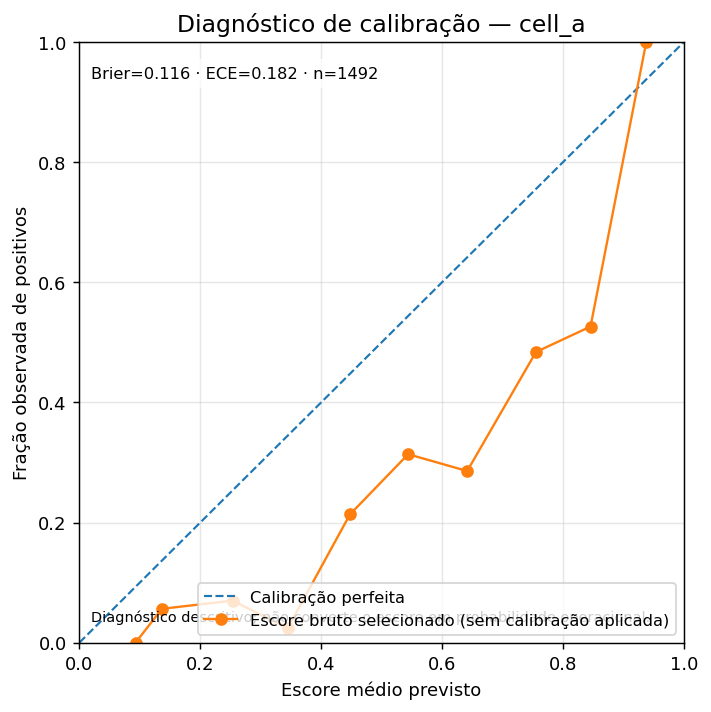

[2026-07-26 01:51:11] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig07_calibration_cell_a.png


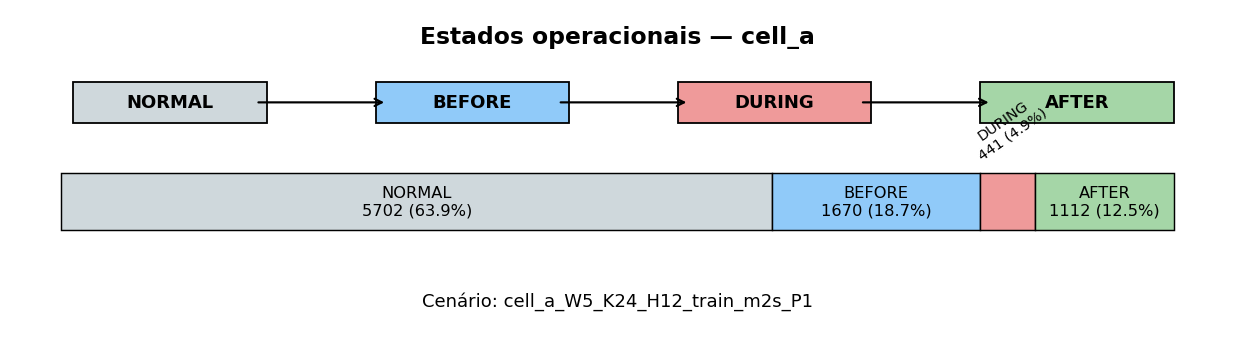

[2026-07-26 01:51:11] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig01_state_diagram_cell_a.png


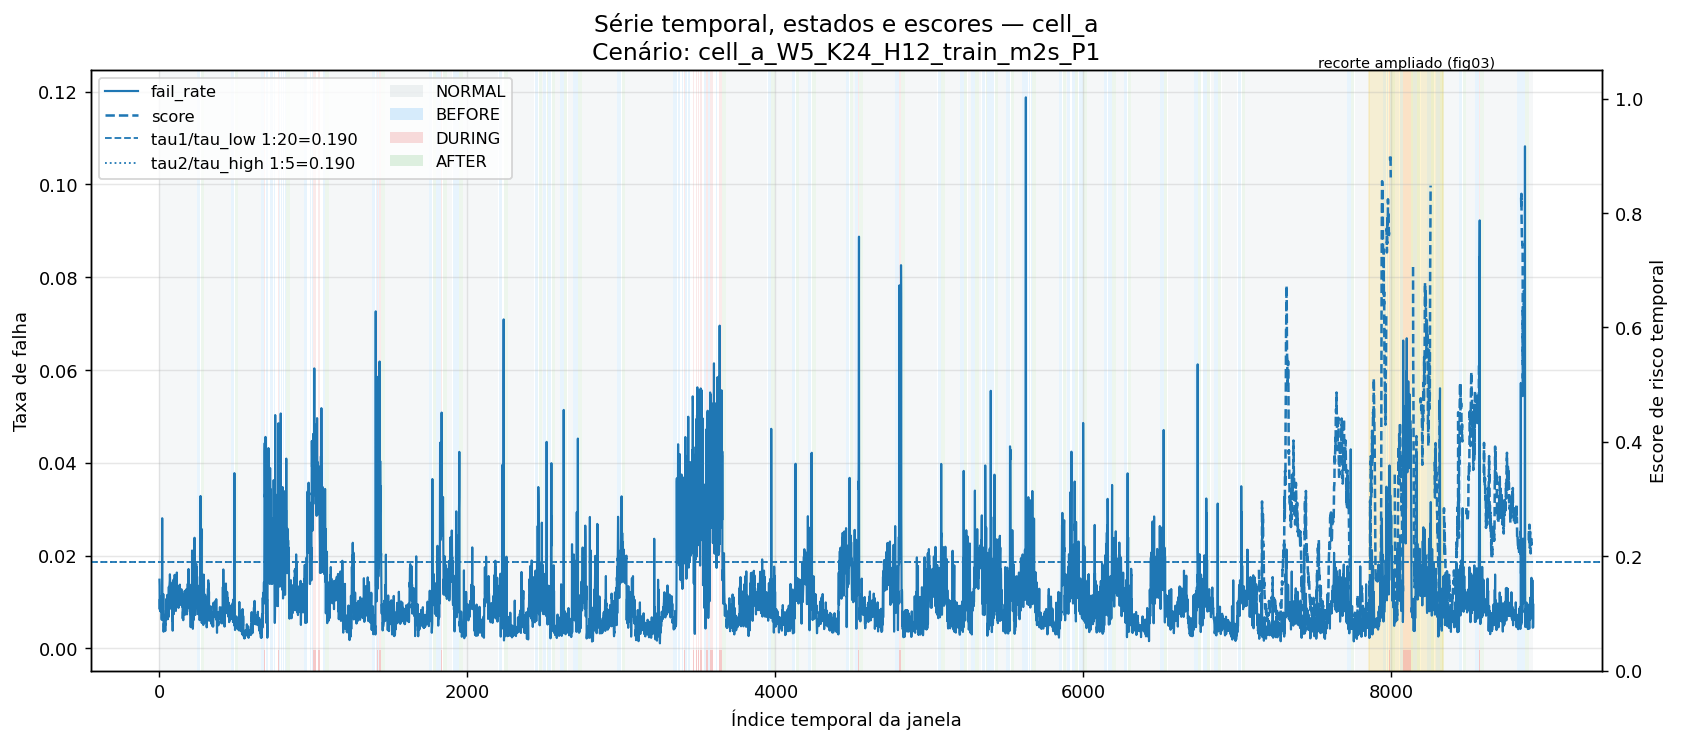

[2026-07-26 01:51:15] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig02_temporal_overview_cell_a.png


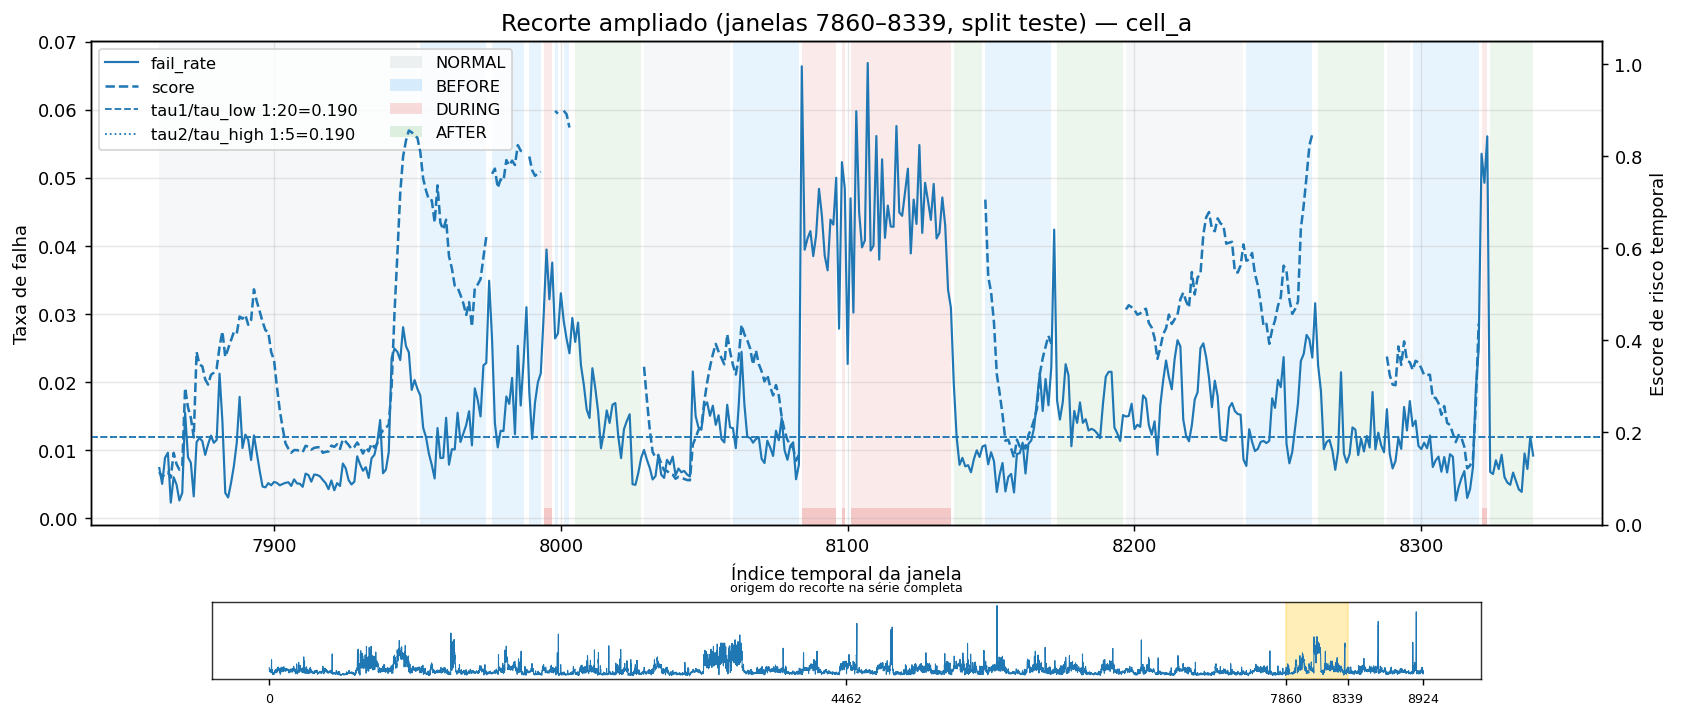

[2026-07-26 01:51:18] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig03_temporal_zoom_cell_a.png


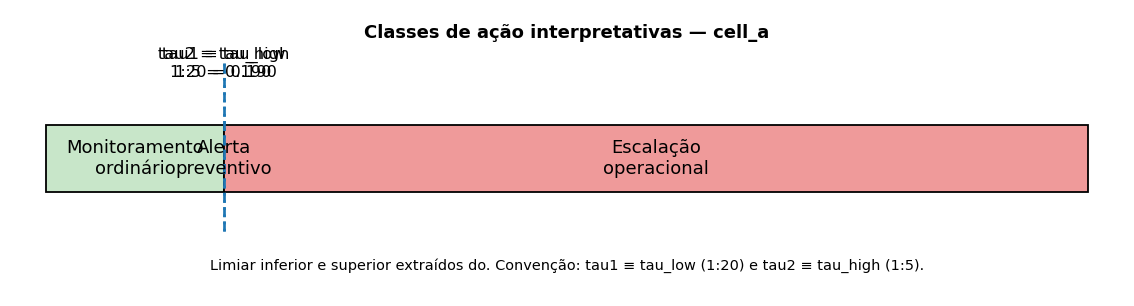

[2026-07-26 01:51:18] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig04_action_classes_cell_a.png


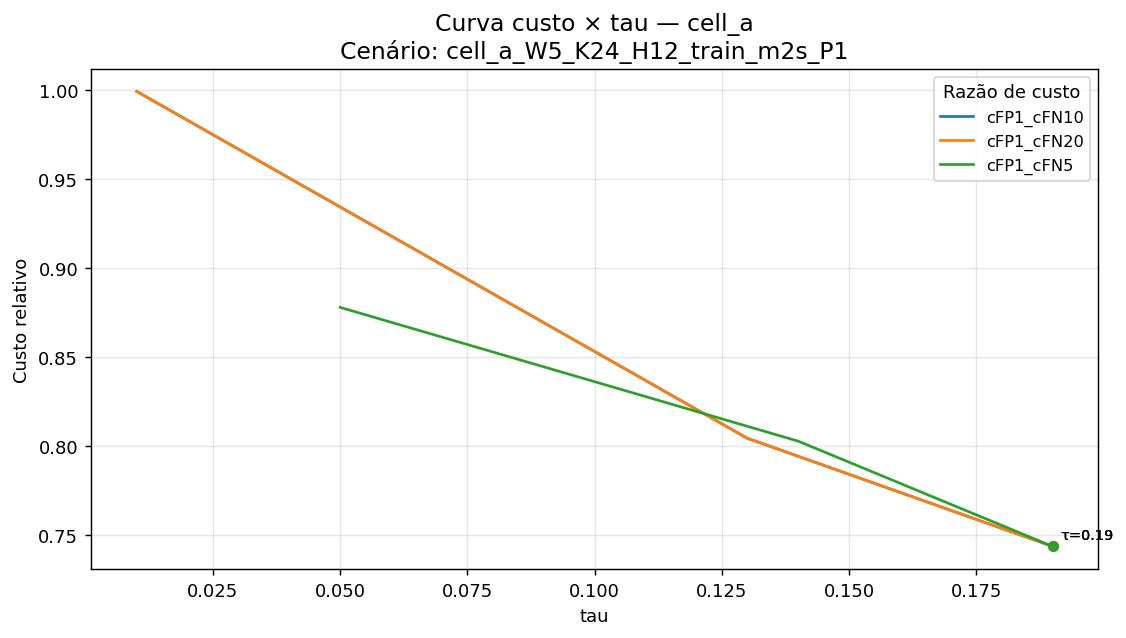

[2026-07-26 01:51:19] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig05_cost_tau_cell_a.png


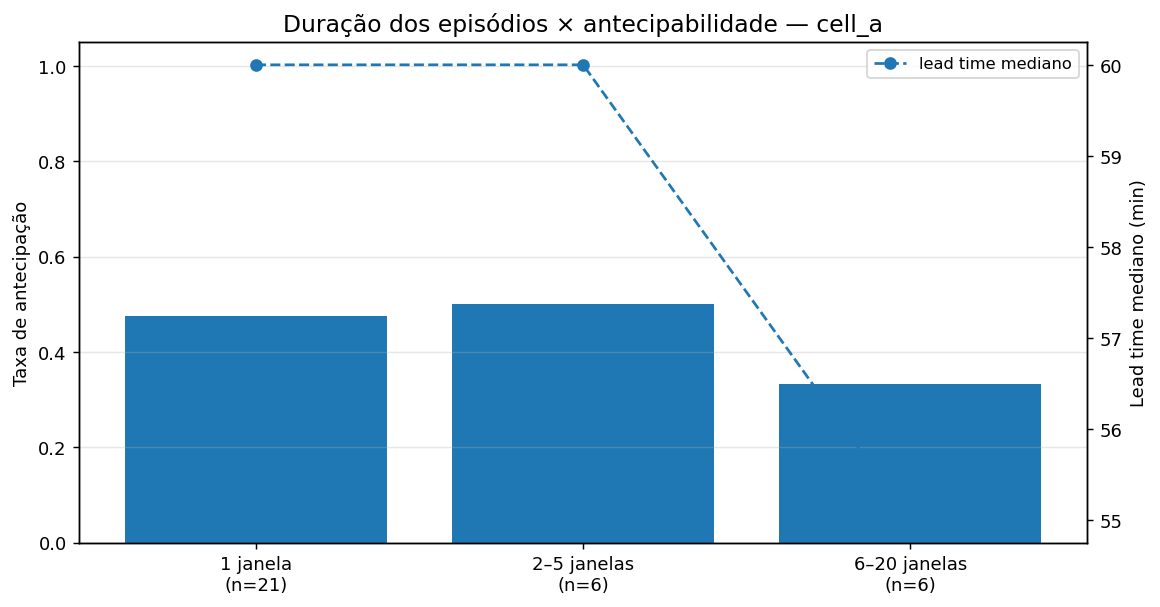

[2026-07-26 01:51:20] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_a/figures/15_FULL_fig06_duration_anticipability_cell_a.png
[2026-07-26 01:51:20] 
--- Processando cell_b ---


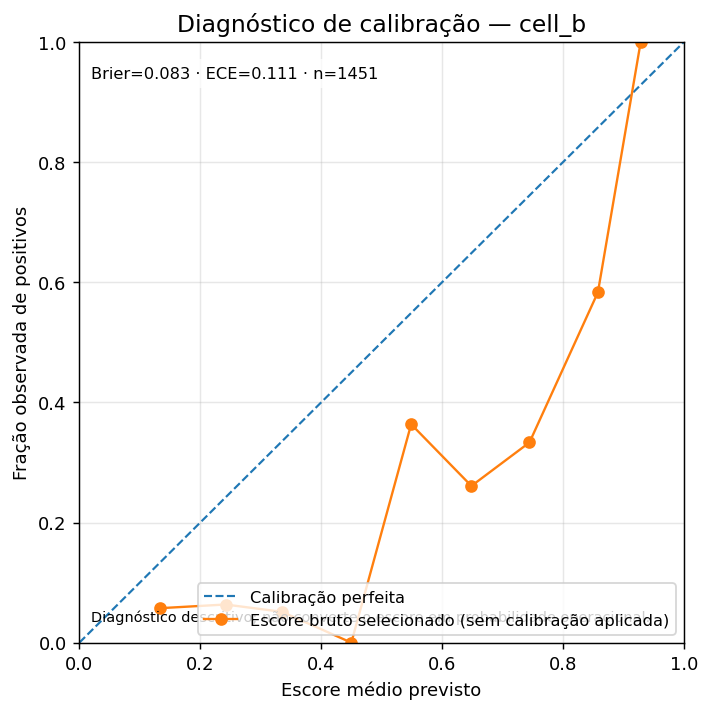

[2026-07-26 01:51:23] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig07_calibration_cell_b.png


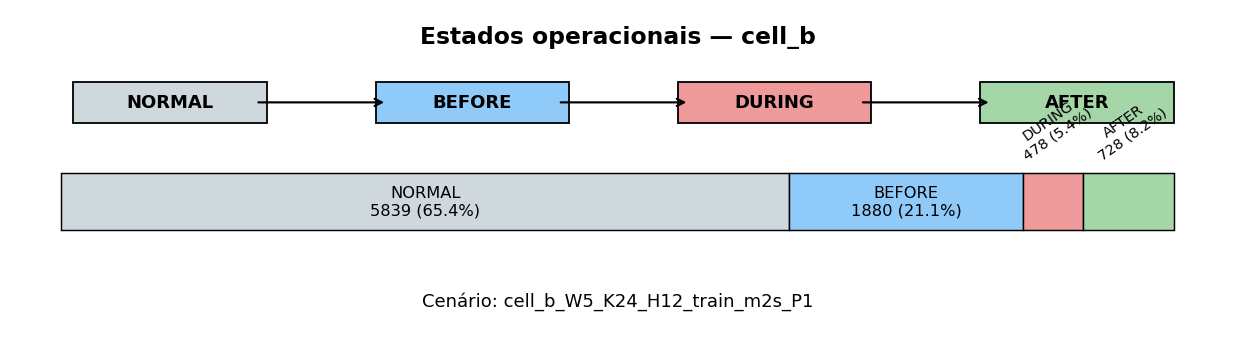

[2026-07-26 01:51:24] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig01_state_diagram_cell_b.png


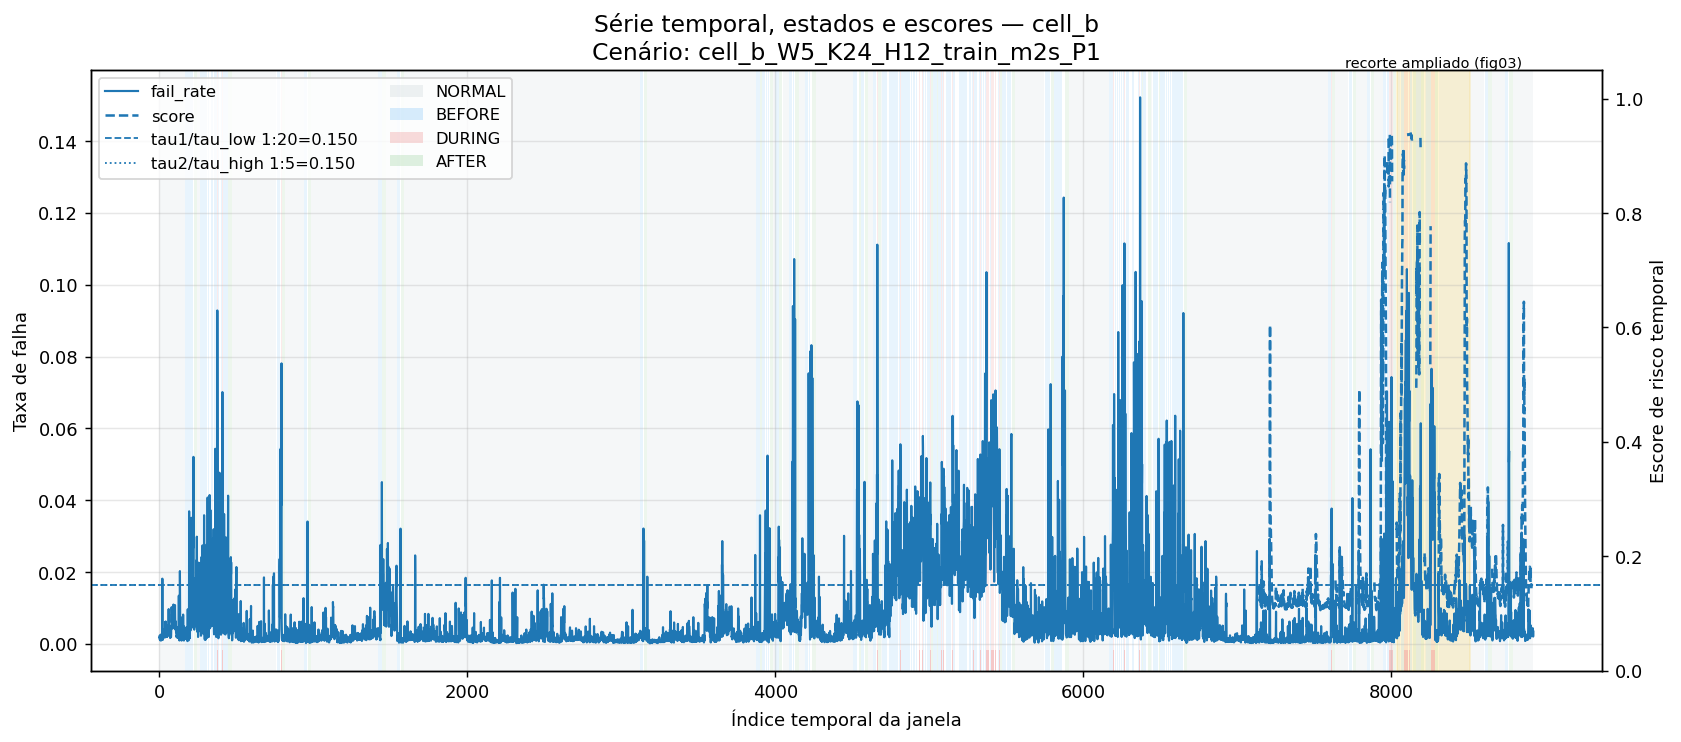

[2026-07-26 01:51:27] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig02_temporal_overview_cell_b.png


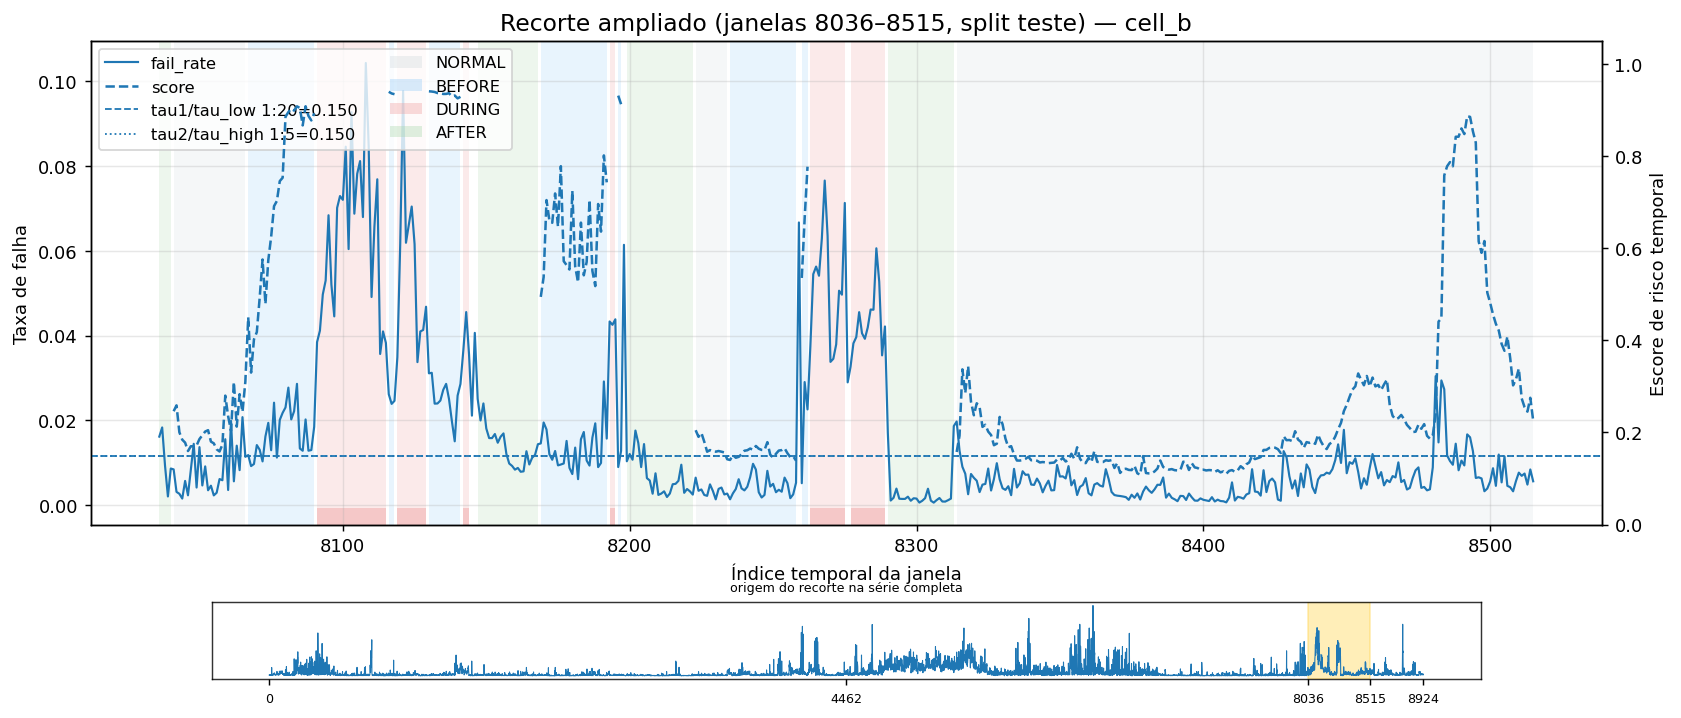

[2026-07-26 01:51:29] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig03_temporal_zoom_cell_b.png


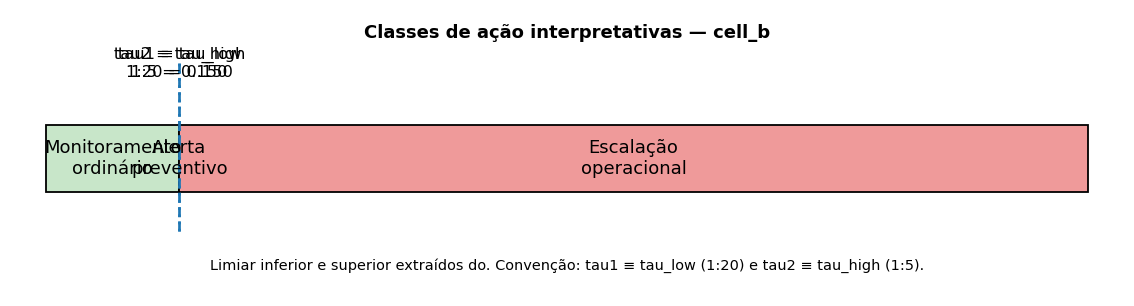

[2026-07-26 01:51:30] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig04_action_classes_cell_b.png


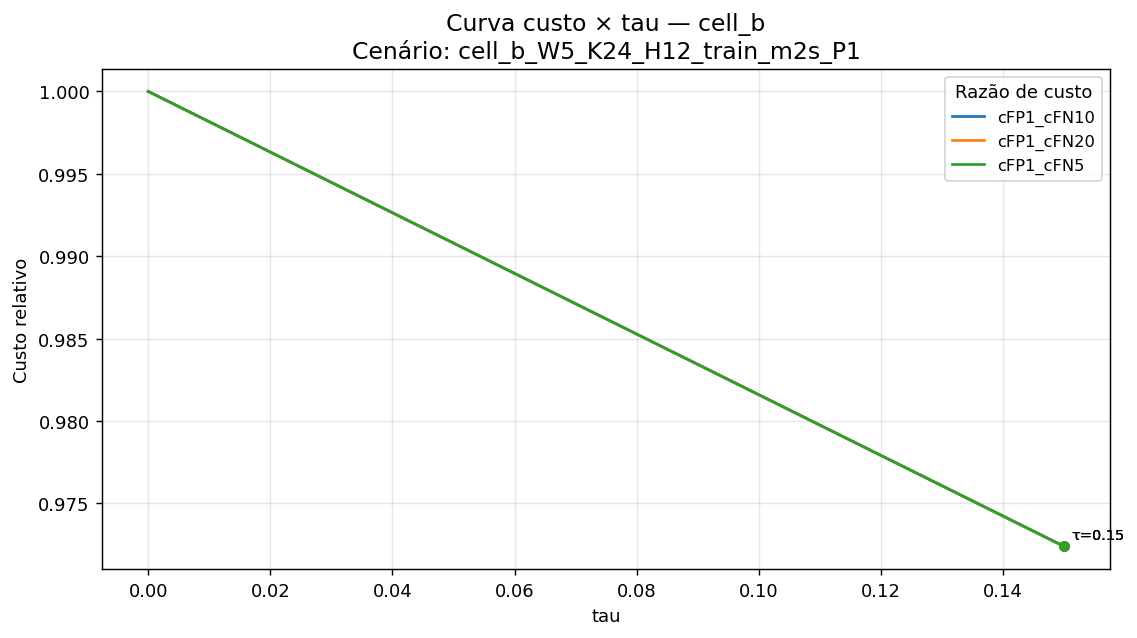

[2026-07-26 01:51:31] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig05_cost_tau_cell_b.png


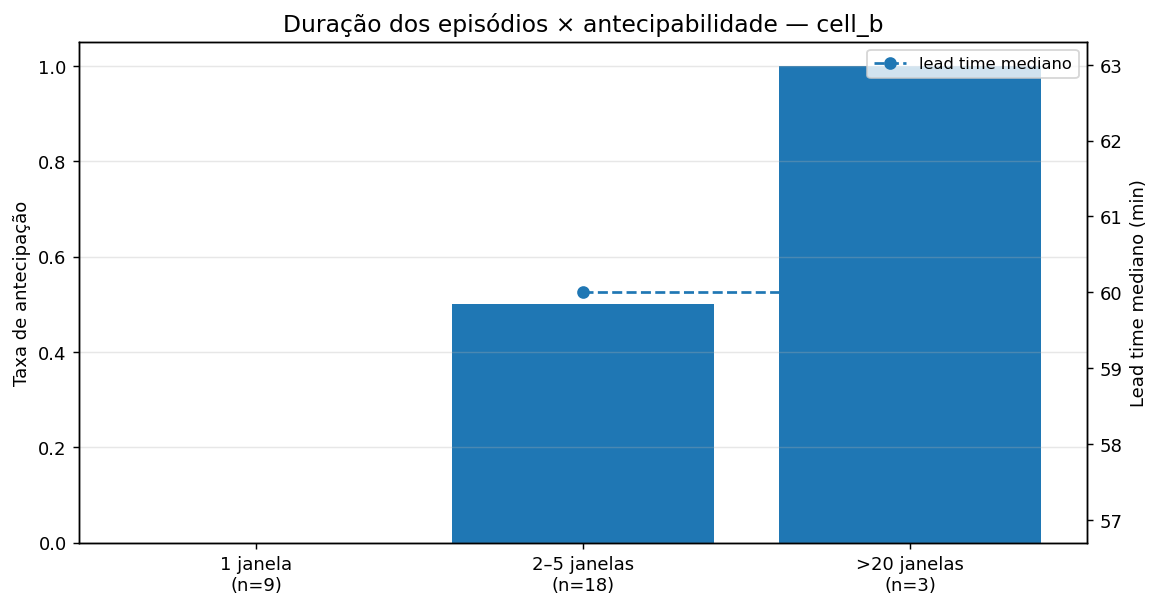

[2026-07-26 01:51:32] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_b/figures/15_FULL_fig06_duration_anticipability_cell_b.png
[2026-07-26 01:51:32] 
--- Processando cell_c ---


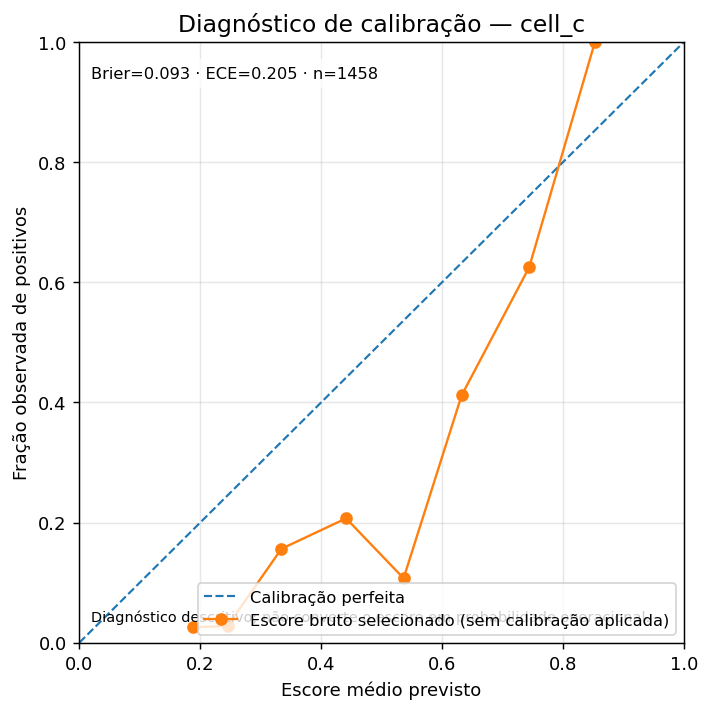

[2026-07-26 01:51:36] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig07_calibration_cell_c.png


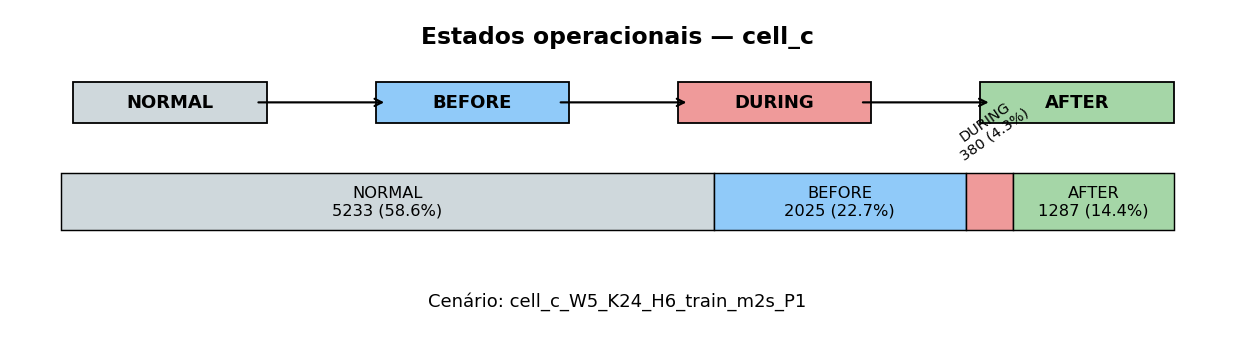

[2026-07-26 01:51:36] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig01_state_diagram_cell_c.png


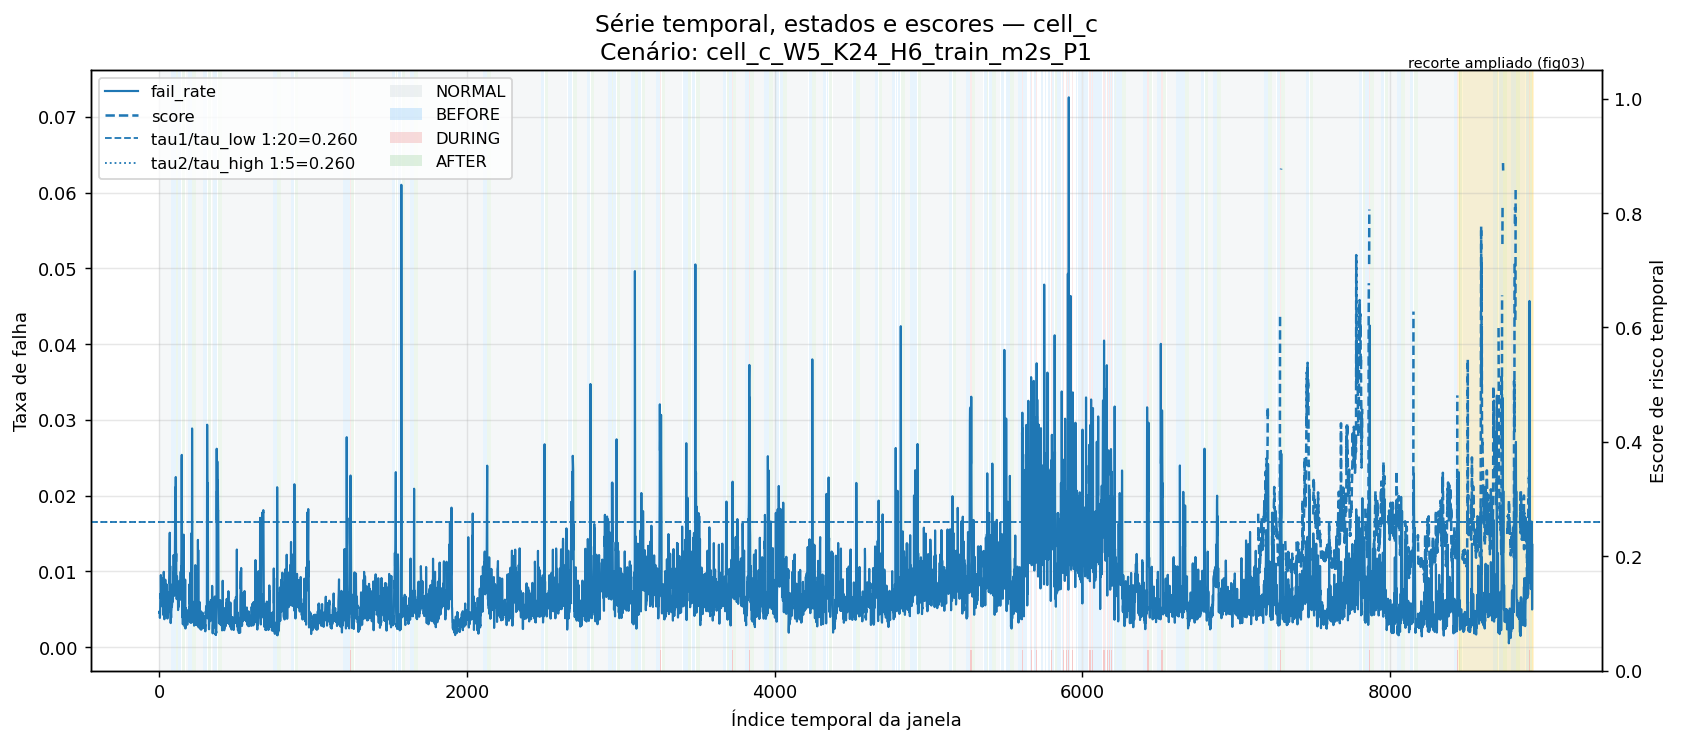

[2026-07-26 01:51:39] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig02_temporal_overview_cell_c.png


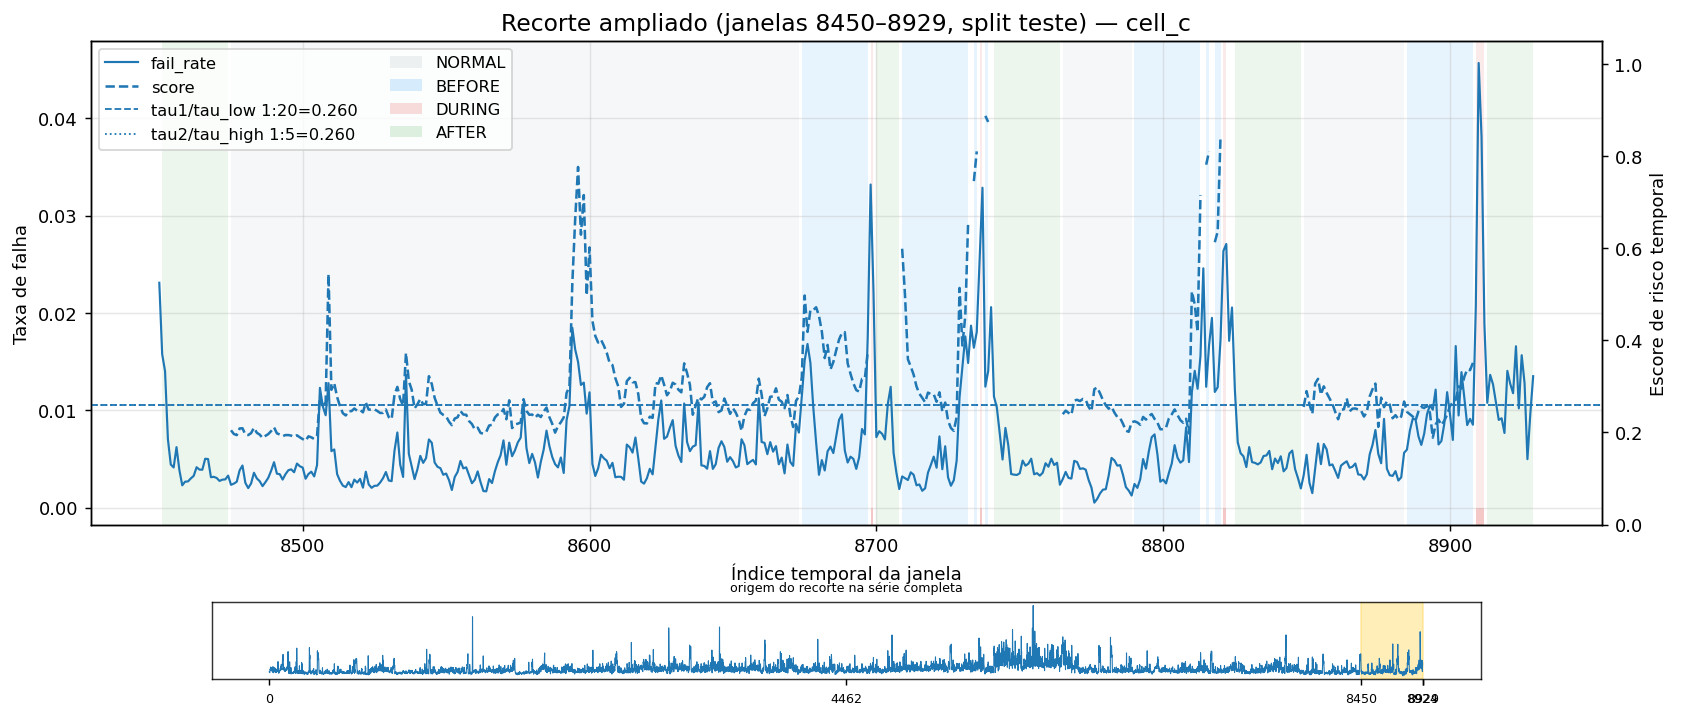

[2026-07-26 01:51:41] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig03_temporal_zoom_cell_c.png


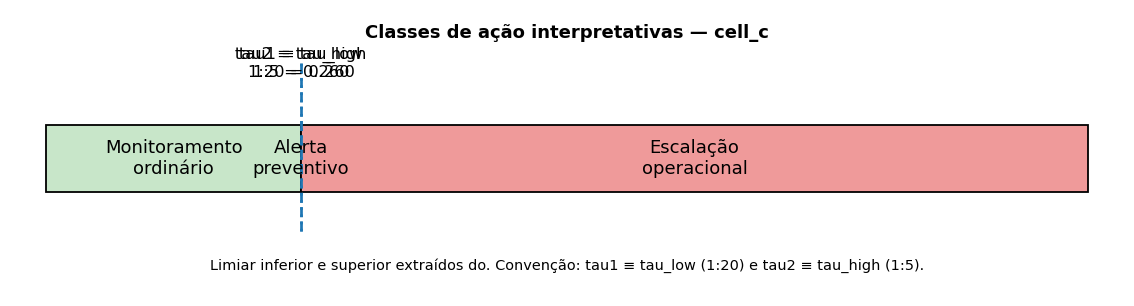

[2026-07-26 01:51:41] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig04_action_classes_cell_c.png


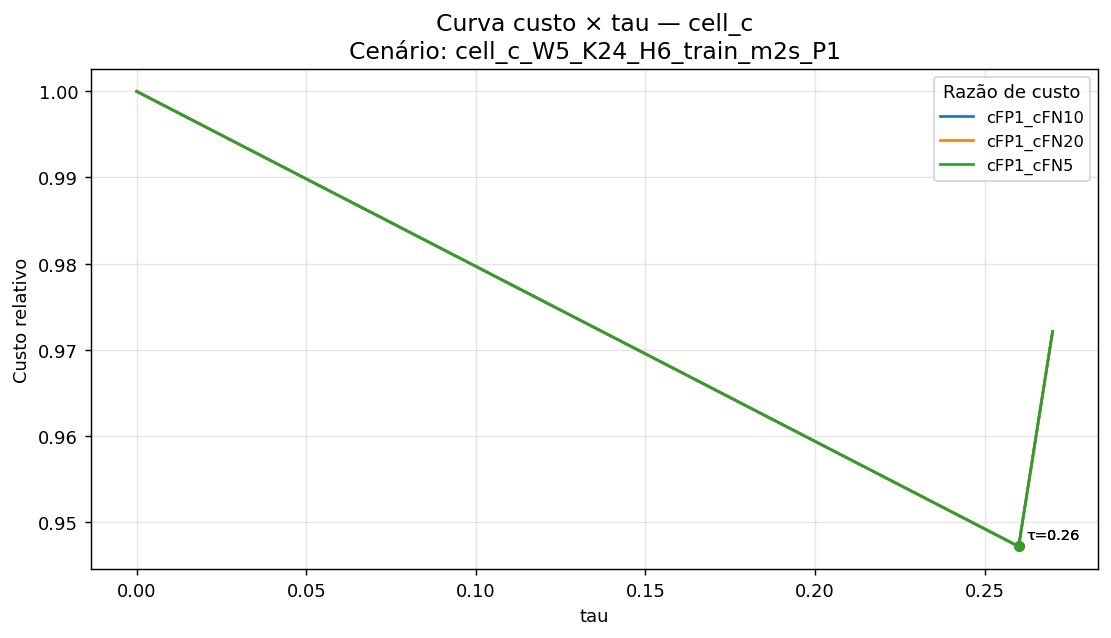

[2026-07-26 01:51:43] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig05_cost_tau_cell_c.png


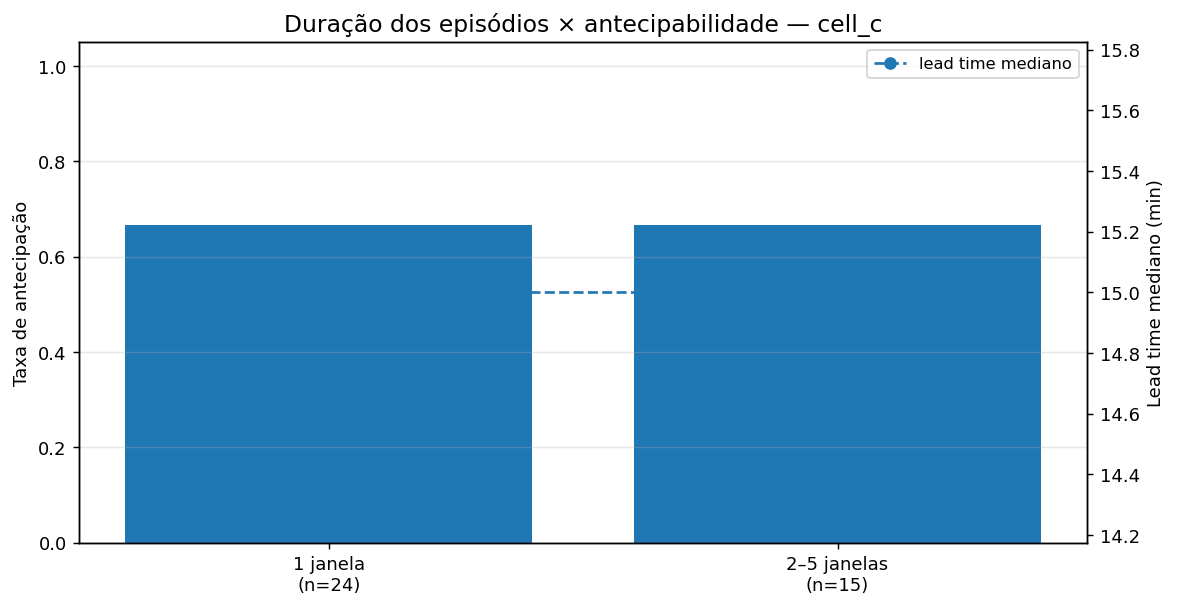

[2026-07-26 01:51:44] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_c/figures/15_FULL_fig06_duration_anticipability_cell_c.png
[2026-07-26 01:51:44] 
--- Processando cell_d ---


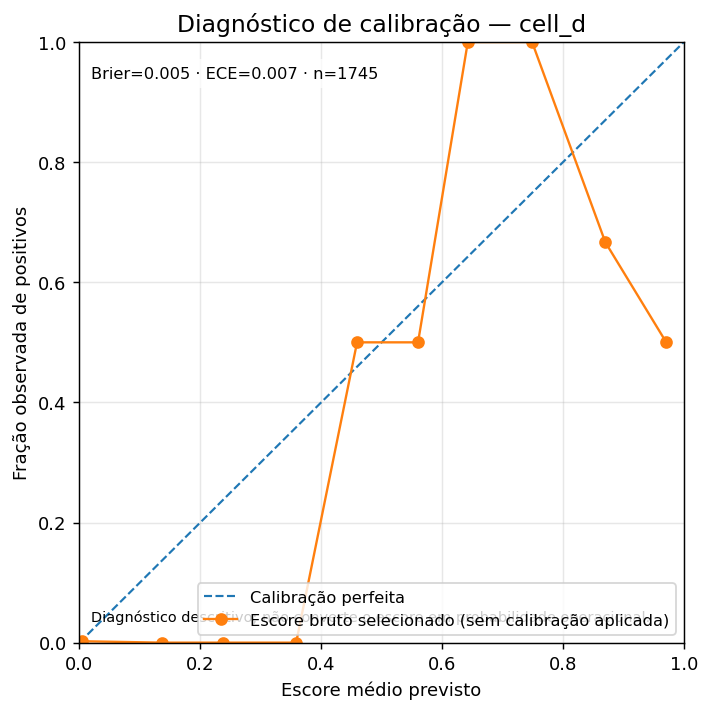

[2026-07-26 01:51:48] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig07_calibration_cell_d.png


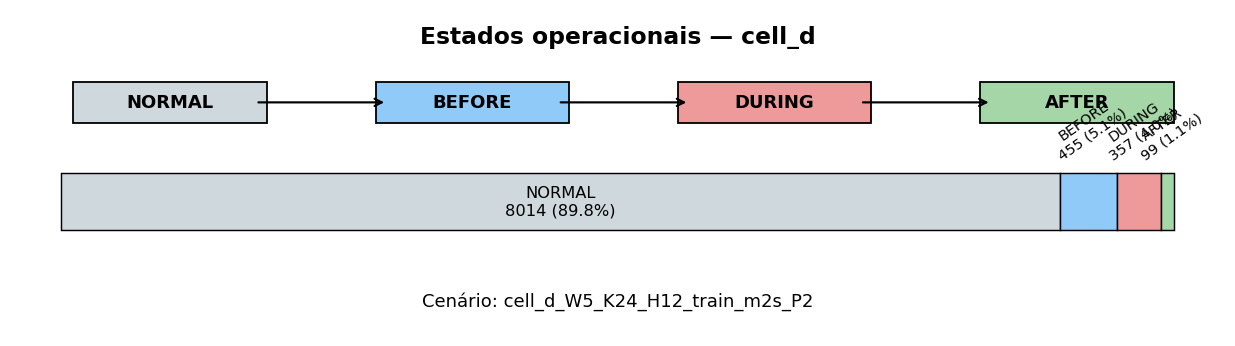

[2026-07-26 01:51:48] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig01_state_diagram_cell_d.png


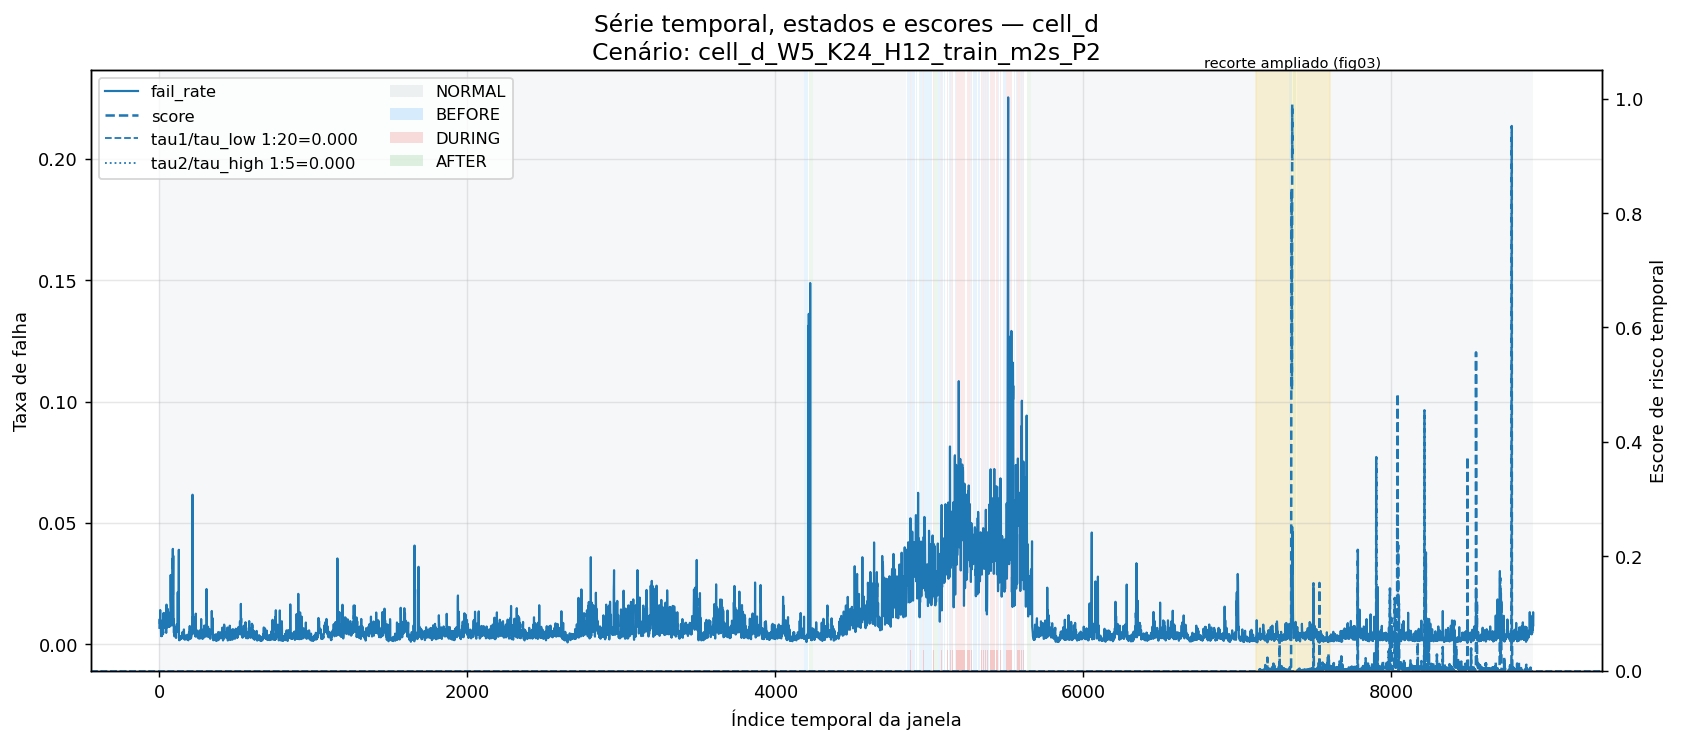

[2026-07-26 01:51:50] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig02_temporal_overview_cell_d.png


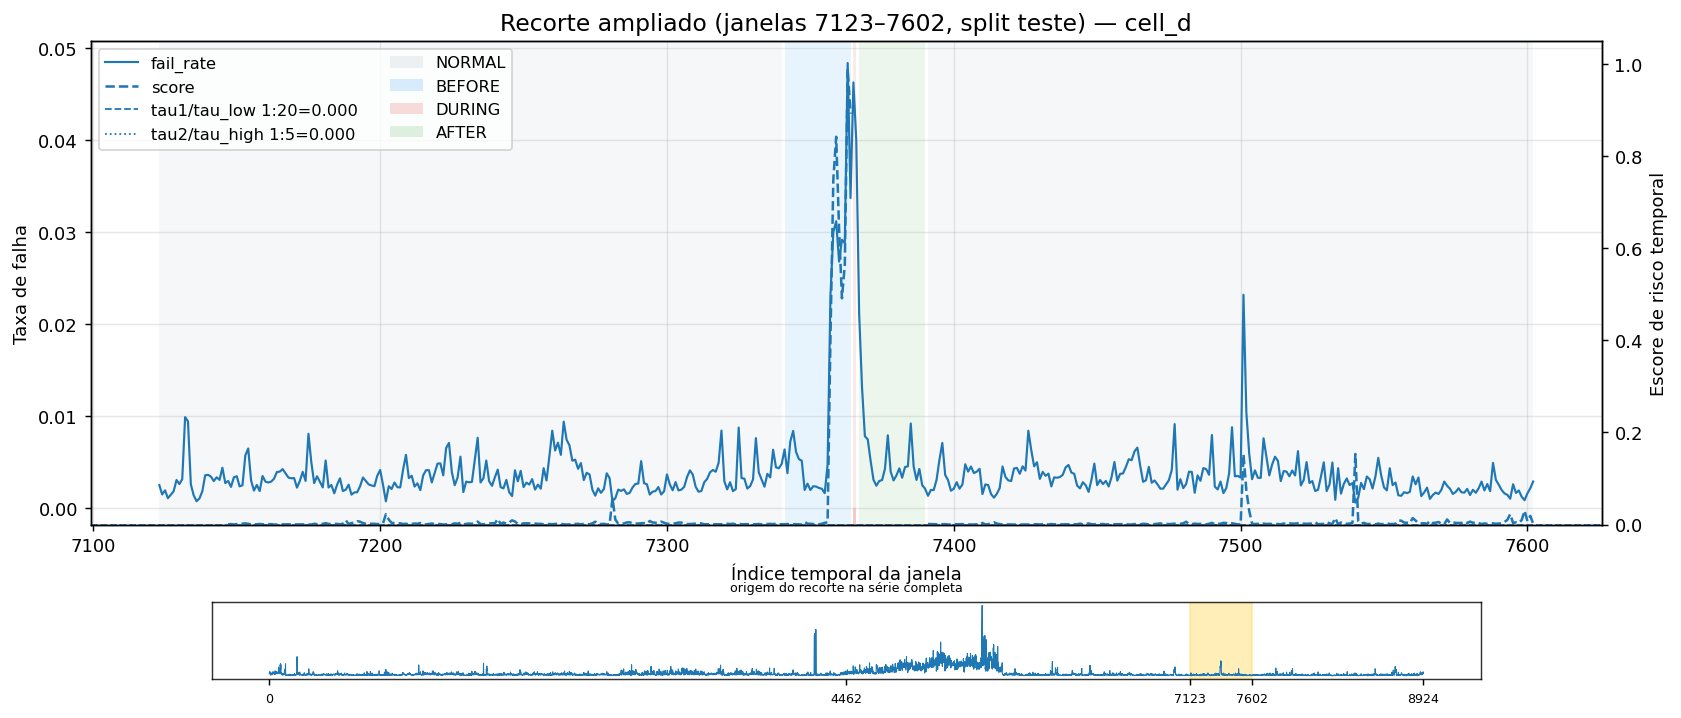

[2026-07-26 01:51:52] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig03_temporal_zoom_cell_d.png


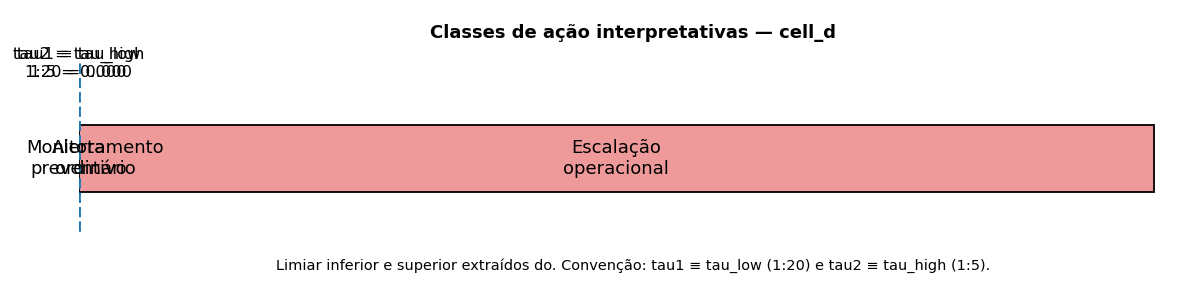

[2026-07-26 01:51:52] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig04_action_classes_cell_d.png


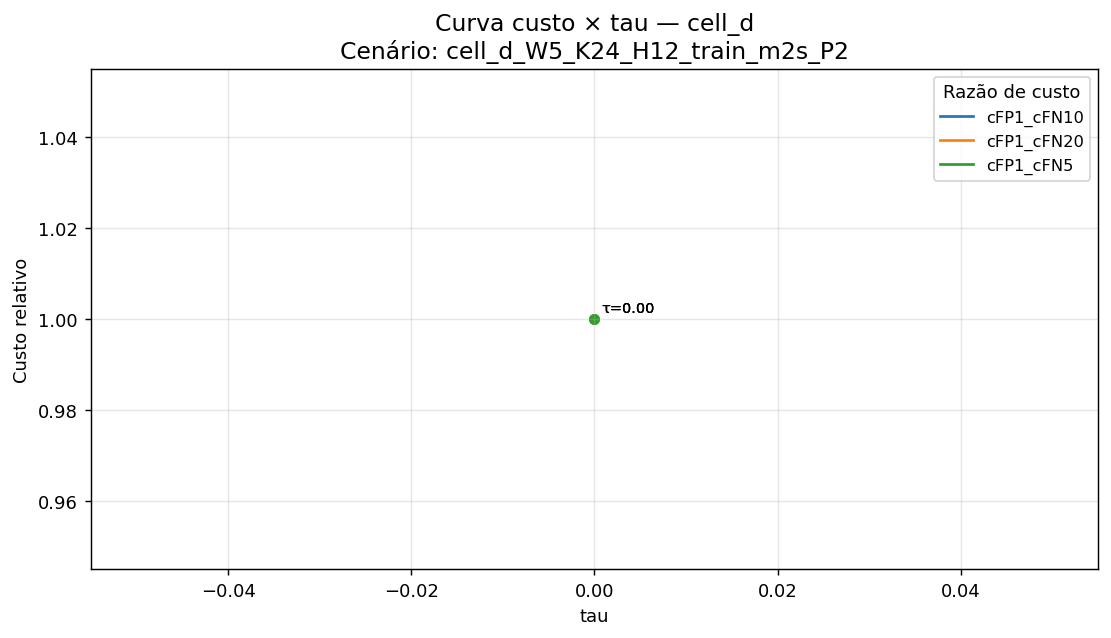

[2026-07-26 01:51:53] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig05_cost_tau_cell_d.png


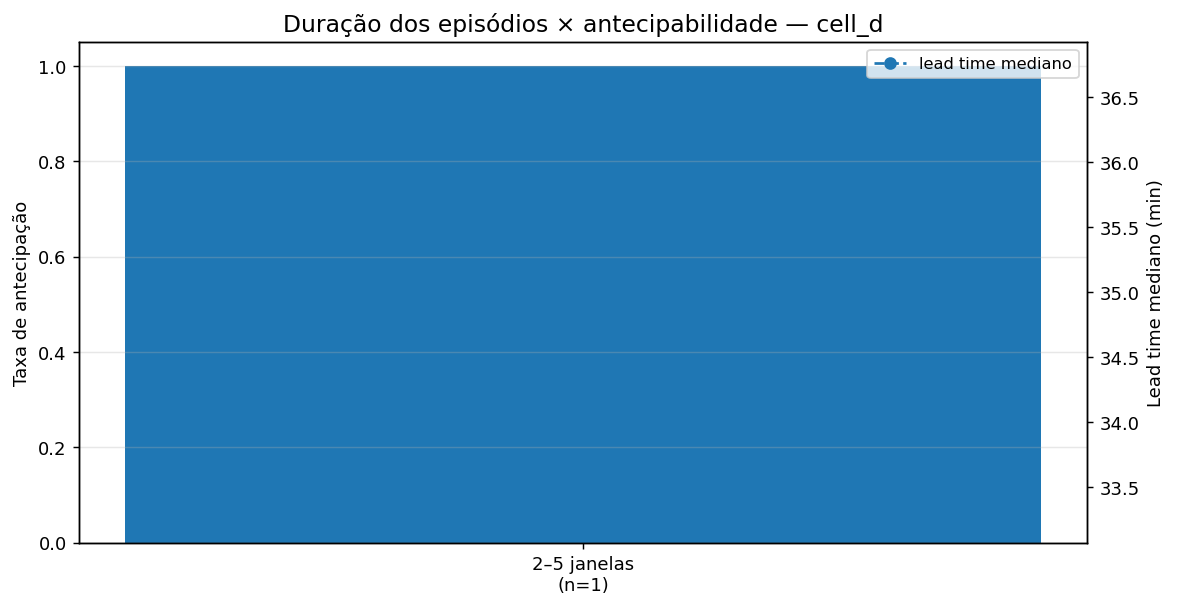

[2026-07-26 01:51:54] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_d/figures/15_FULL_fig06_duration_anticipability_cell_d.png
[2026-07-26 01:51:54] 
--- Processando cell_e ---


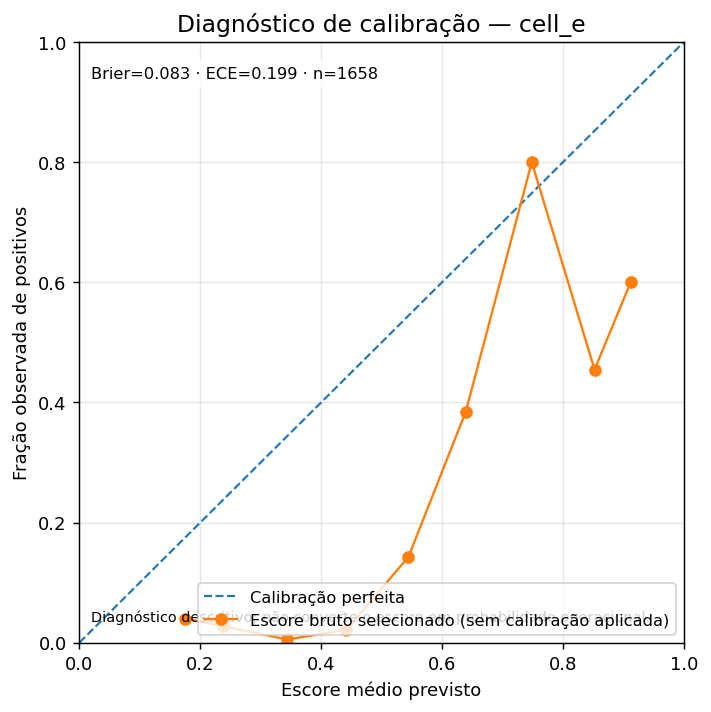

[2026-07-26 01:51:57] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig07_calibration_cell_e.png


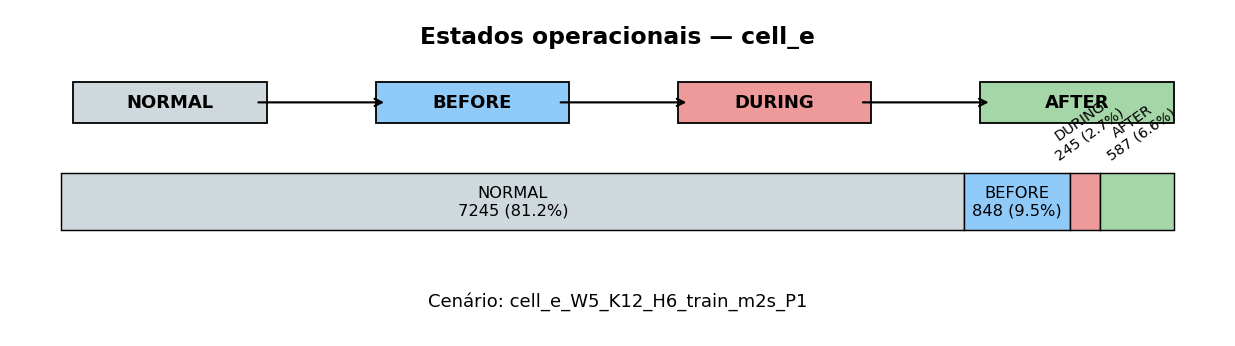

[2026-07-26 01:51:58] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig01_state_diagram_cell_e.png


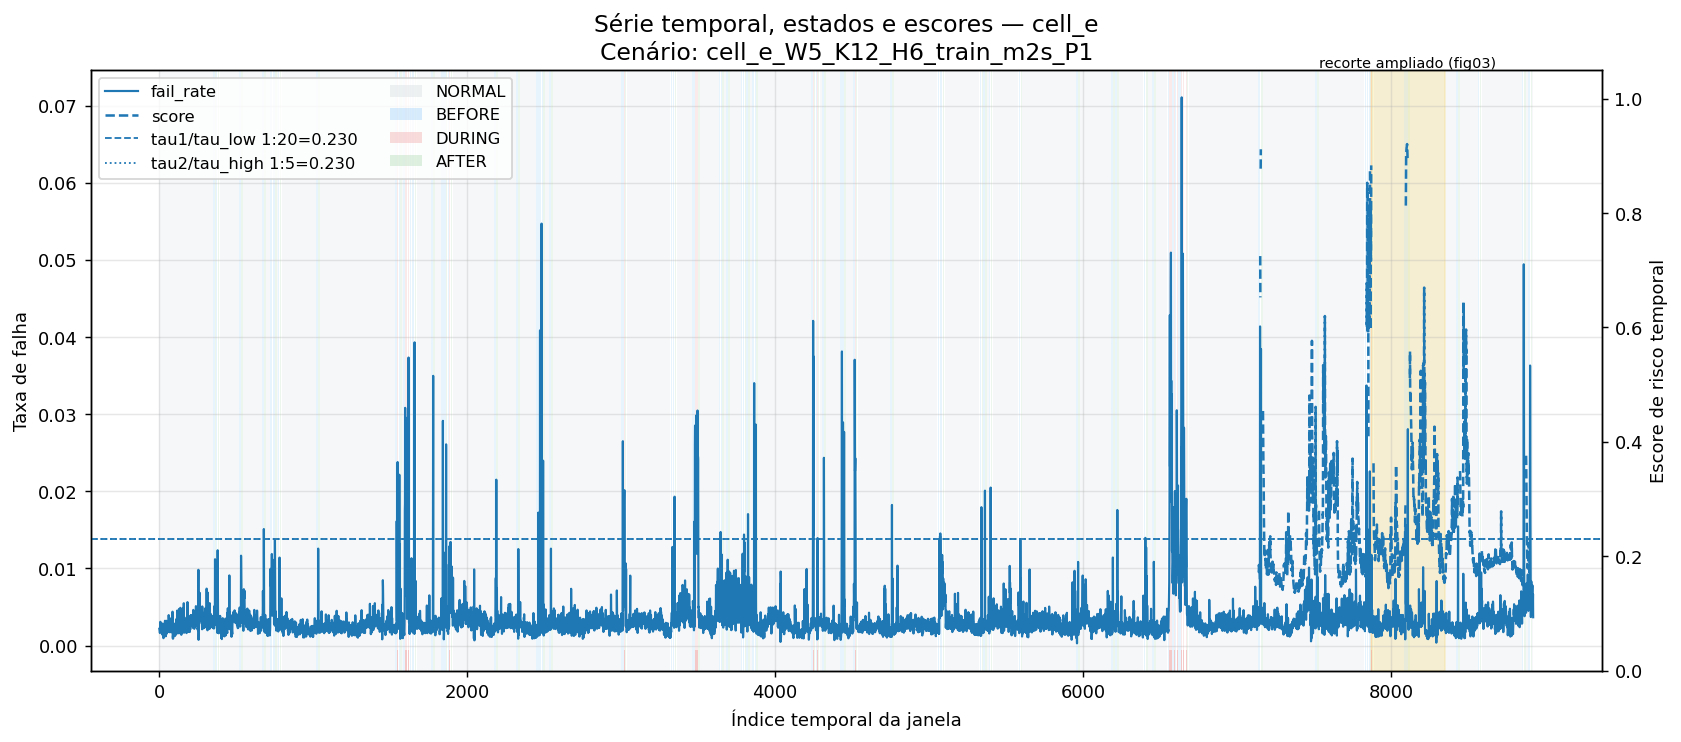

[2026-07-26 01:52:02] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig02_temporal_overview_cell_e.png


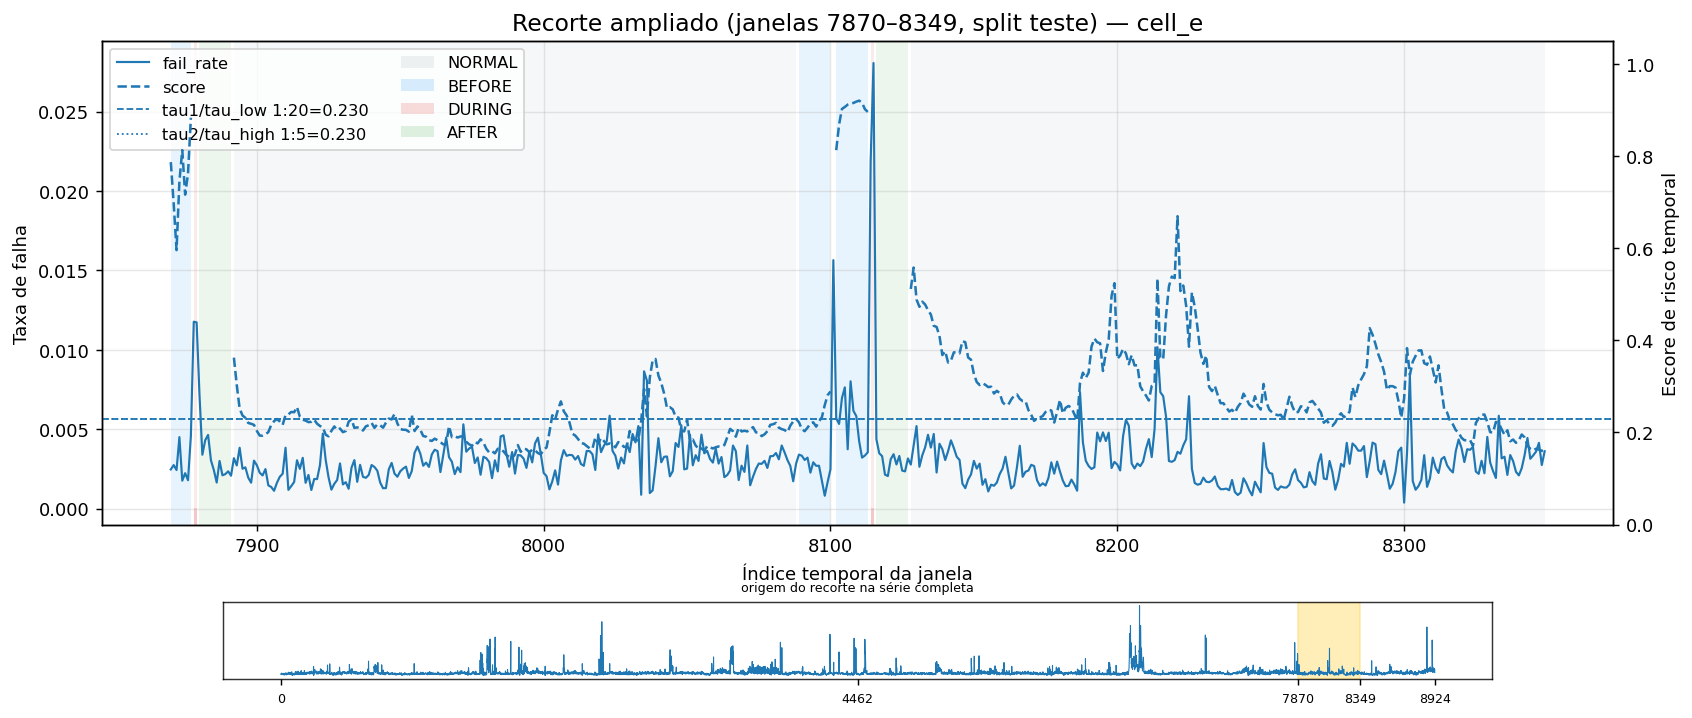

[2026-07-26 01:52:04] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig03_temporal_zoom_cell_e.png


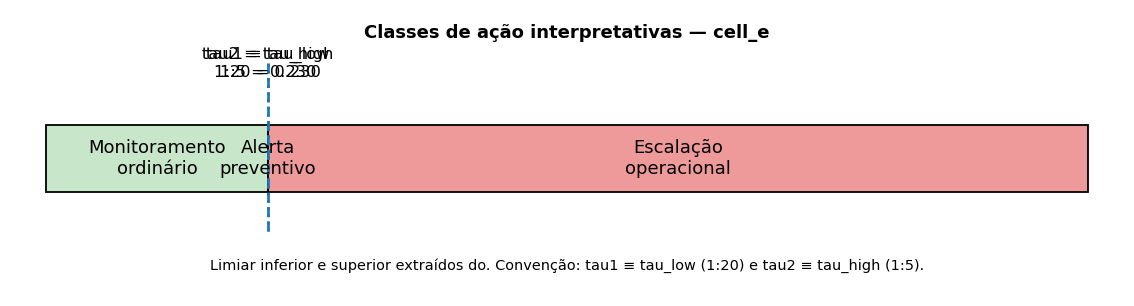

[2026-07-26 01:52:04] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig04_action_classes_cell_e.png


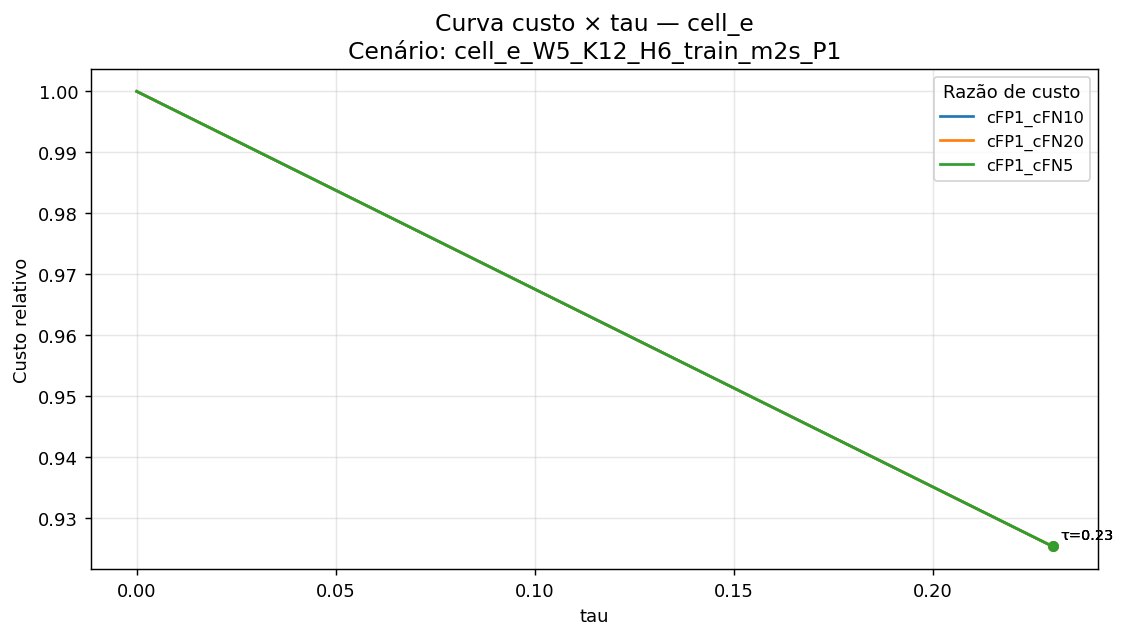

[2026-07-26 01:52:06] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig05_cost_tau_cell_e.png


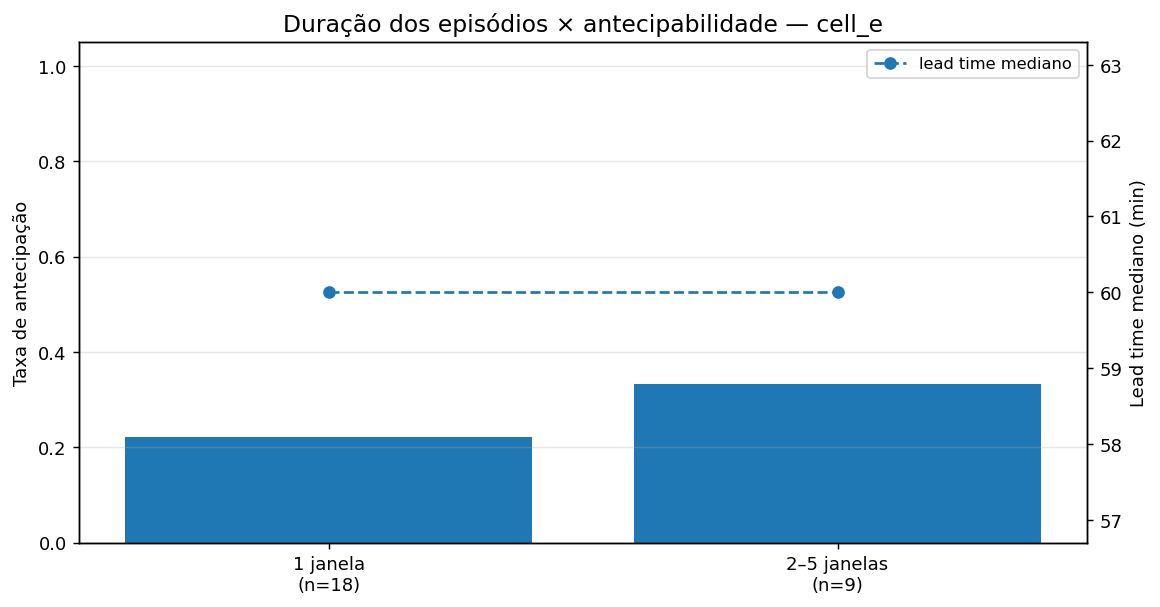

[2026-07-26 01:52:06] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_e/figures/15_FULL_fig06_duration_anticipability_cell_e.png
[2026-07-26 01:52:07] 
--- Processando cell_f ---


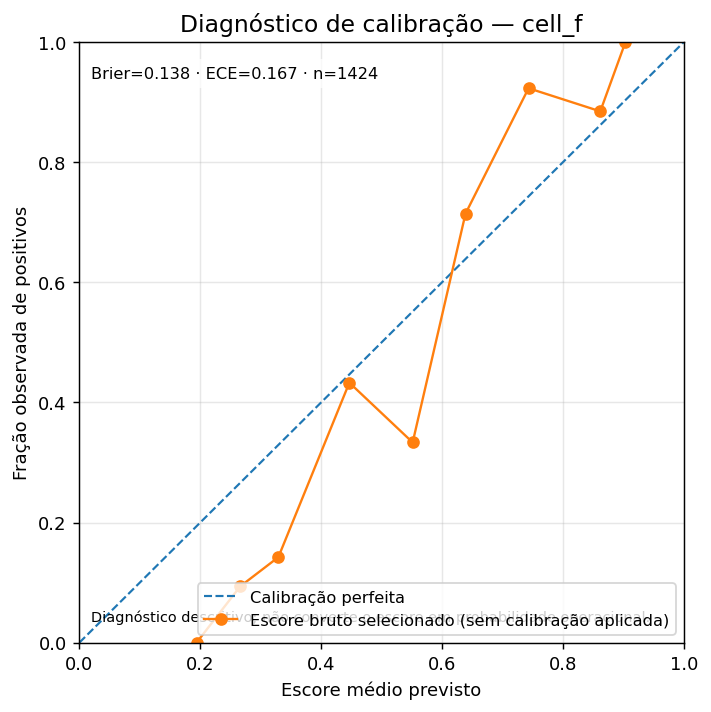

[2026-07-26 01:52:10] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig07_calibration_cell_f.png


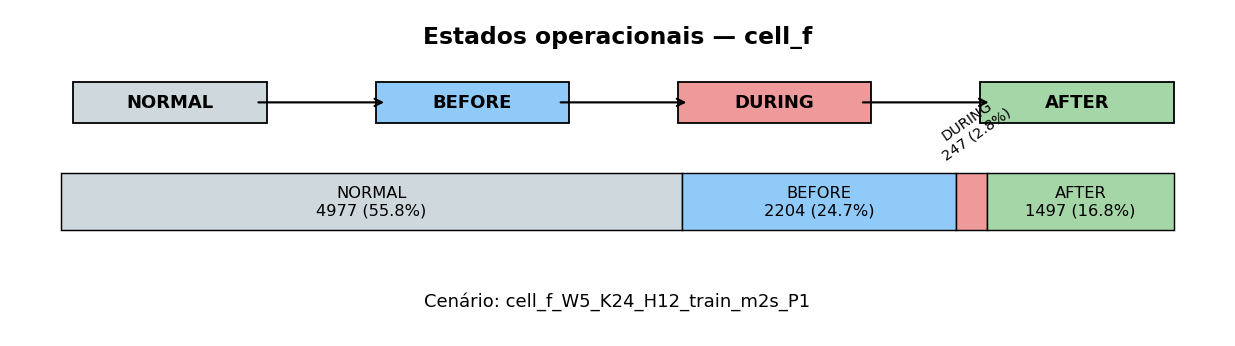

[2026-07-26 01:52:10] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig01_state_diagram_cell_f.png


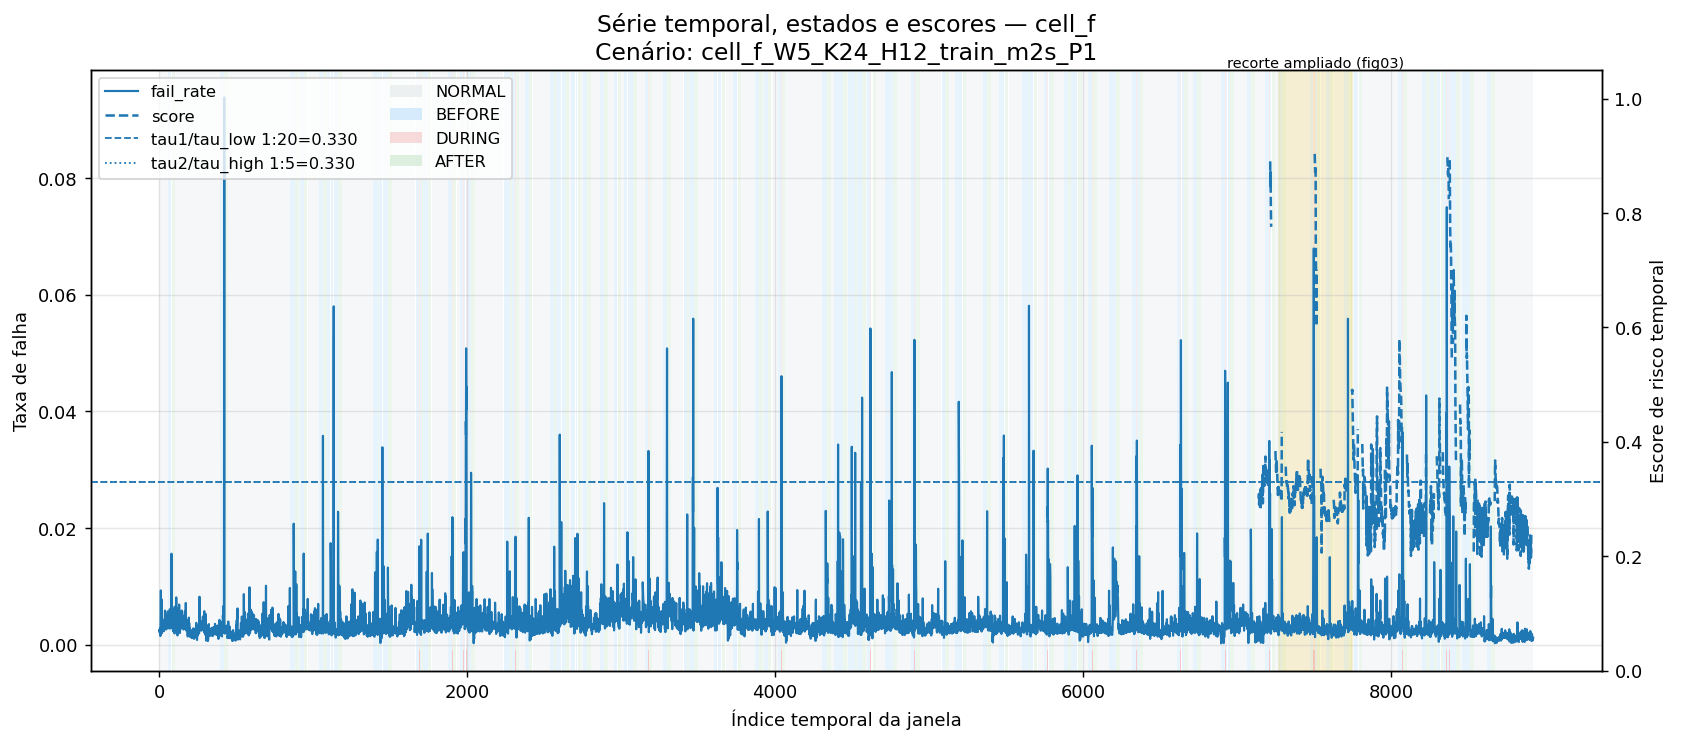

[2026-07-26 01:52:13] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig02_temporal_overview_cell_f.png


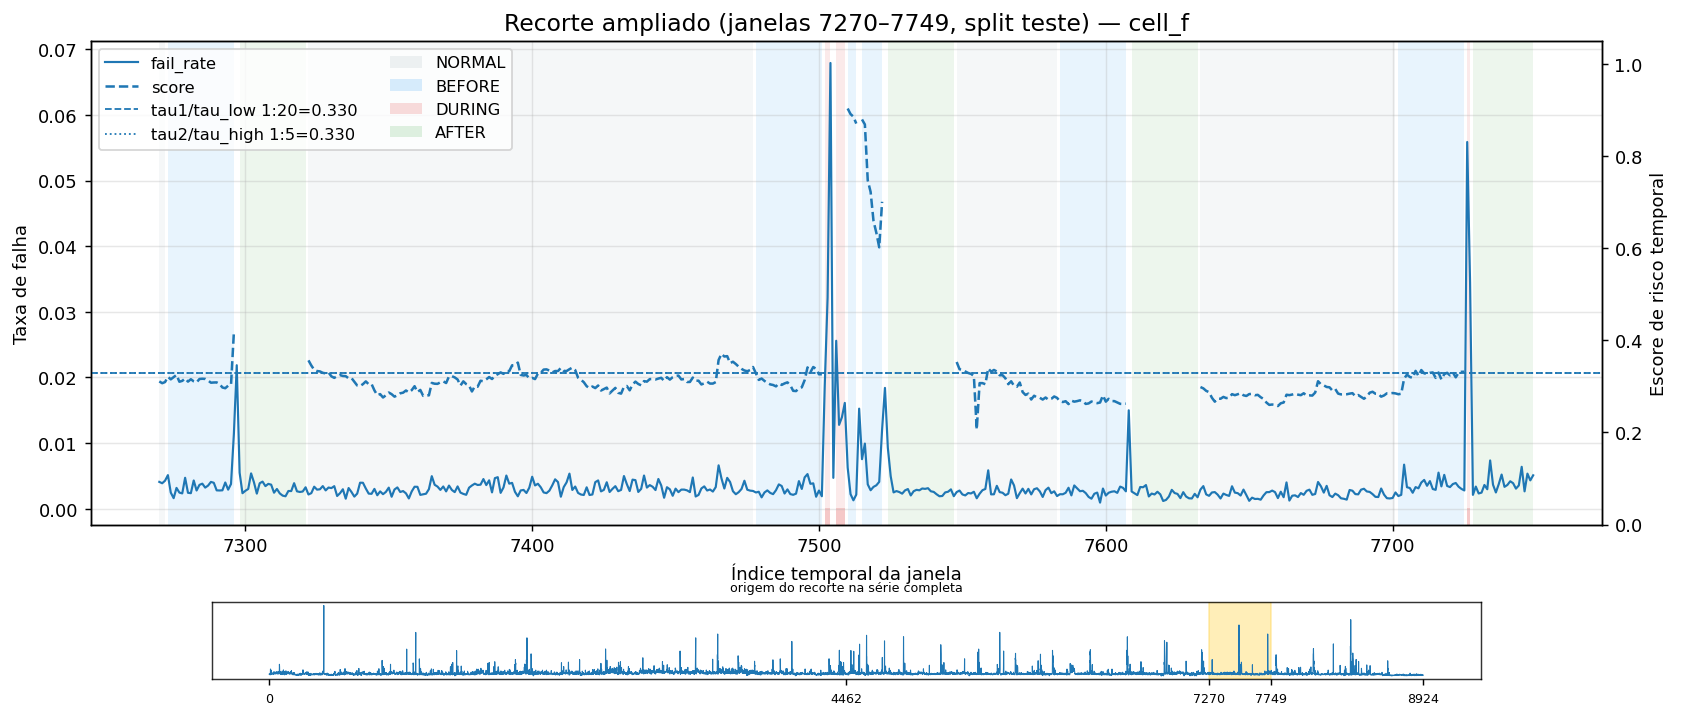

[2026-07-26 01:52:16] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig03_temporal_zoom_cell_f.png


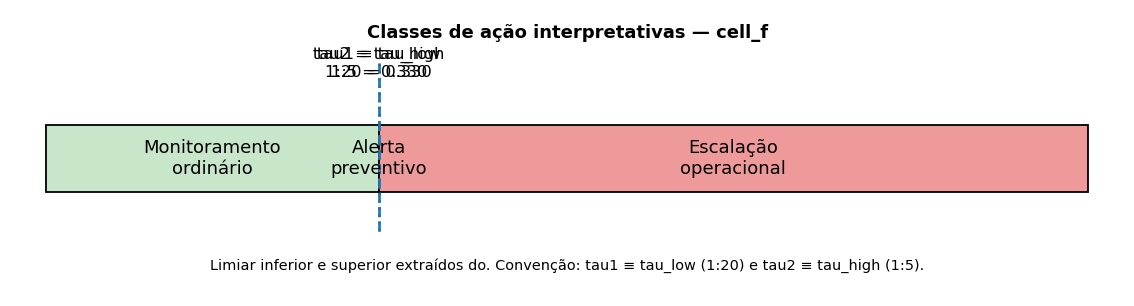

[2026-07-26 01:52:16] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig04_action_classes_cell_f.png


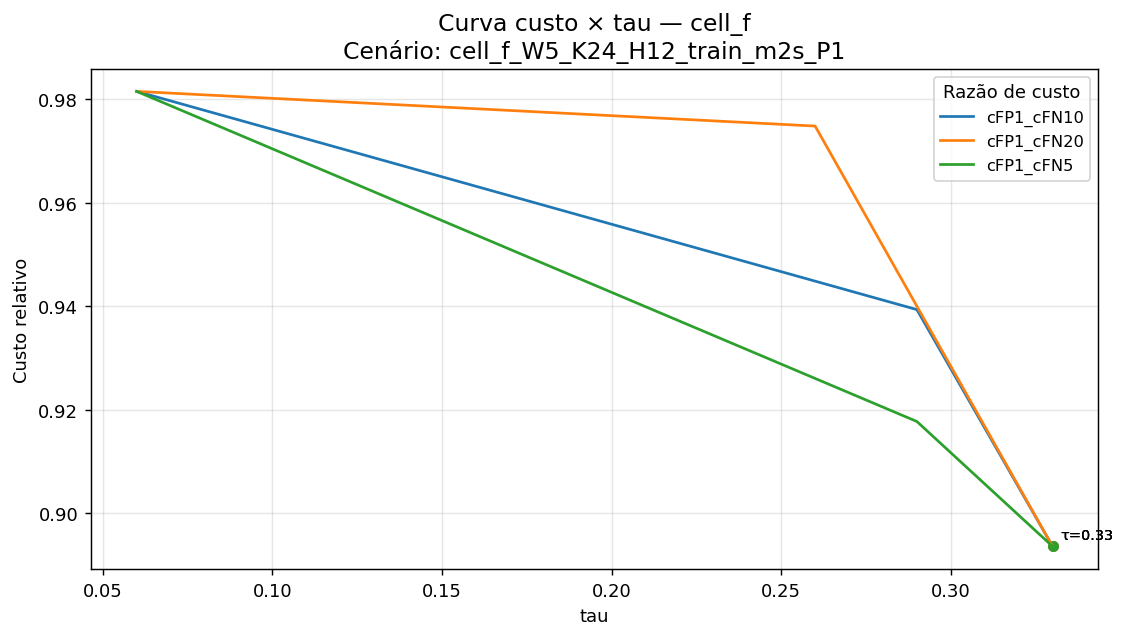

[2026-07-26 01:52:18] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig05_cost_tau_cell_f.png


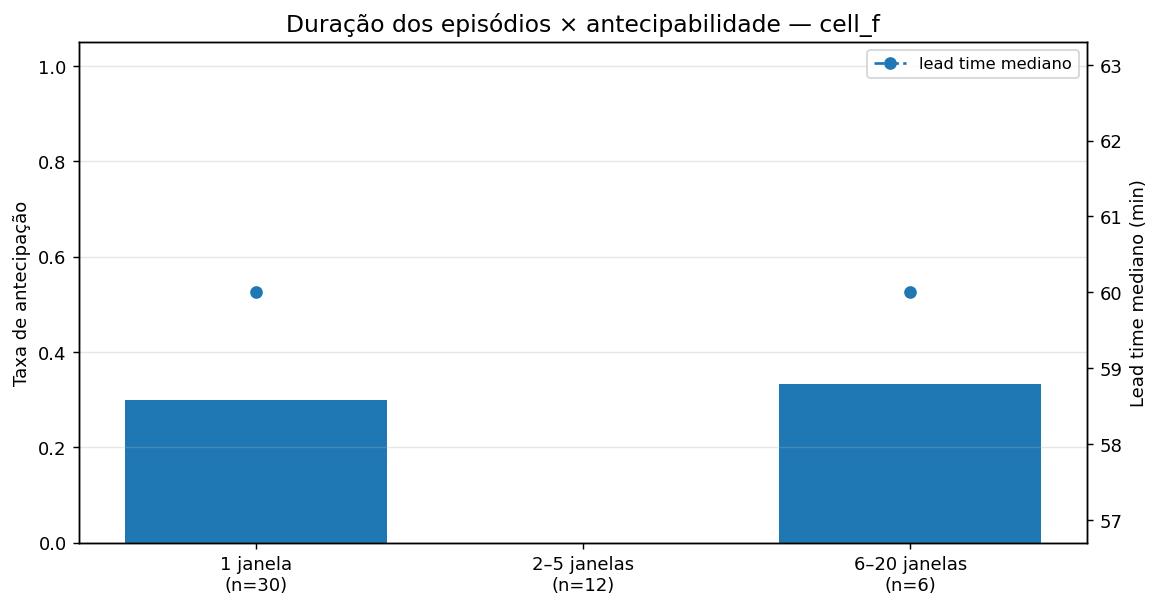

[2026-07-26 01:52:19] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_f/figures/15_FULL_fig06_duration_anticipability_cell_f.png
[2026-07-26 01:52:19] 
--- Processando cell_g ---


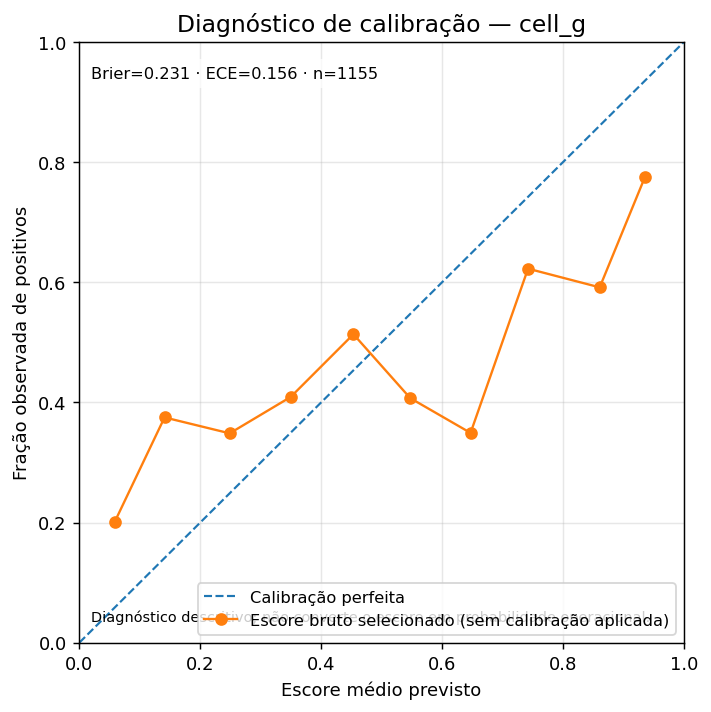

[2026-07-26 01:52:22] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig07_calibration_cell_g.png


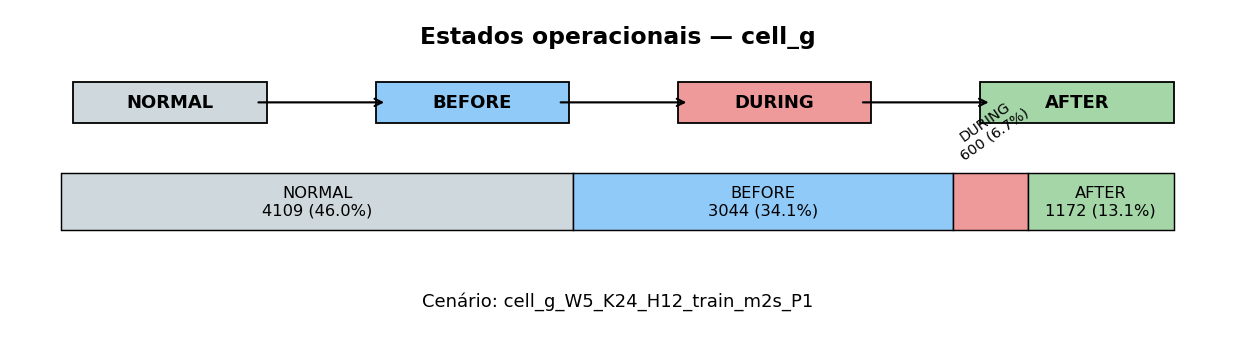

[2026-07-26 01:52:22] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig01_state_diagram_cell_g.png


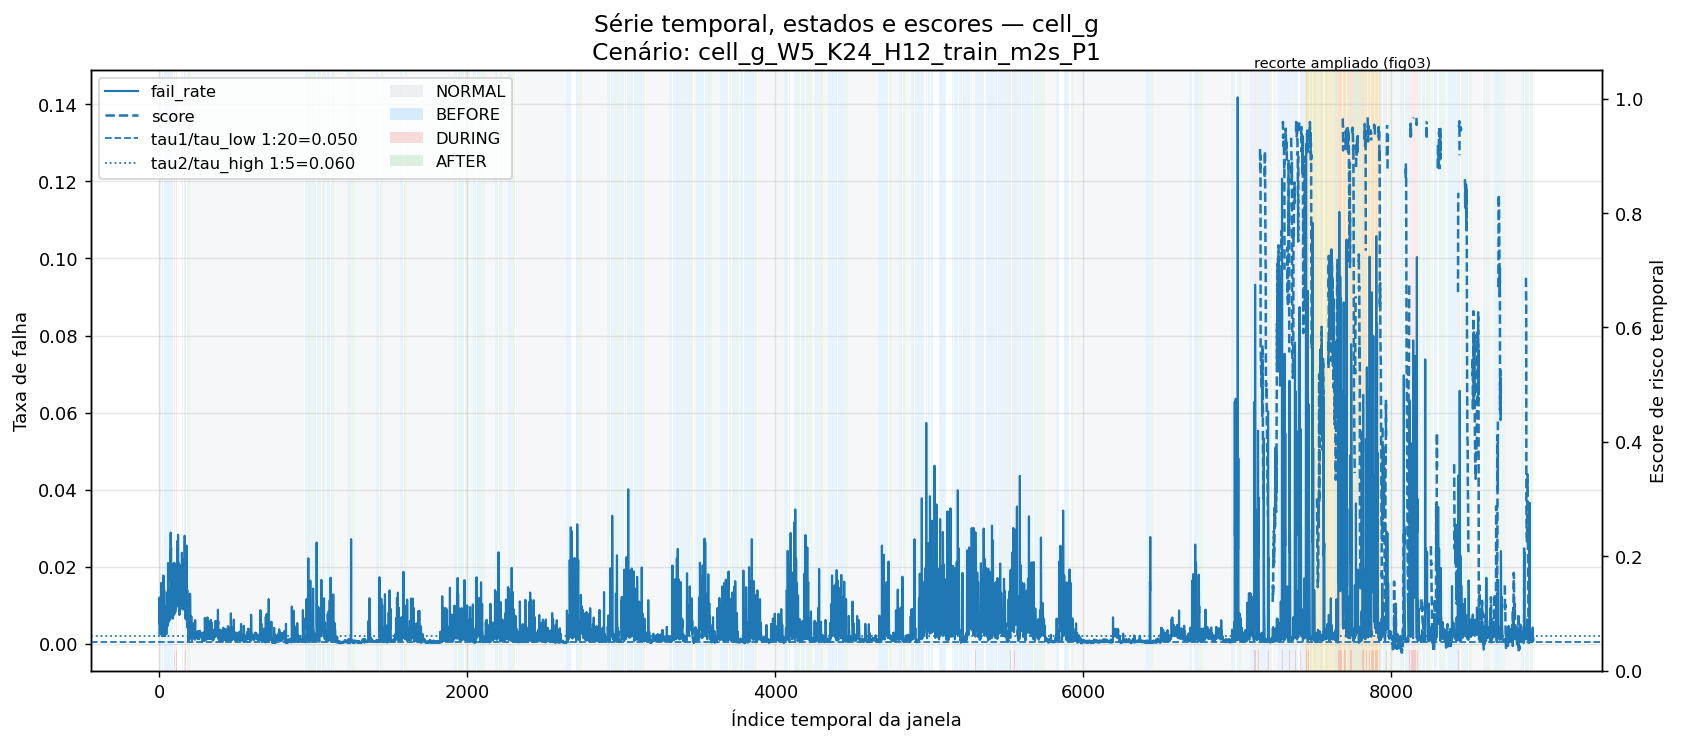

[2026-07-26 01:52:26] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig02_temporal_overview_cell_g.png


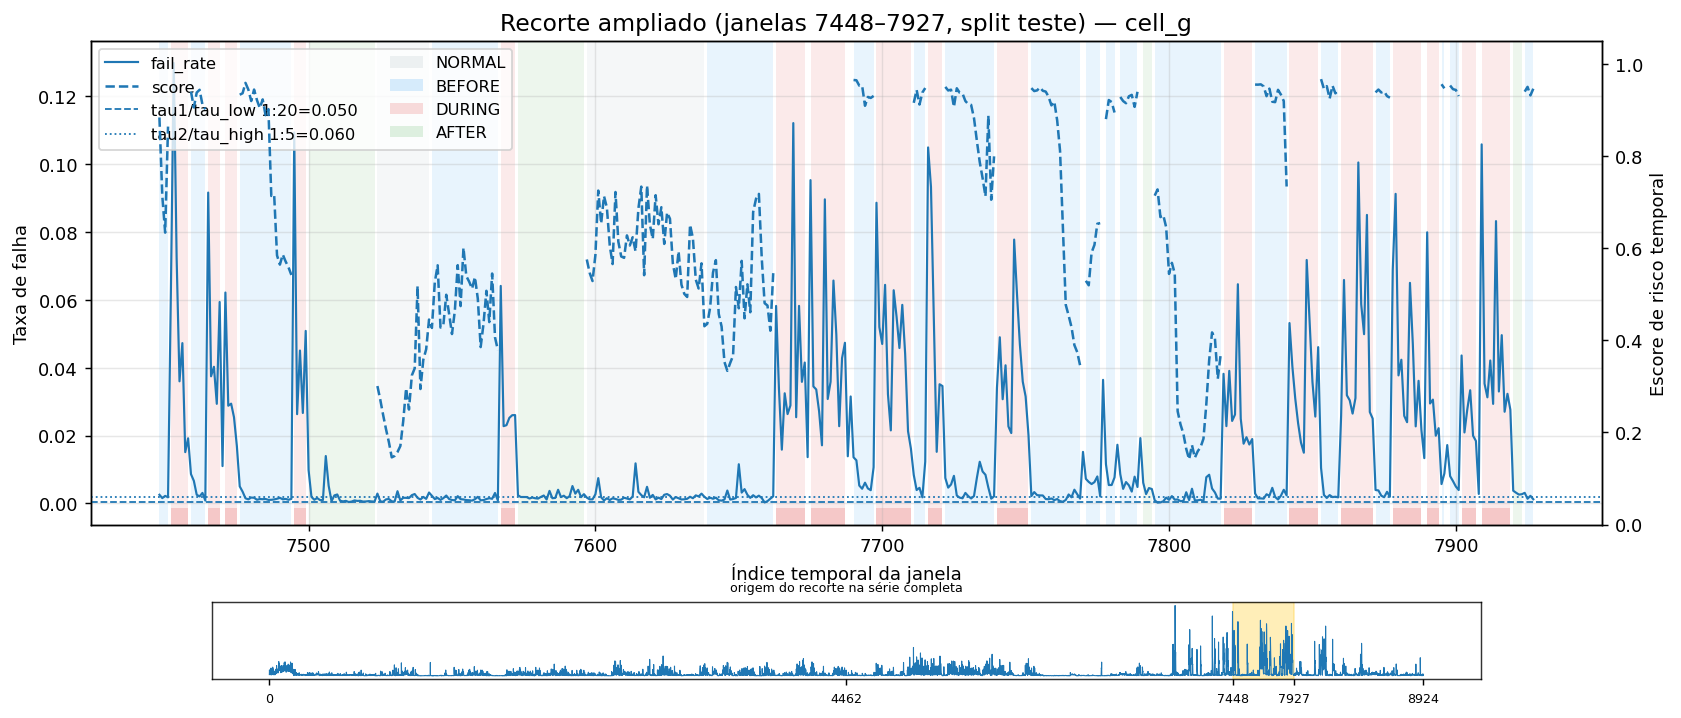

[2026-07-26 01:52:28] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig03_temporal_zoom_cell_g.png


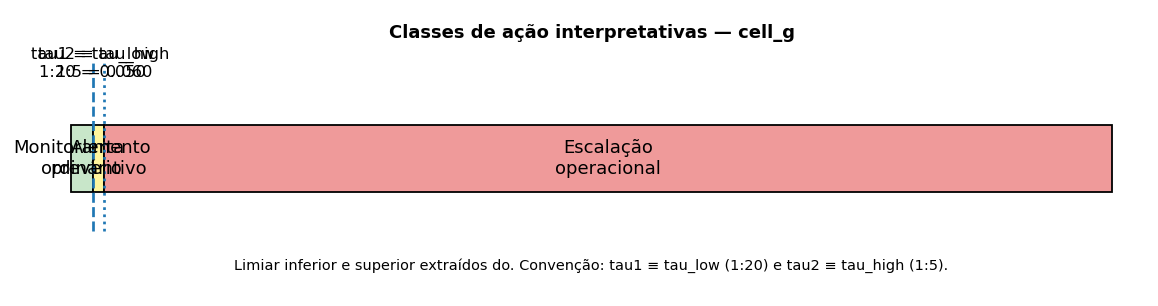

[2026-07-26 01:52:29] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig04_action_classes_cell_g.png


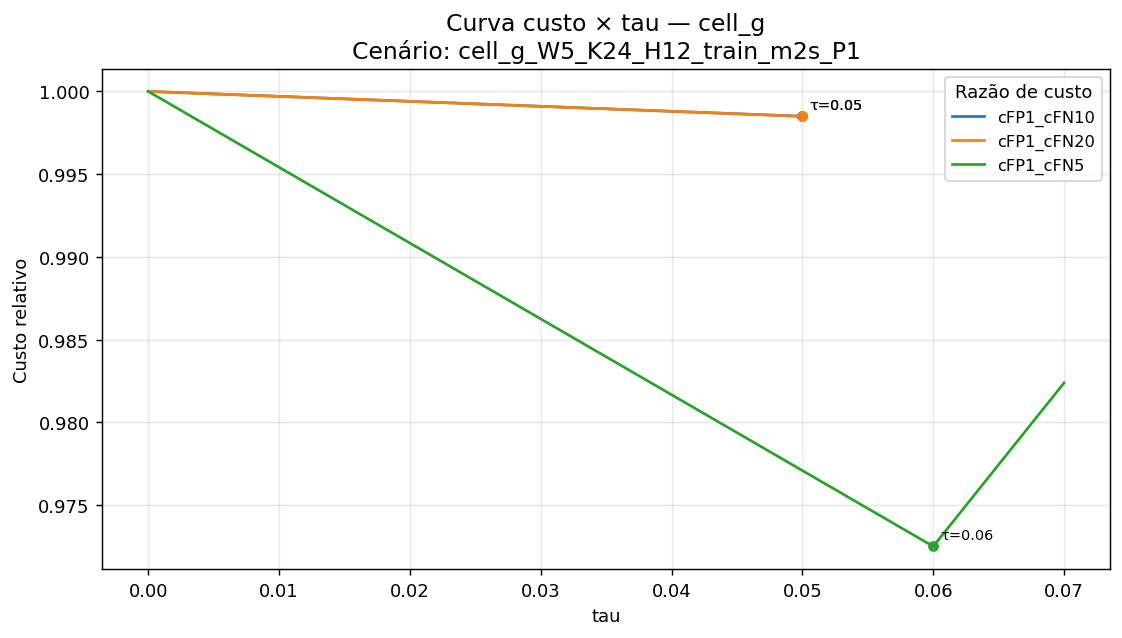

[2026-07-26 01:52:30] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig05_cost_tau_cell_g.png


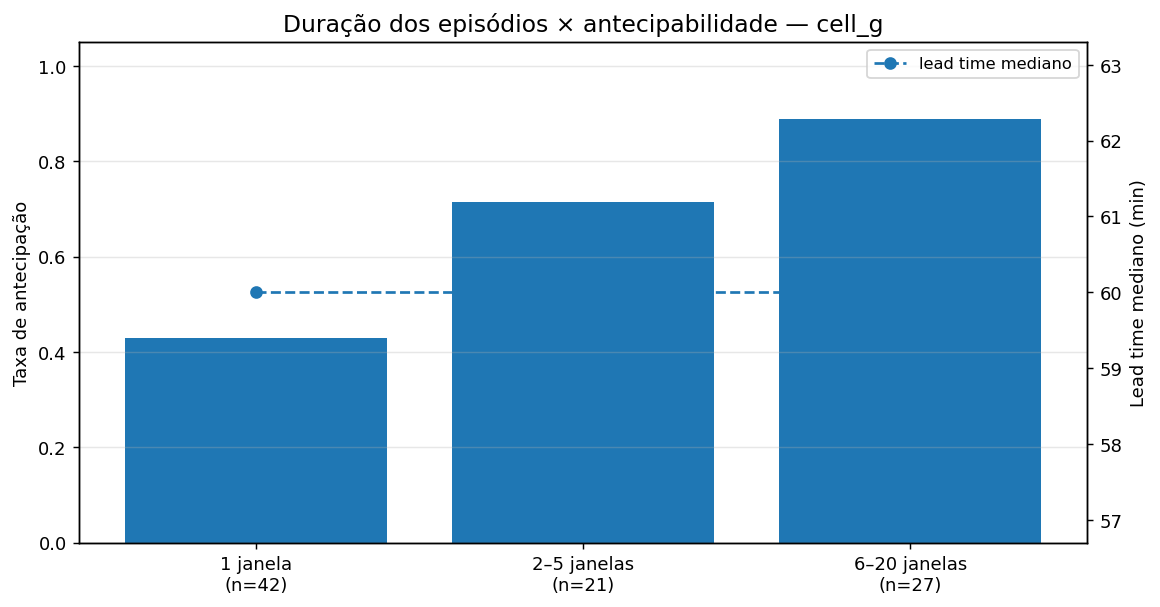

[2026-07-26 01:52:32] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_g/figures/15_FULL_fig06_duration_anticipability_cell_g.png
[2026-07-26 01:52:32] 
--- Processando cell_h ---


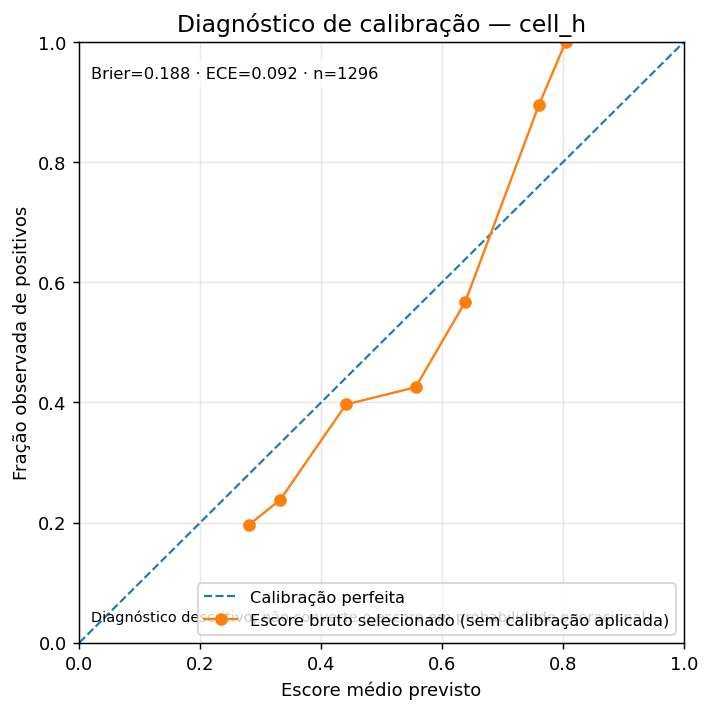

[2026-07-26 01:52:35] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig07_calibration_cell_h.png


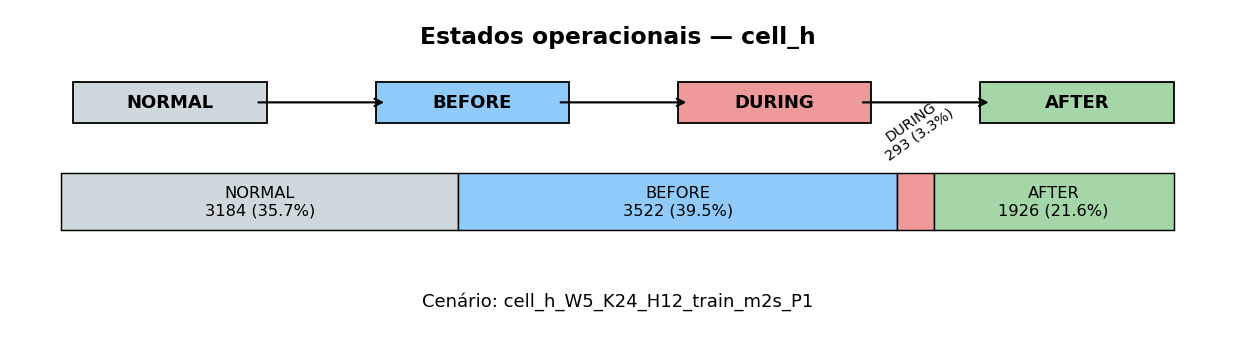

[2026-07-26 01:52:36] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig01_state_diagram_cell_h.png


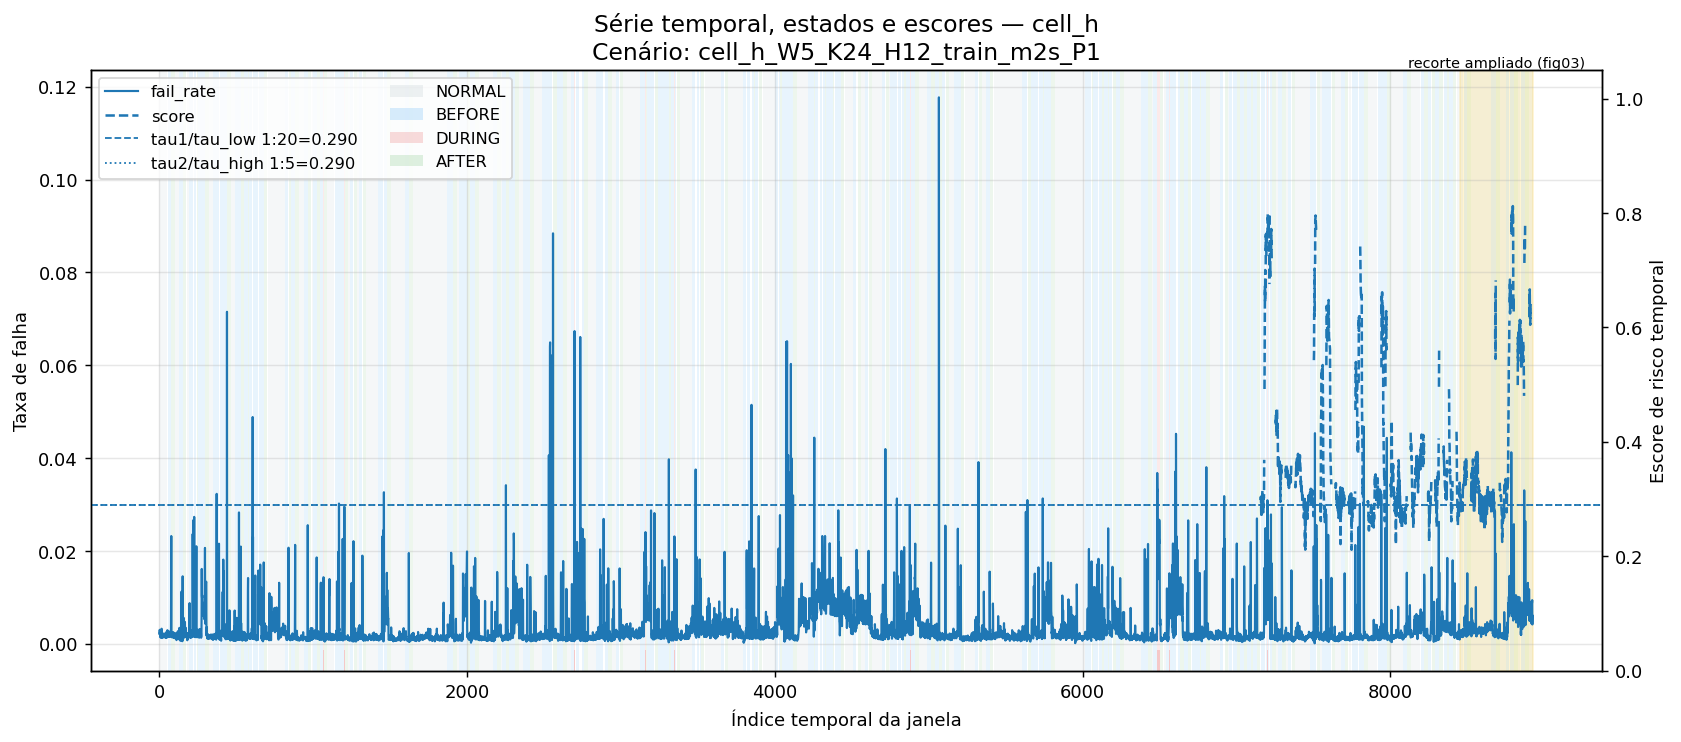

[2026-07-26 01:52:39] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig02_temporal_overview_cell_h.png


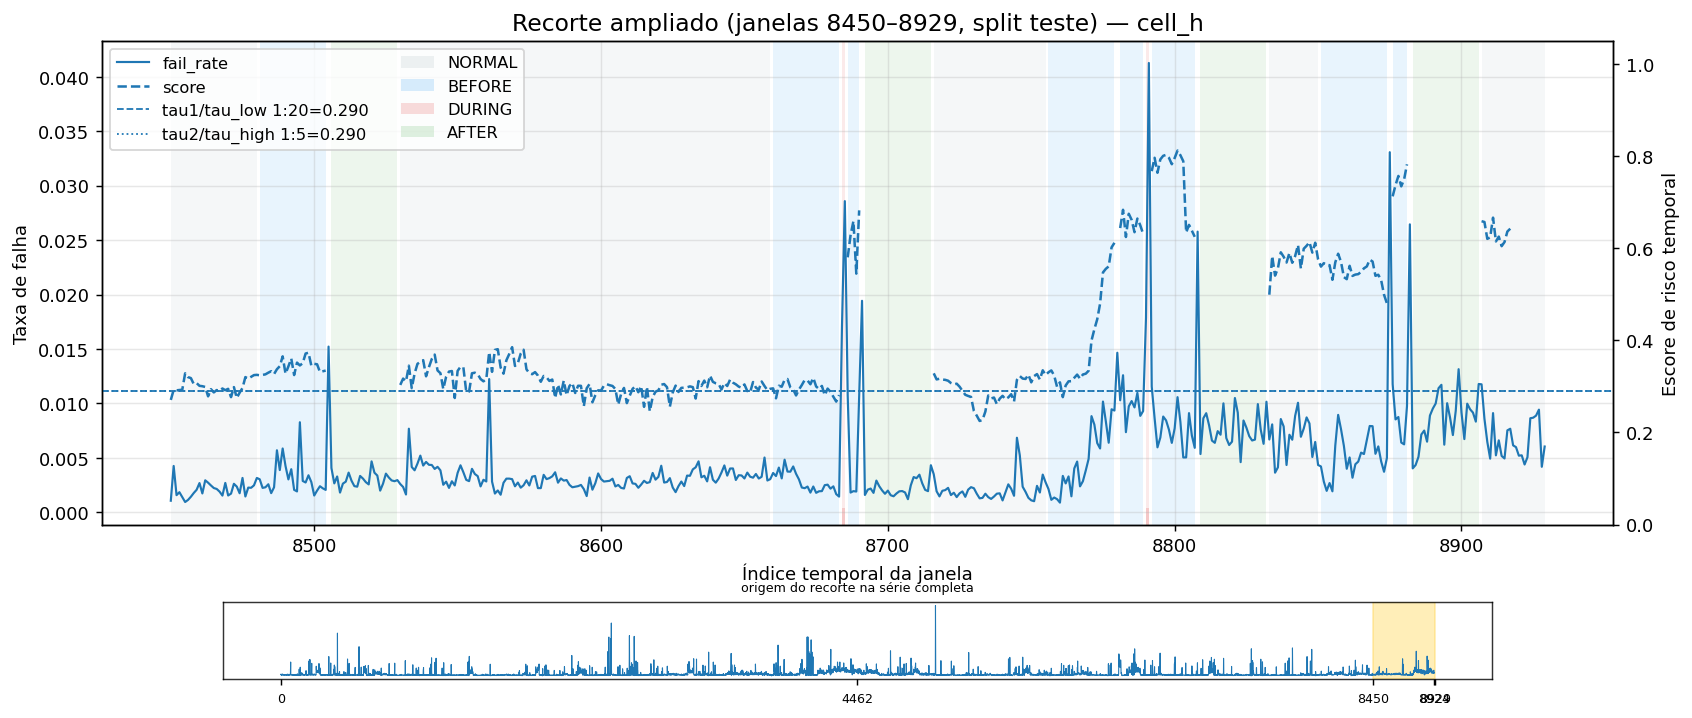

[2026-07-26 01:52:41] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig03_temporal_zoom_cell_h.png


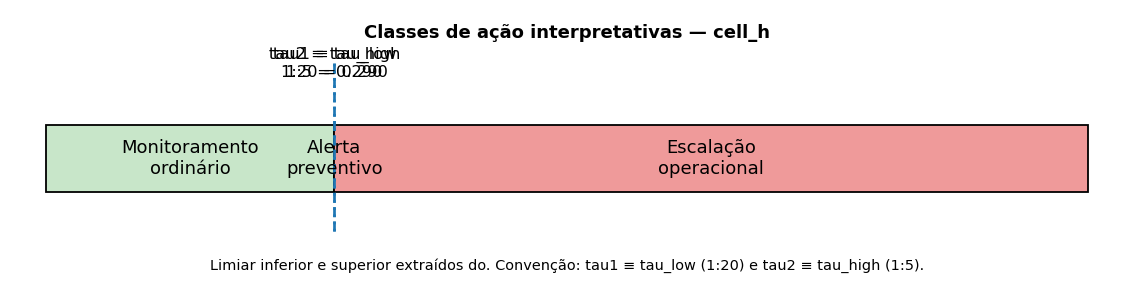

[2026-07-26 01:52:41] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig04_action_classes_cell_h.png


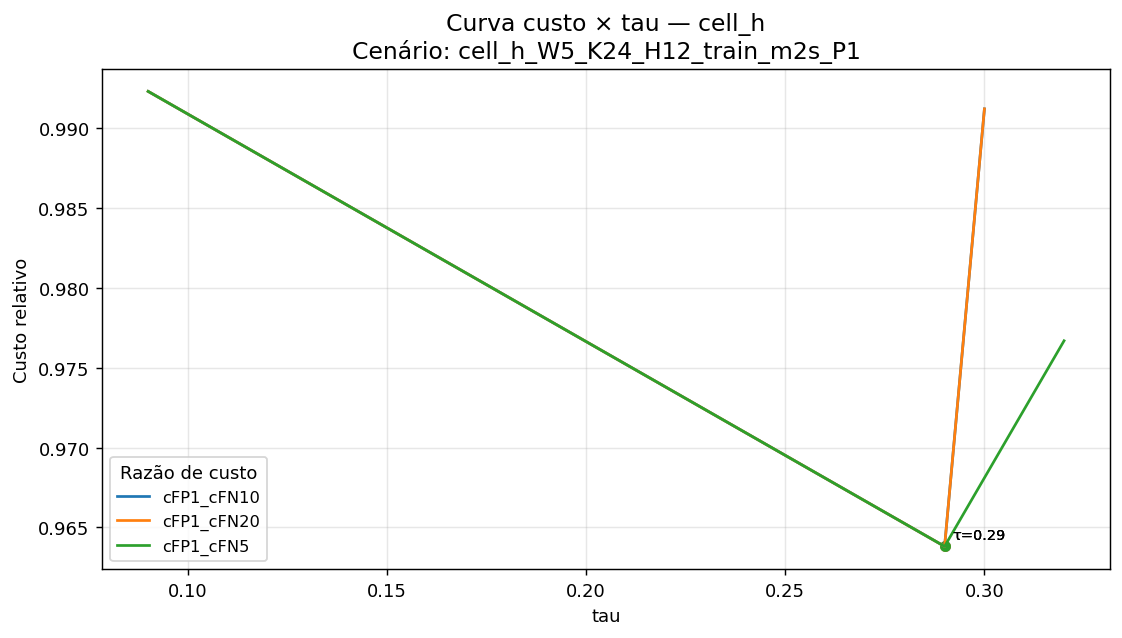

[2026-07-26 01:52:42] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig05_cost_tau_cell_h.png


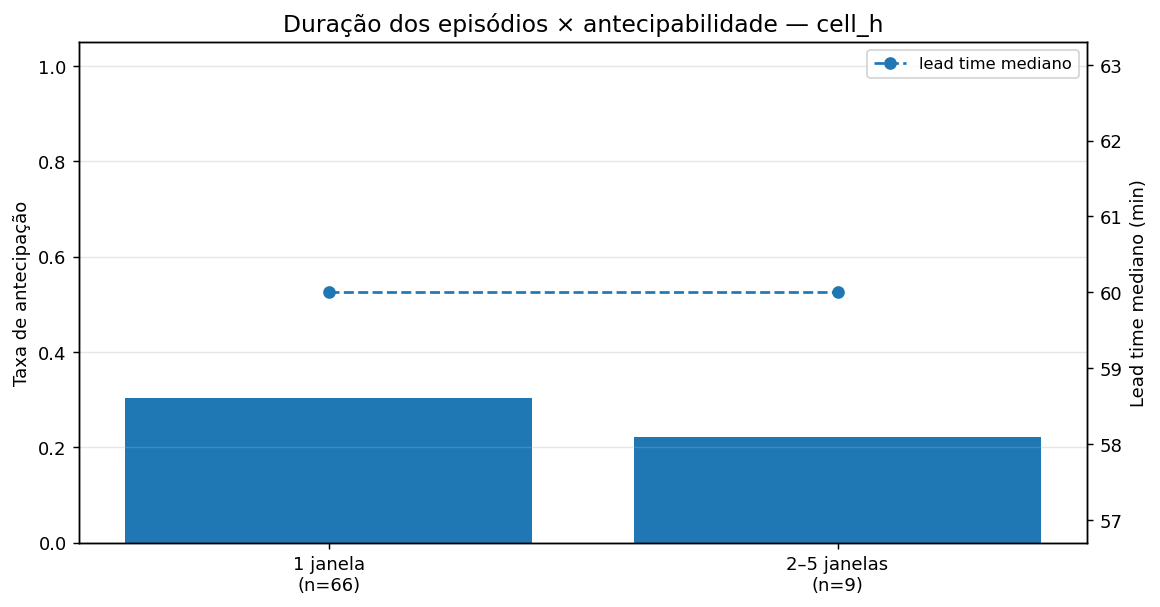

[2026-07-26 01:52:43] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/cell_h/figures/15_FULL_fig06_duration_anticipability_cell_h.png


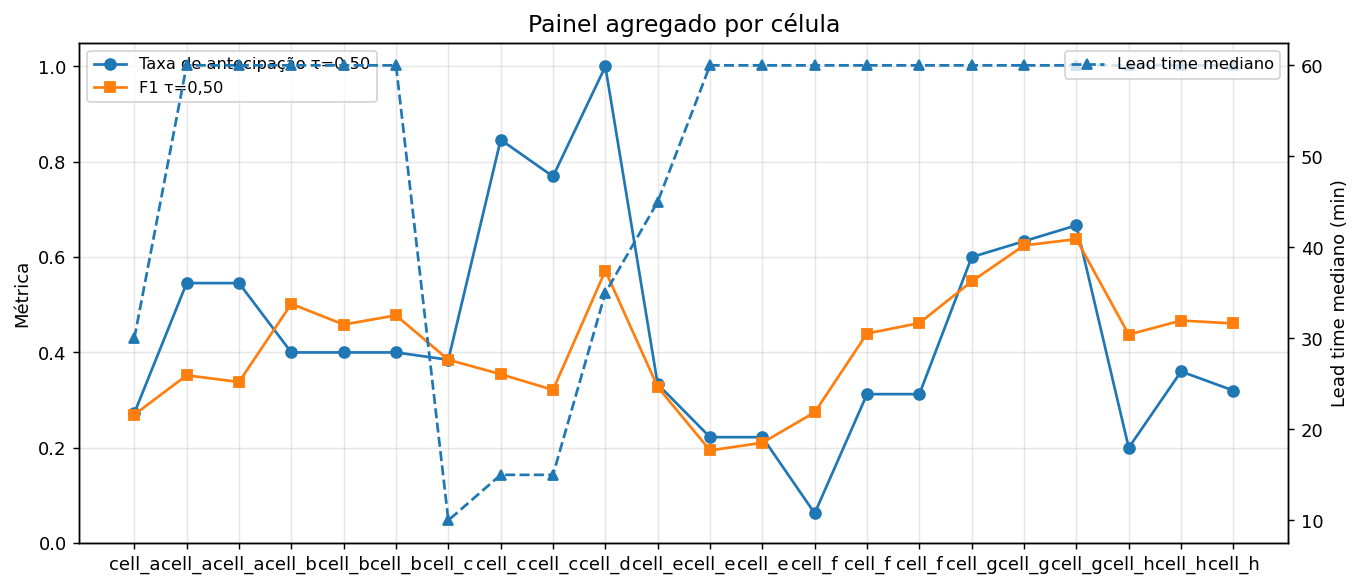

[2026-07-26 01:52:45] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/figures/15_FULL_figA_dashboard_by_cell.png


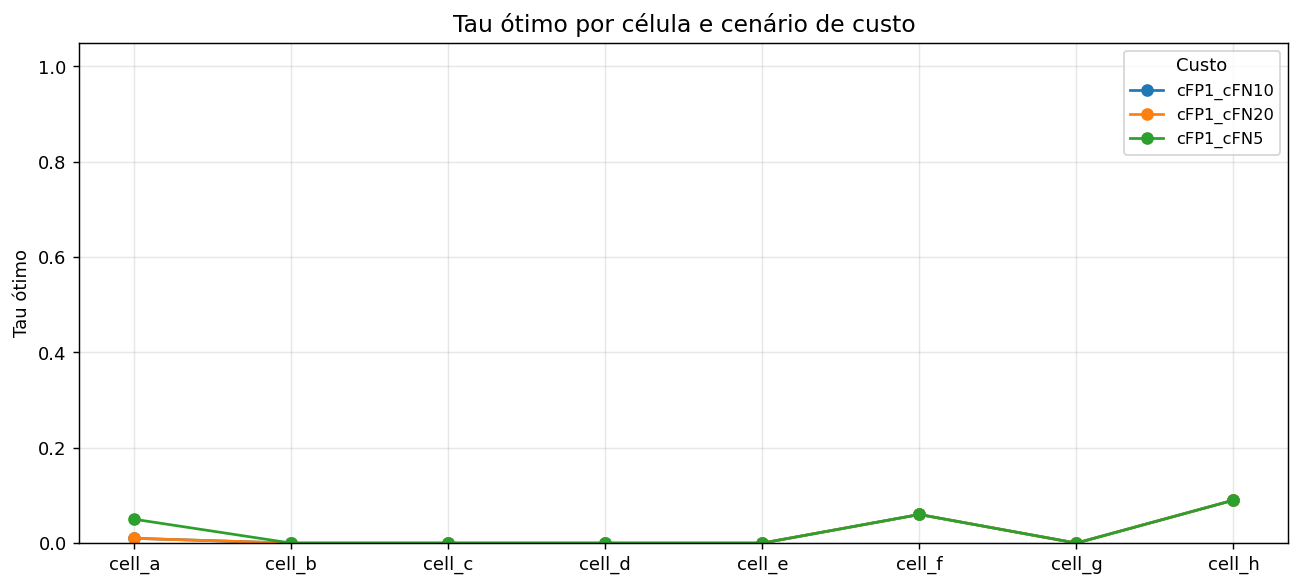

[2026-07-26 01:52:46] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/figures/15_FULL_figB_tau_by_cell.png


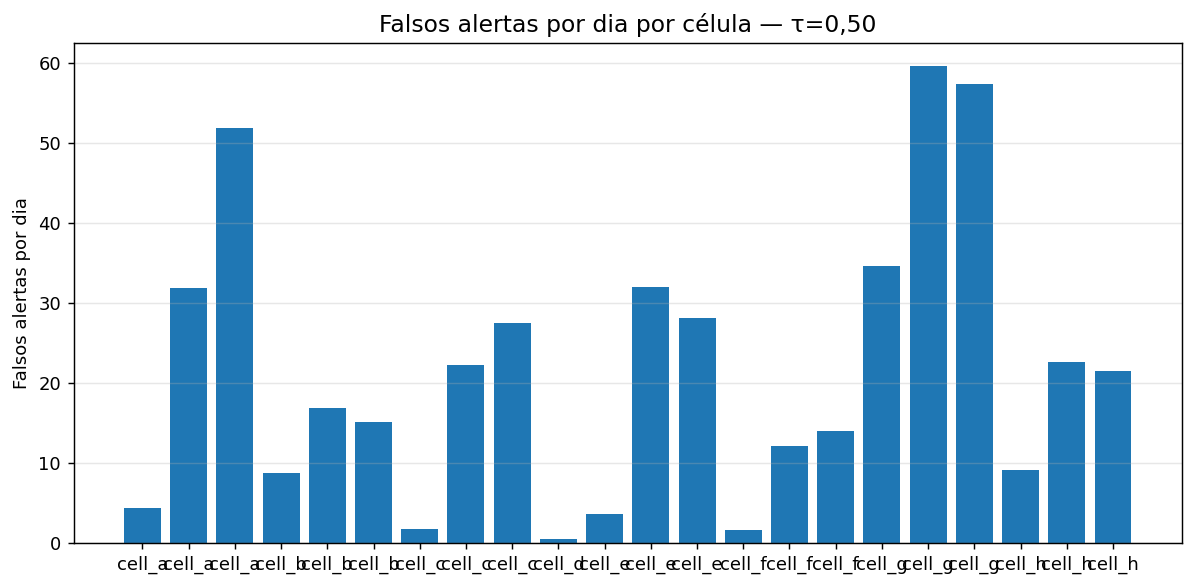

[2026-07-26 01:52:47] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/figures/15_FULL_figC_false_alerts_by_cell.png


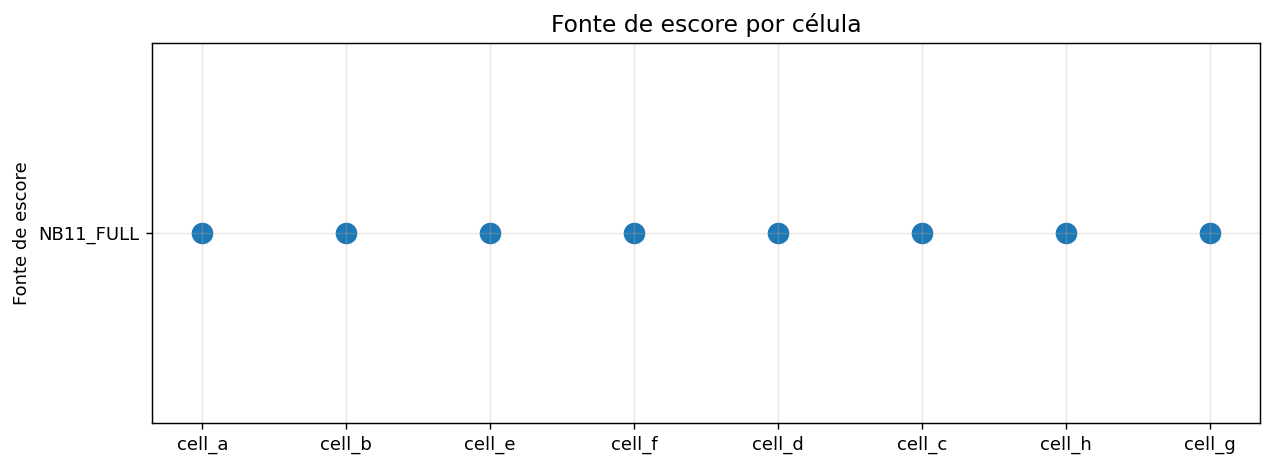

[2026-07-26 01:52:48] Figura salva: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/figures/15_FULL_figD_score_source_by_cell.png
[2026-07-26 01:52:51] Manifesto SHA-256 final OK: 142 arquivos listados; nenhuma divergência detectada.

NB15_FULL concluído.
STAGE15_DIR: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization
Aggregate: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate
Manifesto visual: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/15_FULL_visual_manifest_allcells.csv
Calibração por célula: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/15_FULL_calibration_diagnostics_by_cell.csv
Resumo JSON: /content/drive/MyDrive/Mestrado/04-reports/99_FULL_downstream/15_FULL_visualization/aggregate/15_FULL_nb15_summary.json
Manifesto SHA-256: /content/drive/MyDrive/Mestrado/04

In [ ]:
"""
NB15_FULL — Visualização final e síntese gráfica por célula

Etapa de visualização do ramo _FULL.
Consome NB10_FULL e NB14_FULL.
Não recalcula modelos, limiares, estados, episódios, custos ou decisões.
"""

from __future__ import annotations

import json
import warnings
import hashlib
import re
from dataclasses import dataclass
from datetime import datetime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

try:
    from IPython.display import display
except Exception:
    display = None

warnings.filterwarnings("ignore")


# ============================================================
# 1. CONFIGURAÇÃO GERAL
# ============================================================

NB15_FULL_VERSION = "v1.3"
RUN_TIMESTAMP = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")

SCENARIO_MAIN = "W5_K24_H12_P1_TRAIN_M2S"
FULL_CELLS = list("abcdefgh")
ACTIVE_CELLS = FULL_CELLS        # usar ["a"] para piloto
DISPLAY_FIGURES_INLINE = True
SAVE_PDF = True

STATE_ORDER = ["NORMAL", "BEFORE", "DURING", "AFTER"]
STATE_COLORS = {
    "NORMAL": "#cfd8dc",
    "BEFORE": "#90caf9",
    "DURING": "#ef9a9a",
    "AFTER": "#a5d6a7",
}
ACTION_COLORS = {
    "monitoramento": "#c8e6c9",
    "alerta": "#fff59d",
    "escalacao": "#ef9a9a",
}

plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["font.size"] = 10


def now_str() -> str:
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def log(msg: str) -> None:
    print(f"[{now_str()}] {msg}", flush=True)


def detect_colab() -> bool:
    try:
        import google.colab  # type: ignore  # noqa: F401
        return True
    except Exception:
        return False


IN_COLAB = detect_colab()
if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive")
    except Exception as exc:
        log(f"[AVISO] Não foi possível montar o Google Drive automaticamente: {exc}")


BASE_DIR = (
    Path("/content/drive/MyDrive/Mestrado")
    if Path("/content/drive/MyDrive/Mestrado").exists()
    else Path.cwd()
)

FULL_REPORTS_DIR = BASE_DIR / "04-reports" / "99_FULL_downstream"
STAGE10_DIR = FULL_REPORTS_DIR / "10_FULL_threshold_diagnostics"
STAGE14_DIR = FULL_REPORTS_DIR / "14_FULL_decision_analysis"
STAGE15_DIR = FULL_REPORTS_DIR / "15_FULL_visualization"

AGGREGATE_DIR = STAGE15_DIR / "aggregate"
AGG_FIGURES_DIR = AGGREGATE_DIR / "figures"

# Travas de mundo.
assert "99_FULL_downstream" in str(FULL_REPORTS_DIR), "FULL_REPORTS_DIR deve apontar para 99_FULL_downstream."
assert "03-features" not in str(STAGE15_DIR), "NB15_FULL não pode escrever em 03-features."

log("=" * 100)
log("NB15_FULL — Visualização final e síntese gráfica por célula")
log(f"Versão        : {NB15_FULL_VERSION}")
log(f"Timestamp     : {RUN_TIMESTAMP}")
log(f"BASE_DIR      : {BASE_DIR}")
log(f"FULL_REPORTS  : {FULL_REPORTS_DIR}")
log(f"STAGE10_DIR   : {STAGE10_DIR}")
log(f"STAGE14_DIR   : {STAGE14_DIR}")
log(f"STAGE15_DIR   : {STAGE15_DIR}")
log(f"ACTIVE_CELLS  : {ACTIVE_CELLS}")
log("=" * 100)


# ============================================================
# 2. ESTRUTURAS AUXILIARES
# ============================================================

@dataclass
class CellArtifacts:
    cell_id: str
    series_states: Optional[Path] = None
    episodes: Optional[Path] = None
    scores_selected: Optional[Path] = None
    cost_curve: Optional[Path] = None
    optimal_tau: Optional[Path] = None
    duration_summary: Optional[Path] = None
    scenario_summary: Optional[Path] = None


@dataclass
class AggregateArtifacts:
    scenario_summary_by_cell: Optional[Path] = None
    cost_summary_by_cell: Optional[Path] = None
    optimal_tau_allcells: Optional[Path] = None
    cost_curve_allcells: Optional[Path] = None
    duration_summary_allcells: Optional[Path] = None
    pilot_validation_summary: Optional[Path] = None
    nb14_summary_json: Optional[Path] = None


@dataclass
class TauInfo:
    tau_low: Optional[float]
    tau_high: Optional[float]
    source: Optional[str]
    note: str


# ============================================================
# 3. UTILITÁRIOS DE I/O
# ============================================================

def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def json_ready(obj):
    if isinstance(obj, dict):
        return {str(k): json_ready(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [json_ready(v) for v in obj]
    if isinstance(obj, tuple):
        return [json_ready(v) for v in obj]
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        v = float(obj)
        return None if np.isnan(v) else v
    if isinstance(obj, float):
        return None if np.isnan(obj) else obj
    if pd.isna(obj) if not isinstance(obj, (str, bytes, list, dict, tuple)) else False:
        return None
    return obj


def save_json(obj: Dict, path: Path) -> None:
    ensure_dir(path.parent)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(json_ready(obj), f, ensure_ascii=False, indent=2)


def save_csv(df: pd.DataFrame, path: Path) -> None:
    ensure_dir(path.parent)
    df.to_csv(path, index=False, encoding="utf-8")


def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in {".parquet", ".pq"}:
        return pd.read_parquet(path)
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    raise ValueError(f"Formato não suportado: {path}")


def file_sha256(path: Path, chunk_size: int = 1024 * 1024) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()


def collect_artifact_manifest(root: Path, out_path: Path) -> pd.DataFrame:
    """
    Coleta o manifesto SHA-256 sem gravá-lo.

    A função exclui apenas o próprio arquivo de manifesto, para que o manifesto
    final possa ser gerado como a última escrita da etapa sem se auto-incluir.
    """
    rows = []
    root = Path(root)
    out_path = Path(out_path)
    out_resolved = out_path.resolve()
    for p in sorted(root.rglob("*")):
        if p.is_file() and p.resolve() != out_resolved:
            rows.append({
                "relative_path": str(p.relative_to(root)),
                "size_bytes": int(p.stat().st_size),
                "sha256": file_sha256(p),
            })
    return pd.DataFrame(rows)


def build_artifact_manifest(root: Path, out_path: Path) -> pd.DataFrame:
    """Gera o manifesto SHA-256 no disco, excluindo o próprio manifesto."""
    df = collect_artifact_manifest(root, out_path)
    save_csv(df, out_path)
    return df


def verify_artifact_manifest(root: Path, manifest_path: Path) -> pd.DataFrame:
    """
    Verifica se o manifesto gravado corresponde ao estado atual dos arquivos.

    Esta função não grava artefatos, para não invalidar o manifesto recém-gerado.
    Retorna um DataFrame de divergências. DataFrame vazio significa manifesto OK.
    """
    root = Path(root)
    manifest_path = Path(manifest_path)
    if not manifest_path.exists():
        return pd.DataFrame([{
            "relative_path": str(manifest_path),
            "issue": "manifest_missing",
            "expected": "arquivo existente",
            "observed": "ausente",
        }])

    manifest_df = pd.read_csv(manifest_path)
    required_cols = {"relative_path", "size_bytes", "sha256"}
    missing_cols = sorted(required_cols - set(manifest_df.columns))
    if missing_cols:
        return pd.DataFrame([{
            "relative_path": str(manifest_path),
            "issue": "manifest_missing_columns",
            "expected": ", ".join(sorted(required_cols)),
            "observed": ", ".join(manifest_df.columns),
        }])

    rows = []
    for row in manifest_df.to_dict("records"):
        rel = str(row["relative_path"])
        p = root / rel
        if not p.exists():
            rows.append({
                "relative_path": rel,
                "issue": "missing_file",
                "expected": "arquivo existente",
                "observed": "ausente",
            })
            continue
        actual_size = int(p.stat().st_size)
        expected_size = int(row["size_bytes"])
        if actual_size != expected_size:
            rows.append({
                "relative_path": rel,
                "issue": "size_mismatch",
                "expected": expected_size,
                "observed": actual_size,
            })
        actual_sha = file_sha256(p)
        expected_sha = str(row["sha256"])
        if actual_sha != expected_sha:
            rows.append({
                "relative_path": rel,
                "issue": "sha256_mismatch",
                "expected": expected_sha,
                "observed": actual_sha,
            })

    manifest_paths = set(manifest_df["relative_path"].astype(str))
    manifest_resolved = manifest_path.resolve()
    current_paths = {
        str(p.relative_to(root))
        for p in root.rglob("*")
        if p.is_file() and p.resolve() != manifest_resolved
    }
    for rel in sorted(current_paths - manifest_paths):
        rows.append({
            "relative_path": rel,
            "issue": "extra_file_not_in_manifest",
            "expected": "arquivo listado no manifesto",
            "observed": "arquivo presente fora do manifesto",
        })

    return pd.DataFrame(rows)


def first_existing(candidates: Sequence[Path]) -> Optional[Path]:
    for p in candidates:
        if p is not None and p.exists():
            return p
    return None


def first_glob(root: Path, patterns: Sequence[str]) -> Optional[Path]:
    if not root.exists():
        return None
    found = []
    for pat in patterns:
        found.extend(root.glob(pat))
    found = [p for p in found if p.exists()]
    if not found:
        return None
    return sorted(found, key=lambda p: (p.stat().st_mtime, str(p)), reverse=True)[0]


def lower_map(df: pd.DataFrame) -> Dict[str, str]:
    return {str(c).lower(): c for c in df.columns}


def first_col(df: pd.DataFrame, candidates: Sequence[str], required: bool = False, label: str = "coluna") -> Optional[str]:
    lm = lower_map(df)
    for c in candidates:
        if c.lower() in lm:
            return lm[c.lower()]
    # fallback por contains
    for c in candidates:
        token = c.lower()
        for low, orig in lm.items():
            if token in low:
                return orig
    if required:
        raise ValueError(f"Não foi possível localizar {label}. Candidatos={candidates}; disponíveis={list(df.columns)}")
    return None


def numeric(s, default=np.nan):
    out = pd.to_numeric(s, errors="coerce")
    if default is not np.nan:
        out = out.fillna(default)
    return out



def filter_scenario(df: pd.DataFrame, scenario: str = SCENARIO_MAIN) -> pd.DataFrame:
    """Filtra um DataFrame pelo cenário solicitado, preservando metadados de fallback.

    O NB15_FULL é etapa visual. Por isso, quando o artefato não possui coluna de
    cenário ou quando o cenário solicitado não está presente, a função retorna um
    fallback documentado em ``df.attrs`` em vez de interromper a execução inteira.
    O ``process_cell`` registra essa condição no summary/pilot validation.
    """
    out_attrs = {
        "requested_scenario": str(scenario),
        "scenario_filter_status": "NO_SCENARIO_COLUMN",
        "available_scenarios": [],
        "observed_scenarios": [],
    }
    sc = first_col(df, ["scenario_label", "scenario", "scenario_id", "config_label"], required=False)
    if sc is None:
        out = df.copy()
        out.attrs.update(out_attrs)
        return out

    available = sorted(df[sc].dropna().astype(str).unique().tolist())
    out_attrs["available_scenarios"] = available
    mask = df[sc].astype(str).str.upper().eq(str(scenario).upper())
    filtered = df.loc[mask].copy()
    if filtered.empty:
        out = df.copy()
        out_attrs["scenario_filter_status"] = "WARN_FALLBACK_UNFILTERED"
        out_attrs["observed_scenarios"] = available
        out.attrs.update(out_attrs)
        return out

    out_attrs["scenario_filter_status"] = "OK"
    out_attrs["observed_scenarios"] = sorted(filtered[sc].dropna().astype(str).unique().tolist())
    filtered.attrs.update(out_attrs)
    return filtered


def normalize_cell_id(value) -> str:
    return str(value).strip().lower().replace("cell_", "")


# ============================================================
# 4. LOCALIZAÇÃO DE ARTEFATOS
# ============================================================

def resolve_cell_artifacts(cell_id: str) -> CellArtifacts:
    cid = normalize_cell_id(cell_id)
    cell10 = STAGE10_DIR / f"cell_{cid}"
    cell14 = STAGE14_DIR / f"cell_{cid}"

    artifacts = CellArtifacts(
        cell_id=cid,
        series_states=first_existing([
            cell10 / f"10_FULL_scenario_series_states_cell_{cid}.parquet",
        ]) or first_glob(cell10, [f"*series*states*cell_{cid}*.parquet", "*series*states*.parquet"]),
        episodes=first_existing([
            cell10 / f"10_FULL_scenario_episodes_cell_{cid}.parquet",
        ]) or first_glob(cell10, [f"*episodes*cell_{cid}*.parquet", "*episodes*.parquet"]),
        scores_selected=first_existing([
            cell14 / f"14_FULL_scores_selected_cell_{cid}.parquet",
        ]) or first_glob(cell14, [f"*scores*selected*cell_{cid}*.parquet", "*scores*selected*.parquet"]),
        cost_curve=first_existing([
            cell14 / f"14_FULL_cost_curve_cell_{cid}.csv",
        ]) or first_glob(cell14, [f"*cost*curve*cell_{cid}*.csv", "*cost*curve*.csv"]),
        optimal_tau=first_existing([
            cell14 / f"14_FULL_optimal_tau_by_cost_cell_{cid}.csv",
        ]) or first_glob(cell14, [f"*optimal*tau*cell_{cid}*.csv", "*optimal*tau*.csv"]),
        duration_summary=first_existing([
            cell14 / f"14_FULL_episode_duration_summary_cell_{cid}.csv",
        ]) or first_glob(cell14, [f"*duration*summary*cell_{cid}*.csv", "*duration*summary*.csv"]),
        scenario_summary=first_existing([
            cell14 / f"14_FULL_scenario_summary_cell_{cid}.csv",
        ]) or first_glob(cell14, [f"*scenario*summary*cell_{cid}*.csv", "*scenario*summary*.csv"]),
    )
    return artifacts


def truthy_series(s: pd.Series) -> pd.Series:
    """Converte valores heterogêneos de flag para booleano."""
    if s is None:
        return pd.Series(dtype=bool)
    txt = s.astype(str).str.strip().str.lower()
    return txt.isin(["1", "true", "t", "yes", "y", "sim", "s", "winner", "selected", "primary"])


def resolve_primary_scenario(artifacts: CellArtifacts, fallback: str = SCENARIO_MAIN) -> Dict:
    """Resolve o cenário efetivamente primário da célula a partir do NB14_FULL.

    Prioridade:
    1. linhas de ``14_FULL_scenario_summary_cell_<id>.csv`` com
       ``is_primary_score_source == 1``;
    2. fallback documentado para a melhor linha disponível quando a marcação
       primária não existir ou estiver vazia;
    3. fallback explícito para ``SCENARIO_MAIN`` quando o artefato ou a coluna
       de cenário não estiverem disponíveis.

    Importante: quando a seleção não vem da flag primária do NB14_FULL, o status
    permanece ``WARN_FALLBACK``. Isso evita que c/e/d, ou qualquer célula com
    cenário vencedor diferente do default, passem silenciosamente por uma escolha
    aproximada.
    """
    cid = artifacts.cell_id
    info = {
        "cell_id": cid,
        "scenario_label": str(fallback),
        "status": "WARN_FALLBACK",
        "source": str(artifacts.scenario_summary) if artifacts.scenario_summary else None,
        "reason": "fallback_SCENARIO_MAIN",
        "available_scenarios": [],
        "n_primary_rows": 0,
        "selected_score_source": None,
        "used_primary_flag": False,
        "selection_method": "fallback_SCENARIO_MAIN",
    }
    if artifacts.scenario_summary is None or not Path(artifacts.scenario_summary).exists():
        info["reason"] = "scenario_summary_cell ausente; usando SCENARIO_MAIN como padrão"
        return info

    try:
        df = read_table(artifacts.scenario_summary)
    except Exception as exc:
        info["reason"] = f"erro ao ler scenario_summary_cell: {type(exc).__name__}: {exc}; usando fallback"
        return info

    if df.empty:
        info["reason"] = "scenario_summary_cell vazio; usando fallback"
        return info

    cell_col = first_col(df, ["cell_id", "cell", "borg_cell"], required=False)
    if cell_col:
        df = df[df[cell_col].map(normalize_cell_id).eq(cid)].copy()
    scenario_col = first_col(df, ["scenario_label", "scenario", "scenario_id", "config_label"], required=False)
    if scenario_col is None or df.empty:
        info["reason"] = "scenario_summary_cell sem scenario_label utilizável; usando fallback"
        return info

    info["available_scenarios"] = sorted(df[scenario_col].dropna().astype(str).unique().tolist())

    primary_col = first_col(df, ["is_primary_score_source", "primary_score_source", "is_primary", "selected"], required=False)
    cand = df.copy()
    used_primary_flag = False
    if primary_col:
        mask = truthy_series(cand[primary_col])
        if mask.any():
            cand = cand[mask].copy()
            used_primary_flag = True
            info["n_primary_rows"] = int(len(cand))
            info["selection_method"] = f"primary_flag:{primary_col}"
        else:
            info["reason"] = (
                "coluna is_primary_score_source/análoga existe, mas nenhuma linha primária foi marcada; "
                "usando melhor linha disponível com WARN_FALLBACK"
            )
            info["selection_method"] = f"best_available_no_true_primary:{primary_col}"
    else:
        info["reason"] = (
            "coluna is_primary_score_source/análoga ausente; usando melhor linha disponível com WARN_FALLBACK"
        )
        info["selection_method"] = "best_available_no_primary_column"

    # Ordenação conservadora para resolver múltiplas linhas primárias ou fallback.
    sort_cols = []
    ascending = []
    for col in ["f1_tau_reference", "f1", "f1_tscv_mean", "recall_tau_reference", "n_scored_rows", "n_total_episodes"]:
        if col in cand.columns:
            sc = f"__sort_{col}__"
            cand[sc] = pd.to_numeric(cand[col], errors="coerce")
            sort_cols.append(sc)
            ascending.append(False)
    if sort_cols:
        cand = cand.sort_values(sort_cols, ascending=ascending, na_position="last")

    selected = cand.iloc[0]
    selected_scenario = str(selected[scenario_col])
    info["scenario_label"] = selected_scenario
    info["used_primary_flag"] = bool(used_primary_flag)
    if used_primary_flag:
        info["status"] = "OK"
        info["reason"] = "cenário resolvido a partir de scenario_summary_cell e flag primária do NB14_FULL"
    score_source_col = first_col(pd.DataFrame([selected]), ["score_source", "source", "score_family"], required=False)
    if score_source_col:
        info["selected_score_source"] = str(selected.get(score_source_col))
    if selected_scenario not in info["available_scenarios"]:
        info["status"] = "WARN_FALLBACK"
        info["reason"] = "cenário selecionado não aparece na lista de cenários disponíveis; verificar artefato NB14_FULL"
    return info

def resolve_aggregate_artifacts() -> AggregateArtifacts:
    agg14 = STAGE14_DIR / "aggregate"
    return AggregateArtifacts(
        scenario_summary_by_cell=first_existing([agg14 / "14_FULL_scenario_summary_by_cell.csv"]),
        cost_summary_by_cell=first_existing([agg14 / "14_FULL_cost_summary_by_cell.csv"]),
        optimal_tau_allcells=first_existing([agg14 / "14_FULL_optimal_tau_by_cost_allcells.csv"]),
        cost_curve_allcells=first_existing([agg14 / "14_FULL_cost_curve_allcells.csv"]),
        duration_summary_allcells=first_existing([agg14 / "14_FULL_episode_duration_summary_allcells.csv"]),
        pilot_validation_summary=first_existing([agg14 / "14_FULL_pilot_validation_summary.csv"]),
        nb14_summary_json=first_existing([agg14 / "14_FULL_nb14_summary.json"]),
    )


def validate_required_upstream(agg: AggregateArtifacts) -> None:
    required = {
        "scenario_summary_by_cell": agg.scenario_summary_by_cell,
        "cost_summary_by_cell": agg.cost_summary_by_cell,
        "optimal_tau_allcells": agg.optimal_tau_allcells,
        "cost_curve_allcells": agg.cost_curve_allcells,
    }
    missing = [k for k, v in required.items() if v is None or not Path(v).exists()]
    if missing:
        raise FileNotFoundError(
            "NB15_FULL requer NB14_FULL aggregate concluído. "
            f"Artefatos ausentes: {missing}. Diretório esperado: {STAGE14_DIR / 'aggregate'}"
        )


def validate_nb14_lineage_contract(agg: AggregateArtifacts) -> Dict:
    """
    Valida que o NB15_FULL consome a linhagem FULL vigente.

    O notebook é estritamente downstream: não reconstrói conjuntos de atributos.
    Por isso, a conformidade 6/13 é exigida diretamente do summary final do NB14_FULL.
    """
    summary_path = agg.nb14_summary_json
    if summary_path is None or not Path(summary_path).exists():
        raise FileNotFoundError(
            "NB15_FULL requer 14_FULL_nb14_summary.json para validar a linhagem upstream."
        )

    with open(summary_path, "r", encoding="utf-8") as f:
        summary = json.load(f)

    contract = summary.get("feature_contract")
    if not isinstance(contract, dict):
        raise AssertionError(
            "NB14_FULL sem feature_contract: execute o NB14_FULL vigente antes do NB15_FULL."
        )

    raw_features = list(contract.get("raw_core") or [])
    temporal_features = list(contract.get("temporal_core") or [])

    assert contract.get("raw_core_count") == 6, (
        f"Contrato upstream inválido: raw_core_count={contract.get('raw_core_count')!r}; esperado=6."
    )
    assert contract.get("temporal_core_count") == 13, (
        f"Contrato upstream inválido: temporal_core_count={contract.get('temporal_core_count')!r}; esperado=13."
    )
    assert len(raw_features) == 6, f"raw_core upstream possui {len(raw_features)} atributos; esperado=6."
    assert len(temporal_features) == 13, f"temporal_core upstream possui {len(temporal_features)} atributos; esperado=13."
    assert len(raw_features) == len(set(raw_features)), "raw_core upstream contém nomes repetidos."
    assert len(temporal_features) == len(set(temporal_features)), "temporal_core upstream contém nomes repetidos."
    assert "event_FAIL_count" not in raw_features, "event_FAIL_count reapareceu em raw_core upstream."
    assert "event_FAIL_count" not in temporal_features, "event_FAIL_count reapareceu em temporal_core upstream."
    assert bool(contract.get("event_FAIL_count_excluded_from_predictors")) is True, (
        "NB14_FULL não confirmou a exclusão de event_FAIL_count dos preditores."
    )

    return {
        "summary_path": str(summary_path),
        "raw_core_count": 6,
        "temporal_core_count": 13,
        "event_FAIL_count_excluded_from_predictors": True,
    }


# ============================================================
# 5. PREPARAÇÃO DE DADOS PARA FIGURAS POR CÉLULA
# ============================================================

def standardize_state(value) -> str:
    v = str(value).strip().upper()
    aliases = {
        "N": "NORMAL",
        "NORMAL": "NORMAL",
        "BEFORE": "BEFORE",
        "PRE": "BEFORE",
        "PRÉ": "BEFORE",
        "DURING": "DURING",
        "CRITICAL": "DURING",
        "CRITICO": "DURING",
        "CRÍTICO": "DURING",
        "AFTER": "AFTER",
        "POST": "AFTER",
        "PÓS": "AFTER",
    }
    return aliases.get(v, v)



def prepare_states_frame(path: Path, cell_id: str, scenario_label: str = SCENARIO_MAIN) -> pd.DataFrame:
    filtered = filter_scenario(read_table(path), scenario_label)
    filter_attrs = dict(filtered.attrs)
    df = filtered.copy()
    cell_col = first_col(df, ["cell_id", "cell", "borg_cell"], required=False)
    if cell_col:
        df = df[df[cell_col].map(normalize_cell_id).eq(normalize_cell_id(cell_id))].copy()

    bucket_col = first_col(df, ["bucket_id", "bucket", "time_order", "pos", "row_position"], required=True, label="bucket_id em estados")
    state_col = first_col(df, ["state", "state_nb10", "operational_state", "estado", "S"], required=True, label="estado operacional")
    fail_col = first_col(df, ["fail_rate", "fail_rate_std", "failure_rate"], required=False)
    split_col = first_col(df, ["split", "dataset_split"], required=False)
    scenario_col = first_col(df, ["scenario_label", "scenario", "scenario_id", "config_label"], required=False)

    observed_scenario = df[scenario_col].astype(str).iloc[0] if scenario_col and not df.empty else scenario_label
    out = pd.DataFrame({
        "cell_id": normalize_cell_id(cell_id),
        "scenario_label": str(observed_scenario),
        "requested_scenario_label": str(scenario_label),
        "bucket_id": numeric(df[bucket_col]).astype("Int64"),
        "state": df[state_col].map(standardize_state),
        "fail_rate": numeric(df[fail_col]) if fail_col else np.nan,
        "split": df[split_col].astype(str).values if split_col else "unknown",
    })
    out = out.dropna(subset=["bucket_id"]).copy()
    out["bucket_id"] = out["bucket_id"].astype(int)
    out = out.sort_values("bucket_id").reset_index(drop=True)
    out["plot_index"] = np.arange(len(out))
    out.attrs.update(filter_attrs)
    return out



def prepare_scores_frame(path: Path, cell_id: str, scenario_label: str = SCENARIO_MAIN) -> pd.DataFrame:
    filtered = filter_scenario(read_table(path), scenario_label)
    filter_attrs = dict(filtered.attrs)
    df = filtered.copy()
    cell_col = first_col(df, ["cell_id", "cell", "borg_cell"], required=False)
    if cell_col:
        df = df[df[cell_col].map(normalize_cell_id).eq(normalize_cell_id(cell_id))].copy()

    bucket_col = first_col(df, ["bucket_id", "time_order", "bucket", "row_end_bucket_id", "row_end_position", "bucket_end", "pos", "row_position"], required=True, label="bucket_id em scores")
    y_col = first_col(df, ["y_true", "y", "target", "label", "target_within_horizon", "target_event_within_horizon", "y_test"], required=False)
    score_col = first_col(df, [
        "score", "score_selected", "risk_score",
        "score_calibrated", "y_score_calibrated", "calibrated_score",
        "score_raw", "y_score", "probability", "prob", "proba",
        "pred_proba", "y_pred_proba", "positive_proba", "proba_1",
        "score_lstm", "y_score_lstm", "score_lstm_tuned",
    ], required=True, label="escore")
    source_col = first_col(df, ["score_source", "source", "score_family"], required=False)

    out = pd.DataFrame({
        "bucket_id": numeric(df[bucket_col]),
        "score": numeric(df[score_col]),
        "y_true": numeric(df[y_col]) if y_col else np.nan,
        "score_source": df[source_col].astype(str).values if source_col else "unknown",
    })
    out = out.replace([np.inf, -np.inf], np.nan).dropna(subset=["bucket_id", "score"]).copy()
    out["bucket_id"] = out["bucket_id"].astype(int)
    out["score"] = out["score"].clip(0, 1)
    # Se houver duplicatas por fold/seed, consolida para visualização.
    out = out.groupby("bucket_id", as_index=False).agg({
        "score": "mean",
        "y_true": "max",
        "score_source": lambda x: "|".join(sorted(set(map(str, x))))[:200],
    })
    out.attrs.update(filter_attrs)
    return out.sort_values("bucket_id").reset_index(drop=True)


def merge_states_scores(states: pd.DataFrame, scores: Optional[pd.DataFrame]) -> pd.DataFrame:
    if scores is None or scores.empty:
        out = states.copy()
        out["score"] = np.nan
        out["y_true"] = np.nan
        out["score_source"] = "not_available"
        return out

    merged = states.merge(scores, on="bucket_id", how="left")
    # Fallback por posição se não houver interseção por bucket_id.
    if merged["score"].notna().mean() < 0.05 and len(scores) == len(states):
        merged = states.copy()
        merged["score"] = scores["score"].values
        merged["y_true"] = scores.get("y_true", pd.Series(np.nan, index=scores.index)).values
        merged["score_source"] = scores.get("score_source", pd.Series("unknown", index=scores.index)).values
    return merged



def load_tau_info(path: Optional[Path], scenario_label: str = SCENARIO_MAIN) -> Tuple[TauInfo, Optional[pd.DataFrame]]:
    if path is None:
        return TauInfo(None, None, None, "Tau não disponível: artefato NB14_FULL ausente."), None

    df = filter_scenario(read_table(path), scenario_label)
    tau_col = first_col(df, ["tau", "threshold", "decision_threshold"], required=False)
    cost_label_col = first_col(df, ["cost_label", "cost_ratio", "ratio", "cost_scenario"], required=False)
    cost_col = first_col(df, ["cost", "relative_cost", "normalized_cost"], required=False)

    if tau_col is None or cost_label_col is None:
        return TauInfo(None, None, str(path), "Artefato localizado, mas colunas tau/cost_label não identificadas."), df

    work = df.copy()
    work[tau_col] = numeric(work[tau_col])
    if cost_col:
        work[cost_col] = numeric(work[cost_col])
    work["cost_label_std"] = work[cost_label_col].astype(str).str.upper().str.replace(" ", "", regex=False)

    def best_tau_for(*tokens: str) -> Optional[float]:
        mask = pd.Series(False, index=work.index)
        for token in tokens:
            token_std = token.upper().replace(" ", "")
            mask = mask | work["cost_label_std"].str.contains(token_std, regex=False, na=False)
        sub = work[mask].copy()
        if sub.empty:
            return None
        if cost_col:
            sub = sub.sort_values(cost_col, na_position="last")
        val = sub.iloc[0][tau_col]
        return float(val) if pd.notna(val) else None

    # tau_low: custo FN alto, aciona cedo; tau_high: custo FN menor, aciona com mais rigor.
    tau_low = best_tau_for("CFP1_CFN20", "1:20", "CFP:CFN=1:20")
    tau_high = best_tau_for("CFP1_CFN5", "1:5", "CFP:CFN=1:5")

    note = "Limiar inferior e superior extraídos do NB14_FULL. Convenção: tau1 ≡ tau_low (1:20) e tau2 ≡ tau_high (1:5)."
    if tau_low is None or tau_high is None:
        note = "Não foi possível extrair completamente os limiares 1:20 e 1:5. Convenção esperada: tau1 ≡ tau_low (1:20) e tau2 ≡ tau_high (1:5)."
    elif tau_low > tau_high:
        note = "Tau 1:20 > tau 1:5; classes devem ser lidas como faixas empíricas, não monotônicas. Convenção nominal: tau1 ≡ tau_low (1:20) e tau2 ≡ tau_high (1:5)."

    return TauInfo(tau_low, tau_high, str(path), note), df



def prepare_duration_df(path: Optional[Path], scenario_label: str = SCENARIO_MAIN) -> Optional[pd.DataFrame]:
    if path is None:
        return None
    df = filter_scenario(read_table(path), scenario_label)
    tau_role = first_col(df, ["tau_role"], required=False)
    if tau_role:
        preferred = df[df[tau_role].astype(str).str.lower().eq("reference_0.50")].copy()
        if not preferred.empty:
            df = preferred

    band_col = first_col(df, ["duration_bucket", "duration_band", "duration_label"], required=False)
    rate_col = first_col(df, ["episode_recall_by_duration", "episode_anticipation_rate_full_horizon", "anticipation_rate"], required=False)
    n_col = first_col(df, ["n_evaluable_full_horizon", "n_total_episodes", "n", "count", "episodes"], required=False)
    order_col = first_col(df, ["duration_bucket_order"], required=False)
    lead_col = first_col(df, ["lead_time_minutes_median", "lead_time_minutes_mean"], required=False)

    if band_col is None or rate_col is None:
        return None

    out = pd.DataFrame({
        "duration_bucket": df[band_col].astype(str),
        "anticipation_rate": numeric(df[rate_col]),
        "n": numeric(df[n_col]) if n_col else np.nan,
        "duration_bucket_order": numeric(df[order_col]) if order_col else np.arange(len(df)),
        "lead_time_minutes_median": numeric(df[lead_col]) if lead_col else np.nan,
    })
    out = out.dropna(subset=["anticipation_rate"]).copy()
    if out.empty:
        return None

    # Uma barra por faixa.
    if out["duration_bucket"].duplicated().any():
        rows = []
        for band, grp in out.groupby("duration_bucket", sort=False):
            weights = numeric(grp["n"])
            rates = numeric(grp["anticipation_rate"])
            valid = weights.notna() & (weights > 0) & rates.notna()
            if valid.any():
                rate = float(np.average(rates[valid], weights=weights[valid]))
                n_val = float(weights[valid].sum())
            else:
                rate = float(rates.mean())
                n_val = np.nan
            rows.append({
                "duration_bucket": band,
                "anticipation_rate": rate,
                "n": n_val,
                "duration_bucket_order": float(numeric(grp["duration_bucket_order"]).min()),
                "lead_time_minutes_median": float(numeric(grp["lead_time_minutes_median"]).median()),
            })
        out = pd.DataFrame(rows)

    return out.sort_values("duration_bucket_order").reset_index(drop=True)


# ============================================================
# 6. FUNÇÕES DE FIGURA
# ============================================================


def empirical_calibration(y_true: pd.Series, y_score: pd.Series, bins: int = 10) -> pd.DataFrame:
    """Espelho do NB15 do protótipo Kaggle refinado: curva empírica em 10 faixas de [0,1]."""
    y = pd.to_numeric(y_true, errors="coerce")
    s = pd.to_numeric(y_score, errors="coerce")
    mask = y.notna() & s.notna()
    y = y[mask].astype(float)
    s = s[mask].clip(0, 1).astype(float)

    if len(y) == 0:
        return pd.DataFrame(columns=["mean_pred", "frac_pos", "count"])

    cuts = pd.cut(s, bins=np.linspace(0, 1, bins + 1), include_lowest=True)
    grouped = pd.DataFrame({"y": y, "s": s, "bin": cuts}).groupby("bin", observed=True)
    return grouped.agg(mean_pred=("s", "mean"), frac_pos=("y", "mean"), count=("y", "size")).reset_index(drop=True)


def calibration_diagnostics(y_true, score, bins: int = 10) -> Dict:
    """Brier e ECE descritivos sobre o escore bruto selecionado pelo NB14_FULL."""
    y = pd.to_numeric(y_true, errors="coerce")
    s = pd.to_numeric(score, errors="coerce")
    m = y.notna() & s.notna()
    y, s = y[m].astype(float), s[m].clip(0, 1).astype(float)
    if len(y) == 0:
        return {"n": 0, "positive_rate": np.nan, "brier": np.nan, "ece": np.nan, "n_bins": bins}
    curve = empirical_calibration(y, s, bins)
    N = len(y)
    brier = float(((s - y) ** 2).mean())
    ece = float((curve["count"] / N * (curve["mean_pred"] - curve["frac_pos"]).abs()).sum()) if not curve.empty else np.nan
    return {"n": int(N), "positive_rate": float(y.mean()), "brier": brier, "ece": ece, "n_bins": int(bins)}


def plot_calibration(merged: pd.DataFrame, cell_id: str, out_dir: Path, bins: int = 10) -> Tuple[List[Path], Dict]:
    """Figura 07: diagnóstico de calibração, sem aplicar calibração aos escores."""
    diag = calibration_diagnostics(merged.get("y_true", pd.Series(dtype=float)), merged.get("score", pd.Series(dtype=float)), bins=bins)
    if diag.get("n", 0) == 0:
        return [], diag

    curve = empirical_calibration(merged["y_true"], merged["score"], bins=bins)
    if curve.empty:
        return [], diag

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], "--", linewidth=1.2, label="Calibração perfeita")
    ax.plot(curve["mean_pred"], curve["frac_pos"], marker="o", linewidth=1.3,
            label="Escore bruto selecionado (sem calibração aplicada)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Escore médio previsto")
    ax.set_ylabel("Fração observada de positivos")
    ax.set_title(f"Diagnóstico de calibração — cell_{cell_id}")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="lower right")
    brier = diag.get("brier", np.nan)
    ece = diag.get("ece", np.nan)
    brier_txt = "NA" if pd.isna(brier) else f"{brier:.3f}"
    ece_txt = "NA" if pd.isna(ece) else f"{ece:.3f}"
    ax.text(0.02, 0.96, f"Brier={brier_txt} · ECE={ece_txt} · n={diag.get('n', 0)}",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
    ax.text(0.02, 0.03, "Diagnóstico descritivo; não converte o escore em probabilidade operacional.",
            transform=ax.transAxes, va="bottom", fontsize=8)
    paths = save_figure(fig, out_dir / f"15_FULL_fig07_calibration_cell_{cell_id}")
    return paths, diag


NB_VISIBLE_PATTERN = re.compile(
    r"\bNB\d+[A-Za-z]?(?:_FULL)?\b",
    flags=re.IGNORECASE,
)


def clean_visible_figure_text(text: str) -> str:
    """Remove somente identificadores de notebooks do texto renderizado."""
    s = str(text or "")
    s = NB_VISIBLE_PATTERN.sub("", s)

    # Limpeza editorial após a retirada do identificador.
    s = re.sub(r"\(\s*\)", "", s)
    s = re.sub(r"^\s*[—–:-]+\s*", "", s)
    s = re.sub(r"\s{2,}", " ", s)
    s = re.sub(r"\s+([,;:.])", r"\1", s)
    return s.strip()


def sanitize_visible_figure_text(fig: plt.Figure) -> None:
    """
    Sanitiza títulos, subtítulos, eixos, legendas, anotações, ticks e demais
    objetos textuais anexados à figura antes da gravação.
    """
    for artist in fig.findobj():
        getter = getattr(artist, "get_text", None)
        setter = getattr(artist, "set_text", None)
        if not callable(getter) or not callable(setter):
            continue

        try:
            original = str(getter() or "")
        except Exception:
            continue

        cleaned = clean_visible_figure_text(original)
        if cleaned != original:
            try:
                setter(cleaned)
            except Exception:
                pass


def validate_visible_figure_text(fig: plt.Figure) -> None:
    offenders = []
    for artist in fig.findobj():
        getter = getattr(artist, "get_text", None)
        if callable(getter):
            try:
                text = str(getter() or "")
            except Exception:
                continue
            if NB_VISIBLE_PATTERN.search(text):
                offenders.append(text)

    if offenders:
        raise AssertionError(
            "Texto visível de figura contém identificador de notebook: "
            + " | ".join(sorted(set(offenders)))
        )


def save_figure(fig: plt.Figure, out_base: Path) -> List[Path]:
    ensure_dir(out_base.parent)
    sanitize_visible_figure_text(fig)
    validate_visible_figure_text(fig)
    outputs = []
    for ext in ([".png", ".pdf"] if SAVE_PDF else [".png"]):
        path = out_base.with_suffix(ext)
        fig.savefig(path, bbox_inches="tight")
        outputs.append(path)
    if DISPLAY_FIGURES_INLINE:
        try:
            if display is not None:
                display(fig)
            else:
                plt.show()
        except Exception:
            pass
    plt.close(fig)
    log(f"Figura salva: {outputs[0]}")
    return outputs


def state_spans(states: Sequence[str]) -> List[Tuple[int, int, str]]:
    if not states:
        return []
    spans = []
    start = 0
    current = states[0]
    for i, state in enumerate(states[1:], start=1):
        if state != current:
            spans.append((start, i - 1, current))
            start = i
            current = state
    spans.append((start, len(states) - 1, current))
    return spans



def add_state_background(ax, x: np.ndarray, states: Sequence[str], alpha: float = 0.20) -> None:
    if len(x) == 0:
        return
    for start, end, state in state_spans(list(states)):
        color = STATE_COLORS.get(state, "#eeeeee")
        ax.axvspan(x[start], x[end], color=color, alpha=alpha, linewidth=0)
        # Faixa sólida fina para DURING: melhora legibilidade no recorte de dissertação/defesa.
        if state == "DURING":
            ax.axvspan(x[start], x[min(end, len(x)-1)], color=color, alpha=min(alpha + 0.22, 0.55), ymin=0.0, ymax=0.035, linewidth=0)



def plot_state_diagram(df: pd.DataFrame, cell_id: str, out_dir: Path, scenario_label: str = SCENARIO_MAIN) -> List[Path]:
    counts = df["state"].value_counts().reindex(STATE_ORDER).fillna(0).astype(int)
    total = int(counts.sum())

    fig, ax = plt.subplots(figsize=(12, 3.2))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    centers = [0.13, 0.38, 0.63, 0.88]
    w, h = 0.16, 0.13
    y = 0.72
    for cx, state in zip(centers, STATE_ORDER):
        ax.add_patch(Rectangle((cx - w / 2, y - h / 2), w, h, facecolor=STATE_COLORS[state], edgecolor="black"))
        ax.text(cx, y, state, ha="center", va="center", fontweight="bold")
    for x1, x2 in zip(centers[:-1], centers[1:]):
        ax.annotate("", xy=(x2 - w / 2 + 0.01, y), xytext=(x1 + w / 2 - 0.01, y), arrowprops=dict(arrowstyle="->", lw=1.2))

    left = 0.04
    y2 = 0.32
    h2 = 0.18
    full_w = 0.92
    for state in STATE_ORDER:
        frac = counts[state] / total if total > 0 else 0
        ww = full_w * frac
        ax.add_patch(Rectangle((left, y2), ww, h2, facecolor=STATE_COLORS[state], edgecolor="black", linewidth=0.8))
        label = f"{state}\n{counts[state]} ({frac:.1%})"
        if ww > 0.08:
            ax.text(left + ww / 2, y2 + h2 / 2, label, ha="center", va="center", fontsize=9)
        else:
            ax.text(left + ww / 2, y2 + h2 + 0.03, label, ha="center", va="bottom", fontsize=8, rotation=35)
        left += ww

    ax.text(0.5, 0.96, f"Estados operacionais — cell_{cell_id}", ha="center", va="top", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.10, f"Cenário: {scenario_label}", ha="center", va="center", fontsize=10)
    return save_figure(fig, out_dir / f"15_FULL_fig01_state_diagram_cell_{cell_id}")



def plot_temporal(
    df: pd.DataFrame,
    tau: TauInfo,
    cell_id: str,
    out_base: Path,
    title: str,
    zoom_window: Optional[pd.DataFrame] = None,
    full_df: Optional[pd.DataFrame] = None,
) -> List[Path]:
    if df.empty:
        return []
    x = df["plot_index"].to_numpy()
    states = df["state"].tolist()

    fig, ax1 = plt.subplots(figsize=(15, 6))
    add_state_background(ax1, x, states, alpha=0.20)

    if "fail_rate" in df.columns and df["fail_rate"].notna().any():
        ax1.plot(x, df["fail_rate"], linewidth=1.2, label="fail_rate")
    ax1.set_xlabel("Índice temporal da janela")
    ax1.set_ylabel("Taxa de falha")
    ax1.grid(True, alpha=0.3)
    ax1.set_title(title)

    # Fig02: marca a origem do recorte ampliado.
    if zoom_window is not None and not zoom_window.empty:
        try:
            if "zoom_origin_bucket" in zoom_window.attrs:
                lo, hi = zoom_window.attrs["zoom_origin_bucket"]
            else:
                lo, hi = zoom_window.attrs["zoom_origin_idx"]
            ax1.axvspan(lo, hi, color="#ffd54f", alpha=0.25, zorder=0)
            ymax = ax1.get_ylim()[1]
            ax1.text(
                (lo + hi) / 2,
                ymax,
                "recorte ampliado (fig03)",
                ha="center",
                va="bottom",
                fontsize=8,
            )
        except Exception:
            pass

    ax2 = ax1.twinx()
    if "score" in df.columns and df["score"].notna().any():
        ax2.plot(x, df["score"], linestyle="--", linewidth=1.4, label="score")
        ax2.set_ylim(0, 1.05)
        ax2.set_ylabel("Escore de risco temporal")
        if tau.tau_low is not None:
            ax2.axhline(tau.tau_low, linestyle="--", linewidth=1.0, label=f"tau1/tau_low 1:20={tau.tau_low:.3f}")
        if tau.tau_high is not None:
            ax2.axhline(tau.tau_high, linestyle=":", linewidth=1.0, label=f"tau2/tau_high 1:5={tau.tau_high:.3f}")

    # Fig03: mini-mapa da série completa, com caixa de origem do recorte.
    # Posicionado fora da área útil do gráfico para não cobrir trechos relevantes da curva.
    if full_df is not None and "zoom_origin_idx" in df.attrs and not full_df.empty:
        try:
            lo, hi = df.attrs["zoom_origin_idx"]

            # Abre espaço inferior para o mini-mapa fora do eixo principal.
            fig.subplots_adjust(bottom=0.26)

            axins = ax1.inset_axes(
                [0.08, -0.32, 0.84, 0.16],
                transform=ax1.transAxes
            )

            full_x = full_df["plot_index"].to_numpy()
            if "fail_rate" in full_df.columns and full_df["fail_rate"].notna().any():
                axins.plot(full_x, full_df["fail_rate"], lw=0.6)
            elif "score" in full_df.columns and full_df["score"].notna().any():
                axins.plot(full_x, full_df["score"], lw=0.6)

            if "zoom_origin_bucket" in df.attrs:
                b0, b1 = df.attrs["zoom_origin_bucket"]
            else:
                b0, b1 = lo, hi
            axins.axvspan(b0, b1, color="#ffd54f", alpha=0.4)
            # Poucos rótulos no mini-mapa: início, meio, início/fim do recorte e fim.
            try:
                x0 = int(np.nanmin(full_x))
                x1 = int(np.nanmax(full_x))
                mid = int((x0 + x1) / 2)

                # Usa bucket real do recorte quando disponível.
                if "zoom_origin_bucket" in df.attrs:
                    b0, b1 = df.attrs["zoom_origin_bucket"]
                else:
                    b0, b1 = lo, hi

                tick_values = [x0, mid, int(b0), int(b1), x1]

                # Remove duplicatas e valores muito próximos.
                tick_values = sorted(set(tick_values))
                if len(tick_values) > 5:
                    tick_values = [x0, mid, int(b0), int(b1), x1]

                axins.set_xticks(tick_values)
                axins.set_xticklabels([str(v) for v in tick_values], fontsize=7)
            except Exception:
                axins.set_xticks([])
            axins.set_yticks([])
            axins.set_title("origem do recorte na série completa", fontsize=7)

            # Moldura discreta para deixar claro que é um mini-mapa auxiliar.
            for spine in axins.spines.values():
                spine.set_linewidth(0.8)
                spine.set_alpha(0.8)

        except Exception:
            pass

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    patches = [
        Rectangle((0, 0), 1, 1, facecolor=STATE_COLORS[s], alpha=0.35, edgecolor="none", label=s)
        for s in STATE_ORDER if s in set(states)
    ]
    ax1.legend(handles1 + handles2 + patches, labels1 + labels2 + [p.get_label() for p in patches], loc="upper left", ncol=2)
    return save_figure(fig, out_base)



def choose_zoom_window(df: pd.DataFrame, max_points: int = 480) -> pd.DataFrame:
    # Prioriza região com maior score e/ou DURING; fallback para início do teste.
    if df.empty:
        return df
    work = df.copy().reset_index(drop=True)
    candidates = []
    if "score" in work.columns and work["score"].notna().any():
        candidates.append(int(work["score"].fillna(-1).idxmax()))
    during = work.index[work["state"].eq("DURING")].tolist()
    if during:
        candidates.append(int(during[0]))
    split_test = work.index[work.get("split", pd.Series("", index=work.index)).astype(str).str.lower().eq("test")].tolist()
    if split_test:
        candidates.append(int(split_test[0]))
    center = candidates[0] if candidates else len(work) // 2
    half = max_points // 2
    lo = max(0, center - half)
    hi = min(len(work), lo + max_points)
    lo = max(0, hi - max_points)

    win = work.iloc[lo:hi].copy().reset_index(drop=True)
    # Mantém a escala temporal original no gráfico ampliado.
    # Assim a fig03 passa a mostrar, por exemplo, 8132–8611,
    # em vez de reiniciar em 0–480.
    if "bucket_id" in work.columns:
        win["plot_index"] = pd.to_numeric(win["bucket_id"], errors="coerce")
    else:
        win["plot_index"] = np.arange(lo, hi)
    win.attrs["zoom_origin_idx"] = (int(lo), int(hi))
    if "bucket_id" in work.columns and len(work) > 0:
        win.attrs["zoom_origin_bucket"] = (
            int(work["bucket_id"].iloc[lo]),
            int(work["bucket_id"].iloc[hi - 1])
        )
    else:
        win.attrs["zoom_origin_bucket"] = (int(lo), int(hi - 1))
    return win

def plot_action_classes(tau: TauInfo, cell_id: str, out_dir: Path) -> List[Path]:
    tau_low = 0.35 if tau.tau_low is None else float(tau.tau_low)
    tau_high = 0.70 if tau.tau_high is None else float(tau.tau_high)
    if tau_low > tau_high:
        tau_low, tau_high = tau_high, tau_low

    fig, ax = plt.subplots(figsize=(11, 2.8))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    y, h = 0.36, 0.24
    ax.add_patch(Rectangle((0.03, y), max(tau_low - 0.03, 0), h, facecolor=ACTION_COLORS["monitoramento"], edgecolor="black"))
    ax.add_patch(Rectangle((tau_low, y), max(tau_high - tau_low, 0), h, facecolor=ACTION_COLORS["alerta"], edgecolor="black"))
    ax.add_patch(Rectangle((tau_high, y), max(0.97 - tau_high, 0), h, facecolor=ACTION_COLORS["escalacao"], edgecolor="black"))

    ax.text((0.03 + tau_low) / 2, y + h / 2, "Monitoramento\nordinário", ha="center", va="center")
    ax.text((tau_low + tau_high) / 2, y + h / 2, "Alerta\npreventivo", ha="center", va="center")
    ax.text((tau_high + 0.97) / 2, y + h / 2, "Escalação\noperacional", ha="center", va="center")

    ax.axvline(tau_low, ymin=0.22, ymax=0.82, linestyle="--")
    ax.axvline(tau_high, ymin=0.22, ymax=0.82, linestyle=":")
    ax.text(tau_low, 0.76, f"tau1 ≡ tau_low\n1:20 = {tau_low:.3f}", ha="center", va="bottom", fontsize=9)
    ax.text(tau_high, 0.76, f"tau2 ≡ tau_high\n1:5 = {tau_high:.3f}", ha="center", va="bottom", fontsize=9)

    ax.text(0.5, 0.96, f"Classes de ação interpretativas — cell_{cell_id}", ha="center", va="top", fontweight="bold")
    ax.text(0.5, 0.10, tau.note, ha="center", va="center", fontsize=8, wrap=True)
    return save_figure(fig, out_dir / f"15_FULL_fig04_action_classes_cell_{cell_id}")



def plot_cost_tau(cost_df: Optional[pd.DataFrame], cell_id: str, out_dir: Path, scenario_label: str = SCENARIO_MAIN) -> List[Path]:
    if cost_df is None or cost_df.empty:
        return []
    tc = first_col(cost_df, ["tau", "threshold", "decision_threshold"], required=False)
    rc = first_col(cost_df, ["cost_label", "cost_ratio", "ratio", "cost_scenario"], required=False)
    cc = first_col(cost_df, ["cost", "relative_cost", "normalized_cost"], required=False)
    if tc is None or rc is None or cc is None:
        return []

    df = filter_scenario(cost_df, scenario_label).copy()
    df[tc] = numeric(df[tc])
    df[cc] = numeric(df[cc])
    df = df.dropna(subset=[tc, cc])
    if df.empty:
        return []

    fig, ax = plt.subplots(figsize=(10, 5))
    for ratio, sub in df.groupby(rc):
        sub = sub.sort_values(tc)
        ax.plot(sub[tc], sub[cc], linewidth=1.5, label=str(ratio))
        try:
            best = sub.loc[sub[cc].idxmin()]
            ax.scatter(best[tc], best[cc], s=25)
            ax.annotate(f"τ={best[tc]:.2f}", (best[tc], best[cc]), xytext=(4, 4), textcoords="offset points", fontsize=8)
        except Exception:
            pass

    ax.set_title(f"Curva custo × tau — cell_{cell_id}\nCenário: {scenario_label}")
    ax.set_xlabel("tau")
    ax.set_ylabel("Custo relativo")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Razão de custo")
    return save_figure(fig, out_dir / f"15_FULL_fig05_cost_tau_cell_{cell_id}")


def plot_duration_anticipability(duration_df: Optional[pd.DataFrame], cell_id: str, out_dir: Path) -> List[Path]:
    if duration_df is None or duration_df.empty:
        return []
    df = duration_df.copy()
    df["anticipation_rate"] = numeric(df["anticipation_rate"])
    df = df.dropna(subset=["anticipation_rate"])
    if df.empty:
        return []

    labels = []
    for _, row in df.iterrows():
        label = str(row["duration_bucket"])
        if pd.notna(row.get("n")):
            label += f"\n(n={int(row['n'])})"
        labels.append(label)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(df))
    ax.bar(x, df["anticipation_rate"].to_numpy())
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Taxa de antecipação")
    ax.set_title(f"Duração dos episódios × antecipabilidade — cell_{cell_id}")
    ax.grid(True, axis="y", alpha=0.3)

    if "lead_time_minutes_median" in df.columns and df["lead_time_minutes_median"].notna().any():
        ax2 = ax.twinx()
        ax2.plot(x, df["lead_time_minutes_median"].to_numpy(), marker="o", linestyle="--", label="lead time mediano")
        ax2.set_ylabel("Lead time mediano (min)")
        ax2.legend(loc="upper right")

    return save_figure(fig, out_dir / f"15_FULL_fig06_duration_anticipability_cell_{cell_id}")


# ============================================================
# 7. FIGURAS AGGREGATE
# ============================================================

def load_aggregate_tables(agg: AggregateArtifacts) -> Dict[str, pd.DataFrame]:
    tables = {}
    for name, path in agg.__dict__.items():
        if path is not None and Path(path).exists():
            try:
                tables[name] = read_table(path)
            except Exception as exc:
                log(f"[AVISO] Falha ao ler aggregate {name}: {exc}")
    return tables


def plot_aggregate_dashboard(summary_df: pd.DataFrame, out_dir: Path) -> List[Path]:
    if summary_df is None or summary_df.empty:
        return []

    df = filter_scenario(summary_df, SCENARIO_MAIN).copy()
    cell_col = first_col(df, ["cell_id", "cell"], required=True)
    f1_col = first_col(df, ["f1_tau_reference", "f1"], required=False)
    ant_col = first_col(df, ["episode_anticipation_rate_tau_reference", "episode_anticipation_rate_full_horizon", "anticipation_rate"], required=False)
    lead_col = first_col(df, ["lead_time_minutes_median_tau_reference", "lead_time_minutes_median"], required=False)
    fa_col = first_col(df, ["false_alerts_per_day_tau_reference", "false_alerts_per_day"], required=False)

    cells = df[cell_col].astype(str).map(normalize_cell_id)
    x = np.arange(len(df))

    fig, ax = plt.subplots(figsize=(12, 5))
    plotted = False
    if ant_col:
        ax.plot(x, numeric(df[ant_col]), marker="o", label="Taxa de antecipação τ=0,50")
        plotted = True
    if f1_col:
        ax.plot(x, numeric(df[f1_col]), marker="s", label="F1 τ=0,50")
        plotted = True
    if not plotted:
        return []

    ax.set_xticks(x)
    ax.set_xticklabels([f"cell_{c}" for c in cells])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Métrica")
    ax.set_title("Painel agregado por célula")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left")

    if lead_col:
        ax2 = ax.twinx()
        ax2.plot(x, numeric(df[lead_col]), marker="^", linestyle="--", label="Lead time mediano")
        ax2.set_ylabel("Lead time mediano (min)")
        ax2.legend(loc="upper right")

    return save_figure(fig, out_dir / "15_FULL_figA_dashboard_by_cell")


def plot_aggregate_tau(opt_df: pd.DataFrame, out_dir: Path) -> List[Path]:
    if opt_df is None or opt_df.empty:
        return []
    df = filter_scenario(opt_df, SCENARIO_MAIN).copy()
    cell_col = first_col(df, ["cell_id", "cell"], required=True)
    tau_col = first_col(df, ["tau", "threshold", "decision_threshold"], required=True)
    cost_label_col = first_col(df, ["cost_label", "cost_ratio", "ratio", "cost_scenario"], required=True)

    df[tau_col] = numeric(df[tau_col])
    pivot = df.pivot_table(index=cell_col, columns=cost_label_col, values=tau_col, aggfunc="first")
    if pivot.empty:
        return []
    pivot = pivot.sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(pivot))
    for col in pivot.columns:
        ax.plot(x, pivot[col].values, marker="o", label=str(col))
    ax.set_xticks(x)
    ax.set_xticklabels([f"cell_{normalize_cell_id(c)}" for c in pivot.index])
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Tau ótimo")
    ax.set_title("Tau ótimo por célula e cenário de custo")
    ax.grid(True, alpha=0.3)
    ax.legend(title="Custo")
    return save_figure(fig, out_dir / "15_FULL_figB_tau_by_cell")


def plot_aggregate_false_alerts(summary_df: pd.DataFrame, out_dir: Path) -> List[Path]:
    if summary_df is None or summary_df.empty:
        return []
    df = filter_scenario(summary_df, SCENARIO_MAIN).copy()
    cell_col = first_col(df, ["cell_id", "cell"], required=True)
    fa_col = first_col(df, ["false_alerts_per_day_tau_reference", "false_alerts_per_day"], required=False)
    if fa_col is None:
        return []

    df = df.copy()
    df[fa_col] = numeric(df[fa_col])
    df = df.dropna(subset=[fa_col])
    if df.empty:
        return []

    fig, ax = plt.subplots(figsize=(11, 5))
    labels = [f"cell_{normalize_cell_id(c)}" for c in df[cell_col]]
    ax.bar(np.arange(len(df)), df[fa_col].values)
    ax.set_xticks(np.arange(len(df)))
    ax.set_xticklabels(labels)
    ax.set_ylabel("Falsos alertas por dia")
    ax.set_title("Falsos alertas por dia por célula — τ=0,50")
    ax.grid(True, axis="y", alpha=0.3)
    return save_figure(fig, out_dir / "15_FULL_figC_false_alerts_by_cell")


def plot_aggregate_score_source(summary_df: pd.DataFrame, out_dir: Path) -> List[Path]:
    if summary_df is None or summary_df.empty:
        return []
    df = filter_scenario(summary_df, SCENARIO_MAIN).copy()
    cell_col = first_col(df, ["cell_id", "cell"], required=True)
    source_col = first_col(df, ["score_source", "primary_score_source"], required=False)
    if source_col is None:
        return []

    df["cell_label"] = df[cell_col].astype(str).map(lambda x: f"cell_{normalize_cell_id(x)}")
    # Uma linha por célula: se houver mais, usa a marcada como primária, se existir.
    prim_col = first_col(df, ["is_primary_score_source"], required=False)
    if prim_col:
        prim = numeric(df[prim_col], default=0)
        df = df.assign(_prim=prim).sort_values("_prim", ascending=False).drop_duplicates("cell_label")
    else:
        df = df.drop_duplicates("cell_label")

    labels = df["cell_label"].tolist()
    sources = df[source_col].astype(str).tolist()
    unique_sources = {s: i for i, s in enumerate(sorted(set(sources)))}
    values = [unique_sources[s] for s in sources]

    fig, ax = plt.subplots(figsize=(11, 3.8))
    ax.scatter(np.arange(len(labels)), values, s=120)
    ax.set_xticks(np.arange(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(list(unique_sources.values()))
    ax.set_yticklabels(list(unique_sources.keys()))
    ax.set_title("Fonte de escore por célula")
    ax.set_ylabel("Fonte de escore")
    ax.grid(True, alpha=0.3)
    return save_figure(fig, out_dir / "15_FULL_figD_score_source_by_cell")


# ============================================================
# 8. PROCESSAMENTO POR CÉLULA
# ============================================================


def process_cell(cell_id: str) -> Dict:
    cid = normalize_cell_id(cell_id)
    log(f"\n--- Processando cell_{cid} ---")

    cell_dir = ensure_dir(STAGE15_DIR / f"cell_{cid}")
    fig_dir = ensure_dir(cell_dir / "figures")
    artifacts = resolve_cell_artifacts(cid)
    scenario_info = resolve_primary_scenario(artifacts, fallback=SCENARIO_MAIN)
    cell_scenario = str(scenario_info.get("scenario_label") or SCENARIO_MAIN)

    summary = {
        "cell_id": cid,
        "status": "OK",
        "artifacts": {k: str(v) if v is not None else None for k, v in artifacts.__dict__.items()},
        "figures_created": [],
        "notes": [],
        "scenario_resolution": scenario_info,
        "scenario_label_plotted": cell_scenario,
        "tau_mapping": {
            "tau1": "tau_low / custo 1:20 / CFP1_CFN20",
            "tau2": "tau_high / custo 1:5 / CFP1_CFN5",
        },
    }
    manifest_rows = []

    if scenario_info.get("status") != "OK":
        summary["status"] = "WARN"
        summary["notes"].append(f"Resolução de cenário com fallback: {scenario_info.get('reason')}")

    if artifacts.series_states is None:
        summary["status"] = "WARN"
        summary["notes"].append("Estados NB10_FULL não localizados; célula sem figuras temporais.")
        save_json(summary, cell_dir / f"15_FULL_visual_summary_cell_{cid}.json")
        save_csv(pd.DataFrame(manifest_rows), cell_dir / f"15_FULL_visual_manifest_cell_{cid}.csv")
        return summary

    states = prepare_states_frame(artifacts.series_states, cid, scenario_label=cell_scenario)
    scores = prepare_scores_frame(artifacts.scores_selected, cid, scenario_label=cell_scenario) if artifacts.scores_selected else None
    merged = merge_states_scores(states, scores)
    tau, cost_df = load_tau_info(artifacts.optimal_tau or artifacts.cost_curve, scenario_label=cell_scenario)
    duration_df = prepare_duration_df(artifacts.duration_summary, scenario_label=cell_scenario)

    # Registra a saúde do filtro de cenário em cada fonte usada.
    filter_attrs = {
        "states": dict(getattr(states, "attrs", {})),
        "scores": dict(getattr(scores, "attrs", {})) if scores is not None else {},
        "cost_tau": dict(getattr(cost_df, "attrs", {})) if cost_df is not None else {},
    }
    summary["scenario_filter_diagnostics"] = filter_attrs
    for source_name, attrs in filter_attrs.items():
        status = attrs.get("scenario_filter_status")
        observed = attrs.get("observed_scenarios")
        if status and status != "OK" and attrs.get("requested_scenario"):
            summary["status"] = "WARN"
            summary["notes"].append(
                f"Filtro de cenário em {source_name}: {status}; solicitado={attrs.get('requested_scenario')}; observado={observed}"
            )

    summary["tau_low"] = tau.tau_low
    summary["tau_high"] = tau.tau_high
    summary["tau1_equiv"] = tau.tau_low
    summary["tau2_equiv"] = tau.tau_high
    summary["tau_source"] = tau.source
    summary["notes"].append(tau.note)
    summary["n_windows"] = int(len(merged))
    summary["state_counts"] = merged["state"].value_counts().to_dict()
    summary["score_coverage"] = float(merged["score"].notna().mean()) if "score" in merged.columns else 0.0

    zoom_df = choose_zoom_window(merged)
    zoom_origin_bucket = zoom_df.attrs.get("zoom_origin_bucket") if hasattr(zoom_df, "attrs") else None
    zoom_title = f"Recorte ampliado — cell_{cid}"
    if zoom_origin_bucket is not None:
        b0, b1 = zoom_origin_bucket
        zoom_title = f"Recorte ampliado (janelas {b0}–{b1}, split teste) — cell_{cid}"
    summary["zoom_origin_idx"] = zoom_df.attrs.get("zoom_origin_idx") if hasattr(zoom_df, "attrs") else None
    summary["zoom_origin_bucket"] = zoom_origin_bucket

    calibration_paths, calibration_diag = plot_calibration(merged, cid, fig_dir)
    summary["calibration_diagnostics"] = calibration_diag
    summary["notes"].append("Calibração é diagnóstica/descritiva; nenhuma calibração é aplicada aos escores, que permanecem risco relativo.")

    figure_jobs = [
        ("state_diagram", lambda: plot_state_diagram(merged, cid, fig_dir, scenario_label=cell_scenario)),
        ("temporal_overview", lambda: plot_temporal(merged, tau, cid, fig_dir / f"15_FULL_fig02_temporal_overview_cell_{cid}", f"Série temporal, estados e escores — cell_{cid}\nCenário: {cell_scenario}", zoom_window=zoom_df)),
        ("temporal_zoom", lambda: plot_temporal(zoom_df, tau, cid, fig_dir / f"15_FULL_fig03_temporal_zoom_cell_{cid}", zoom_title, full_df=merged)),
        ("action_classes", lambda: plot_action_classes(tau, cid, fig_dir)),
        ("cost_tau", lambda: plot_cost_tau(cost_df, cid, fig_dir, scenario_label=cell_scenario)),
        ("duration_anticipability", lambda: plot_duration_anticipability(duration_df, cid, fig_dir)),
    ]

    # A calibração é calculada antes para que o diagnóstico fique disponível no summary mesmo se alguma figura posterior falhar.
    for p in calibration_paths:
        manifest_rows.append({"cell_id": cid, "figure_type": "calibration", "filename": p.name, "path": str(p)})
        summary["figures_created"].append(str(p))
    if not calibration_paths:
        summary["notes"].append("Figura calibration não gerada por ausência de y_true/score compatíveis.")

    for fig_type, func in figure_jobs:
        try:
            paths = func()
            if not paths:
                summary["notes"].append(f"Figura {fig_type} não gerada por ausência/incompatibilidade de dados.")
            for p in paths:
                manifest_rows.append({"cell_id": cid, "figure_type": fig_type, "filename": p.name, "path": str(p)})
                summary["figures_created"].append(str(p))
        except Exception as exc:
            summary["status"] = "WARN"
            msg = f"Erro ao gerar figura {fig_type}: {type(exc).__name__}: {exc}"
            summary["notes"].append(msg)
            log("[AVISO] " + msg)

    save_csv(pd.DataFrame(manifest_rows), cell_dir / f"15_FULL_visual_manifest_cell_{cid}.csv")
    save_json(summary, cell_dir / f"15_FULL_visual_summary_cell_{cid}.json")
    return summary


# ============================================================
# 9. EXECUÇÃO AGGREGATE
# ============================================================


def make_delta_vs_canonical() -> pd.DataFrame:
    rows = [
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "I/O_PATH",
            "description": "Troca de 04-reports do protótipo Kaggle refinado por 04-reports/99_FULL_downstream/15_FULL_visualization.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "CELL_LOOP",
            "description": "Execução parametrizada por cell_id para preservar a célula Borg como unidade experimental.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "AGGREGATION_BY_CELL",
            "description": "Figuras agregadas usam resumos tabulares por célula; não há série temporal allcells concatenada.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "OUTPUT_PREFIX",
            "description": "Todos os artefatos usam prefixo 15_FULL_ para impedir sobrescrita de artefatos do protótipo Kaggle refinado.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "REPORTING_ONLY",
            "description": "Etapa restrita à visualização e comunicação dos resultados do NB14_FULL; não recalcula decisões.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "REPORTING_ONLY",
            "description": "Calibração calculada como diagnóstico (curva de confiabilidade + Brier + ECE), sem aplicação; escores permanecem risco relativo.",
            "justified": True,
        },
        {
            "notebook_full": "15_final_visualization_FULL.ipynb",
            "notebook_canonical": "15_final_visualization.ipynb",
            "change_type": "REPORTING_ONLY",
            "description": "Recorte ampliado preserva e marca a origem na série completa, para rastreabilidade visual do trecho selecionado.",
            "justified": True,
        },
    ]
    return pd.DataFrame(rows)



def make_pilot_validation(cell_summaries: List[Dict], aggregate_manifest: pd.DataFrame) -> pd.DataFrame:
    rows = []
    rows.append({
        "check": "stage15_path",
        "status": "OK" if "99_FULL_downstream" in str(STAGE15_DIR) else "FAIL",
        "observed": str(STAGE15_DIR),
        "expected": "caminho contendo 99_FULL_downstream",
    })
    rows.append({
        "check": "no_03_features_write",
        "status": "OK" if "03-features" not in str(STAGE15_DIR) else "FAIL",
        "observed": str(STAGE15_DIR),
        "expected": "não escrever em 03-features",
    })
    rows.append({
        "check": "at_least_one_cell_processed",
        "status": "OK" if any(s.get("status") in {"OK", "WARN"} for s in cell_summaries) else "FAIL",
        "observed": len(cell_summaries),
        "expected": ">= 1 célula processada",
    })
    rows.append({
        "check": "all_outputs_prefixed",
        "status": "OK" if aggregate_manifest.empty or aggregate_manifest["relative_path"].astype(str).map(lambda x: Path(x).name.startswith("15_FULL_") or "/figures/" in x.replace("\\", "/") or x.startswith("cell_") or x.startswith("aggregate")).all() else "WARN",
        "observed": f"{len(aggregate_manifest)} artefatos no manifesto",
        "expected": "artefatos principais com prefixo 15_FULL_",
    })
    for s in cell_summaries:
        cid = s.get("cell_id")
        rows.append({
            "check": f"cell_{cid}_status",
            "status": s.get("status", "UNKNOWN"),
            "observed": f"{len(s.get('figures_created', []))} figuras",
            "expected": "OK ou WARN documentado",
        })
        scenario_info = s.get("scenario_resolution", {}) or {}
        rows.append({
            "check": f"cell_{cid}_scenario_primary",
            "status": "OK" if scenario_info.get("status") == "OK" else "WARN",
            "observed": f"plotado={s.get('scenario_label_plotted')} | status_resolucao={scenario_info.get('status')} | metodo={scenario_info.get('selection_method')} | motivo={scenario_info.get('reason')}",
            "expected": "OK somente quando scenario_label for resolvido por flag primária do NB14_FULL; WARN_FALLBACK quando usar melhor linha disponível ou SCENARIO_MAIN",
        })
        for source_name, attrs in (s.get("scenario_filter_diagnostics", {}) or {}).items():
            filter_status = attrs.get("scenario_filter_status", "UNKNOWN")
            rows.append({
                "check": f"cell_{cid}_scenario_filter_{source_name}",
                "status": "OK" if filter_status in {"OK", "NO_SCENARIO_COLUMN"} else "WARN",
                "observed": f"{filter_status}; solicitado={attrs.get('requested_scenario')}; observado={attrs.get('observed_scenarios')}",
                "expected": "filtro compatível com o cenário primário plotado, sem fallback não documentado",
            })
    return pd.DataFrame(rows)



def write_conclusion_notes(cell_summaries: List[Dict], agg_figures: List[str], out_path: Path) -> None:
    ok = sum(1 for s in cell_summaries if s.get("status") == "OK")
    warn = sum(1 for s in cell_summaries if s.get("status") == "WARN")
    fail = sum(1 for s in cell_summaries if s.get("status") == "FAIL")
    scenarios = {s.get("cell_id"): s.get("scenario_label_plotted") for s in cell_summaries}
    lines = []
    lines.append("NB15_FULL — Notas automáticas de conclusão")
    lines.append("")
    lines.append(f"Timestamp: {RUN_TIMESTAMP}")
    lines.append(f"Cenário padrão/fallback: {SCENARIO_MAIN}")
    lines.append(f"Cenários efetivamente plotados por célula: {scenarios}")
    lines.append(f"Células solicitadas: {', '.join(ACTIVE_CELLS)}")
    lines.append(f"Células OK/WARN/FAIL: {ok}/{warn}/{fail}")
    lines.append(f"Figuras aggregate geradas: {len(agg_figures)}")
    lines.append("")
    lines.append("Leitura metodológica:")
    lines.append("- O NB15_FULL é etapa de visualização e síntese; não recalcula modelos, limiares, estados, episódios ou custos.")
    lines.append("- Figuras temporais são sempre por célula, preservando a célula Borg como unidade experimental.")
    lines.append("- O cenário plotado é resolvido por célula a partir do NB14_FULL; SCENARIO_MAIN é apenas fallback documentado.")
    lines.append("- Calibração é diagnóstica: curva de confiabilidade, Brier e ECE são descritivos por célula e não transformam escore em probabilidade operacional.")
    lines.append("- Figuras aggregate são consolidações tabulares por célula, derivadas dos artefatos do NB14_FULL.")
    lines.append("- O resultado deve alimentar NB16_FULL, que fará o inventário final e a matriz de rastreabilidade.")
    lines.append("")
    lines.append("Células:")
    for s in cell_summaries:
        diag = s.get("calibration_diagnostics", {}) or {}
        diag_txt = ""
        if diag:
            brier = diag.get("brier", np.nan)
            ece = diag.get("ece", np.nan)
            brier_txt = "NA" if pd.isna(brier) else f"{brier:.3f}"
            ece_txt = "NA" if pd.isna(ece) else f"{ece:.3f}"
            diag_txt = f" · calib_n={diag.get('n', 0)} · Brier={brier_txt} · ECE={ece_txt}"
        lines.append(
            f"- cell_{s.get('cell_id')}: {s.get('status')} · cenário={s.get('scenario_label_plotted')} "
            f"· figuras={len(s.get('figures_created', []))} · score_coverage={s.get('score_coverage', 'NA')}{diag_txt}"
        )
        for note in s.get("notes", [])[:4]:
            lines.append(f"  - {note}")
    ensure_dir(out_path.parent)
    out_path.write_text("\n".join(lines), encoding="utf-8")


def main() -> None:
    ensure_dir(STAGE15_DIR)
    ensure_dir(AGGREGATE_DIR)
    ensure_dir(AGG_FIGURES_DIR)

    agg = resolve_aggregate_artifacts()
    validate_required_upstream(agg)
    nb14_lineage_contract = validate_nb14_lineage_contract(agg)
    agg_tables = load_aggregate_tables(agg)

    log("\nArtefatos aggregate NB14_FULL localizados:")
    for k, v in agg.__dict__.items():
        log(f"- {k}: {v}")

    cell_summaries = []
    all_manifest_rows = []

    for cell_id in ACTIVE_CELLS:
        try:
            summary = process_cell(cell_id)
            cell_summaries.append(summary)
            manifest_path = STAGE15_DIR / f"cell_{normalize_cell_id(cell_id)}" / f"15_FULL_visual_manifest_cell_{normalize_cell_id(cell_id)}.csv"
            if manifest_path.exists():
                mf = pd.read_csv(manifest_path)
                all_manifest_rows.extend(mf.to_dict("records"))
        except Exception as exc:
            summary = {
                "cell_id": normalize_cell_id(cell_id),
                "status": "FAIL",
                "figures_created": [],
                "notes": [f"{type(exc).__name__}: {exc}"],
            }
            cell_summaries.append(summary)
            log(f"[ERRO] cell_{cell_id}: {type(exc).__name__}: {exc}")

    # Figuras aggregate
    agg_figures = []
    aggregate_jobs = [
        ("dashboard_by_cell", lambda: plot_aggregate_dashboard(agg_tables.get("scenario_summary_by_cell"), AGG_FIGURES_DIR)),
        ("tau_by_cell", lambda: plot_aggregate_tau(agg_tables.get("optimal_tau_allcells"), AGG_FIGURES_DIR)),
        ("false_alerts_by_cell", lambda: plot_aggregate_false_alerts(agg_tables.get("scenario_summary_by_cell"), AGG_FIGURES_DIR)),
        ("score_source_by_cell", lambda: plot_aggregate_score_source(agg_tables.get("scenario_summary_by_cell"), AGG_FIGURES_DIR)),
    ]

    for fig_type, func in aggregate_jobs:
        try:
            paths = func()
            if not paths:
                log(f"[AVISO] Figura aggregate {fig_type} não gerada por ausência/incompatibilidade de dados.")
            for p in paths:
                agg_figures.append(str(p))
                all_manifest_rows.append({"cell_id": "aggregate", "figure_type": fig_type, "filename": p.name, "path": str(p)})
        except Exception as exc:
            log(f"[AVISO] Erro em figura aggregate {fig_type}: {type(exc).__name__}: {exc}")

    visual_manifest = pd.DataFrame(all_manifest_rows)
    save_csv(visual_manifest, AGGREGATE_DIR / "15_FULL_visual_manifest_allcells.csv")

    # Diagnósticos de calibração por célula para NB16/dissertação.
    calibration_rows = []
    for s in cell_summaries:
        diag = dict(s.get("calibration_diagnostics", {}) or {})
        if diag:
            diag["cell_id"] = s.get("cell_id")
            diag["scenario_label"] = s.get("scenario_label_plotted")
            calibration_rows.append(diag)
    calibration_df = pd.DataFrame(calibration_rows)
    if not calibration_df.empty:
        cols = [c for c in ["cell_id", "scenario_label", "n", "positive_rate", "brier", "ece", "n_bins"] if c in calibration_df.columns]
        calibration_df = calibration_df[cols + [c for c in calibration_df.columns if c not in cols]]
    save_csv(calibration_df, AGGREGATE_DIR / "15_FULL_calibration_diagnostics_by_cell.csv")

    delta_vs_canonical = make_delta_vs_canonical()
    save_csv(delta_vs_canonical, AGGREGATE_DIR / "15_FULL_delta_vs_canonical.csv")

    # O manifesto SHA-256 final deve ser a ÚLTIMA escrita da etapa.
    # Para o pilot_validation, usa-se apenas uma fotografia em memória dos artefatos existentes
    # até este ponto; o CSV do manifesto definitivo será gerado depois do summary e das notas finais.
    artifact_manifest_path = AGGREGATE_DIR / "15_FULL_artifact_manifest_sha256.csv"
    artifact_snapshot_for_pilot = collect_artifact_manifest(STAGE15_DIR, artifact_manifest_path)

    pilot = make_pilot_validation(cell_summaries, artifact_snapshot_for_pilot)
    save_csv(pilot, AGGREGATE_DIR / "15_FULL_pilot_validation_summary.csv")

    write_conclusion_notes(cell_summaries, agg_figures, AGGREGATE_DIR / "15_FULL_conclusion_notes.txt")

    nb14_pilot_counts = {}
    if "pilot_validation_summary" in agg_tables and not agg_tables["pilot_validation_summary"].empty:
        try:
            nb14_pilot_counts = agg_tables["pilot_validation_summary"]["status"].value_counts().to_dict()
        except Exception:
            nb14_pilot_counts = {}

    summary = {
        "notebook": "NB15_FULL",
        "version": NB15_FULL_VERSION,
        "run_timestamp": RUN_TIMESTAMP,
        "scenario_main_default": SCENARIO_MAIN,
        "base_dir": str(BASE_DIR),
        "full_reports_dir": str(FULL_REPORTS_DIR),
        "stage10_dir": str(STAGE10_DIR),
        "stage14_dir": str(STAGE14_DIR),
        "stage15_dir": str(STAGE15_DIR),
        "active_cells": ACTIVE_CELLS,
        "aggregate_artifacts_nb14": {k: str(v) if v is not None else None for k, v in agg.__dict__.items()},
        "upstream_feature_contract": nb14_lineage_contract,
        "figure_visible_text_policy": {
            "forbidden_pattern": r"\bNB\d+[A-Za-z]?(?:_FULL)?\b",
            "scope": "titles_subtitles_axes_legends_annotations_ticklabels_and_other_rendered_text",
            "technical_nomenclature_preserved": True,
        },
        "cell_summaries": cell_summaries,
        "aggregate_figures": agg_figures,
        "visual_manifest": str(AGGREGATE_DIR / "15_FULL_visual_manifest_allcells.csv"),
        "calibration_diagnostics_by_cell": str(AGGREGATE_DIR / "15_FULL_calibration_diagnostics_by_cell.csv"),
        "delta_vs_canonical": str(AGGREGATE_DIR / "15_FULL_delta_vs_canonical.csv"),
        "pilot_validation_summary": str(AGGREGATE_DIR / "15_FULL_pilot_validation_summary.csv"),
        "artifact_manifest": str(artifact_manifest_path),
        "artifact_manifest_policy": "generated_after_summary_and_conclusion_notes_as_last_write_of_NB15_FULL",
        "nb14_pilot_validation_status_counts": nb14_pilot_counts,
        "pending_items": [
            "Versão simplificada para defesa oral: pendência consciente para NB16 ou etapa editorial posterior.",
        ],
        "methodological_notes": [
            "NB15_FULL consome NB14_FULL e não recalcula decisão.",
            "Figuras temporais são por célula.",
            "Figuras aggregate são consolidações tabulares por célula.",
            "Cenário plotado é resolvido por célula a partir do 14_FULL_scenario_summary_cell_<id>.csv; SCENARIO_MAIN é apenas fallback.",
            "Calibração é calculada como diagnóstico descritivo (curva de confiabilidade, Brier e ECE), sem aplicação aos escores.",
            "Escore é tratado como risco relativo, não probabilidade operacional calibrada.",
            "O manifesto SHA-256 é regenerado como última escrita da etapa para incluir 15_FULL_nb15_summary.json e 15_FULL_conclusion_notes.txt com hashes atuais.",
        ],
    }
    save_json(summary, AGGREGATE_DIR / "15_FULL_nb15_summary.json")

    # Última escrita da etapa: manifesto definitivo.
    artifact_manifest = build_artifact_manifest(STAGE15_DIR, artifact_manifest_path)

    # Verificação apenas em memória/console; não grava arquivo para não invalidar o manifesto.
    manifest_issues = verify_artifact_manifest(STAGE15_DIR, artifact_manifest_path)
    if manifest_issues.empty:
        log(f"Manifesto SHA-256 final OK: {len(artifact_manifest)} arquivos listados; nenhuma divergência detectada.")
    else:
        log(f"[AVISO] Manifesto SHA-256 final com {len(manifest_issues)} divergência(s):")
        print(manifest_issues.to_string(index=False))

    print("\nNB15_FULL concluído.")
    print(f"STAGE15_DIR: {STAGE15_DIR}")
    print(f"Aggregate: {AGGREGATE_DIR}")
    print(f"Manifesto visual: {AGGREGATE_DIR / '15_FULL_visual_manifest_allcells.csv'}")
    print(f"Calibração por célula: {AGGREGATE_DIR / '15_FULL_calibration_diagnostics_by_cell.csv'}")
    print(f"Resumo JSON: {AGGREGATE_DIR / '15_FULL_nb15_summary.json'}")
    print(f"Manifesto SHA-256: {artifact_manifest_path}")
    print("\nValidação:")
    print(pilot.to_string(index=False))


if __name__ == "__main__":
    main()




## 12. Conclusão da etapa

### 12.1 Cobertura, integridade e papel do NB15_FULL

O NB15_FULL foi executado como etapa de **visualização e síntese gráfica**, sem reestimar modelos, limiares, estados, episódios ou funções de custo. As oito células Borg (`a` a `h`) foram processadas com status `OK`, sem `WARN` e sem `FAIL`. Os 44 checks do piloto terminaram em `OK`, incluindo o caminho dedicado do experimento FULL, a ausência de escrita em `03-features`, a resolução do cenário primário por célula e a consistência dos filtros aplicados a estados, escores e curvas de custo.

A linhagem consumida confirma o contrato vigente: `raw_core` com 6 atributos, `temporal_core` com 13 atributos e `event_FAIL_count` excluído dos vetores de preditores. A etapa preserva a célula como unidade experimental e utiliza artefatos agregados apenas para síntese e comunicação.

O conjunto final contém **120 saídas gráficas** registradas no manifesto visual: 112 figuras por célula — sete tipos em PNG e PDF para cada uma das oito células — e 8 figuras agregadas — quatro tipos em PNG e PDF. O manifesto técnico final contém **142 entradas únicas**, sem autorreferência; o próprio manifesto permanece fora de sua lista de hashes. Os hashes dos principais artefatos agregados conferidos nesta validação correspondem aos arquivos persistidos.

### 12.2 Cenários efetivamente apresentados

Os cenários visualizados são resolvidos individualmente a partir da fonte primária do NB14_FULL, sem fallback nesta execução:

- `a`: `cell_a_W5_K24_H12_train_m2s_P1`;
- `b`: `cell_b_W5_K24_H12_train_m2s_P1`;
- `c`: `cell_c_W5_K24_H6_train_m2s_P1`;
- `d`: `cell_d_W5_K24_H12_train_m2s_P2`;
- `e`: `cell_e_W5_K12_H6_train_m2s_P1`;
- `f`: `cell_f_W5_K24_H12_train_m2s_P1`;
- `g`: `cell_g_W5_K24_H12_train_m2s_P1`;
- `h`: `cell_h_W5_K24_H12_train_m2s_P1`.

Essa resolução preserva as diferenças de contexto temporal e de persistência selecionadas nas etapas anteriores. A visualização, portanto, não força um cenário único sobre as oito células.

### 12.3 Diagnóstico de calibração

O diagnóstico por célula é:

| Célula | n | Prevalência | Brier | ECE |
|---|---:|---:|---:|---:|
| a | 1492 | 0.097 | 0.116 | 0.182 |
| b | 1451 | 0.101 | 0.083 | 0.111 |
| c | 1458 | 0.066 | 0.093 | 0.205 |
| d | 1745 | 0.007 | 0.005 | 0.007 |
| e | 1658 | 0.046 | 0.083 | 0.199 |
| f | 1424 | 0.162 | 0.138 | 0.167 |
| g | 1155 | 0.424 | 0.231 | 0.156 |
| h | 1296 | 0.296 | 0.188 | 0.092 |

Os valores de Brier variam de **0.005 a 0.231** e os de ECE de **0.007 a 0.205**. Esses resultados permanecem **diagnósticos e descritivos**: nenhuma transformação de calibração é aplicada aos escores, que continuam sendo interpretados como escores relativos de risco temporal, e não como probabilidades operacionais diretamente acionáveis.

A comparação bruta de Brier/ECE entre células também deve ser cautelosa porque prevalência e suporte diferem substancialmente. Em particular, valores numericamente baixos na célula `d` não devem ser lidos isoladamente como evidência de calibração superior.

### 12.4 Avaliação visual das figuras

A inspeção visual confirma que o corpus foi gerado de forma íntegra, mas também evidencia pontos editoriais que não alteram os dados subjacentes nem exigem nova execução experimental.

As figuras temporais ampliadas, as curvas de custo e as figuras de duração/antecipabilidade são, em geral, legíveis e adequadas como base para seleção editorial. A visão temporal completa permanece mais densa, como esperado para a escala do trace, e deve ser tratada principalmente como artefato de contexto e rastreabilidade.

Há, contudo, três classes de ressalva visual:

1. **Colisões de texto em figuras por célula.** Nas figuras de classes de ação, `tau_low` e `tau_high` coincidem em várias células, produzindo sobreposição de rótulos e, em alguns casos, uma faixa preventiva de largura nula. Nas figuras de calibração, a legenda e o texto diagnóstico ocupam a mesma região inferior em alguns casos. No diagrama de estados, segmentos estreitos podem aproximar ou sobrepor rótulos ao fluxo superior.
2. **Sínteses agregadas com densidade ou ambiguidade de representação.** O dashboard agregado e a figura agregada de falsos alertas exibem repetições de células associadas às diferentes fontes de escore sem explicitar essa dimensão de forma suficientemente clara. Os valores continuam rastreáveis nos artefatos, mas essas duas figuras não devem ser tratadas, na forma atual, como versões editoriais finais para a dissertação.
3. **Identificador técnico ainda visível em uma figura agregada.** A figura de fonte de escore mantém o rótulo técnico `NB11_FULL` no conteúdo renderizado, apesar da política definida para omitir identificadores de notebook das figuras. Isso é uma não conformidade exclusivamente editorial e não afeta a seleção efetiva da fonte primária.

A figura agregada de limiares está visualmente legível, mas sua seleção interna merece, em eventual refinamento editorial, ser tornada explicitamente dependente da fonte primária, em vez de depender da ordenação das linhas disponíveis.

Essas ressalvas são **não bloqueantes para o fechamento computacional do NB15_FULL** e para o inventário do NB16_FULL. Elas devem ser registradas como pendências de acabamento visual antes da escolha das figuras definitivas para o corpo da dissertação ou para a apresentação oral.

### 12.5 Síntese da etapa

O NB15_FULL confirma a coerência visual e documental dos resultados provenientes do NB14_FULL e materializa um conjunto amplo de figuras por célula e de sínteses agregadas. A execução é considerada **válida e completa do ponto de vista computacional, de rastreabilidade e de cobertura**, com ressalvas editoriais localizadas na composição gráfica.

A etapa está apta a alimentar o NB16_FULL. O inventário final deve preservar:

1. a condição `OK` das oito células e dos 44 checks do piloto;
2. o contrato de atributos 6/13;
3. a natureza exclusivamente diagnóstica da calibração;
4. a ausência de recálculo metodológico no NB15_FULL;
5. as pendências visuais identificadas nesta validação como itens editoriais, sem reclassificá-las como falhas experimentais.
